# Class 12: Motifs & Signed Networks
## CNET 5052 — Spring 2026


---

1. Come in. Sit down. Open Teams.
2. Find your notebook in your `/Class_11/` folder.

________
Local structure is where a network stops looking generic and starts revealing what kind of system it actually is.

A graph can look ordinary by coarse summaries and still have a very distinctive local grammar: more closure than expected, more feed-forward organization than expected, or a very particular mix of wedges, triangles, and four-node graphlets.

Signed edges add another layer to that grammar. Once an edge can be positive or negative, the same triad is no longer just present or absent. It can be balanced or unbalanced, coalition-forming or tension-producing, and sometimes more consistent with hierarchy than with community.

We will keep those two ideas together on purpose. Motifs will mean **local structure plus a null model**. Signed triads will be the bridge from motif language to signed-network reasoning. The result is a toolkit for asking sharper questions, counting carefully, and not talking ourselves into patterns that a better baseline would explain away.


## Framing questions to keep in view

1. **What exactly is being counted?**  
   Is the pattern induced or non-induced? Directed or undirected? Connected or disconnected? Labeled or unlabeled?

2. **What is the null model preserving?**  
   Density, degrees, degree correlations, signed degree tendencies, or something stronger still?

3. **What scientific claim is actually supported?**  
   A raw count is descriptive. A motif claim is statistical. A balance claim is also conditional on a baseline.


Those questions sound simple, but they do most of the heavy lifting in this chapter. They prevent three of the most common mistakes in the area:

- confusing a frequent pattern with a significant motif,
- confusing local signed consistency with global faction structure,
- forgetting that a stronger null model can make a dramatic claim disappear.

We will come back to these questions repeatedly, because they are the habits that make motif and signed-network analysis trustworthy.


_________
## Learning goals

By the end of this class, you should be able to do all of the following.

1. Define **graphlets**, **induced subgraphs**, and **motifs**, and explain why those are not interchangeable words.
2. Count wedges, triangles, directed 3-cycles, and feed-forward loops on small graphs by hand, by brute force, and by adjacency algebra.
3. Read formulas like $\mathrm{tr}(A^3)$ and `np.einsum("ij,ik,jk->", A, A, A)` as motif counters rather than as mysterious matrix tricks.
4. Explain why motif discovery is a **statistical inference problem**, not just a counting problem, and compute simple z-scores and empirical p-values without over-claiming.
5. Compute the basic pieces of the $dK$ hierarchy, explain what 1K, 2K, and 3K nulls preserve, and see how simple 1K and 2K samplers differ.
6. Represent a signed network with $A$, $A^+$, $A^-$, and $|A|$, and interpret signed walks through matrix powers and the parity lift.
7. Distinguish strong balance from weak balance, and compute graph-level imbalance with triangle-based, frustration-based, and walk-based summaries.
8. Compute signed-network quantities including split degrees, signed resistance distance, signed closeness, signed Katz centrality, and the signed Laplacian.
9. Use signed spectral embeddings and disagreement objectives to recover faction structure, and explain how that connects to correlation clustering and multi-way signed partitioning.
10. Read toy models of sign prediction and signed dynamics with enough confidence to say what is local, what is global, what is being assumed, and what is still open.


## Notation and conventions

We use $G=(V,E)$ for a graph, $n=|V|$ for the number of nodes, and $m=|E|$ for the number of edges.

For a node set $S \subseteq V$, the induced subgraph on $S$ is written $G[S]$.

Unless noted otherwise, motif and graphlet types are treated as **unlabeled** patterns: two subgraphs that differ only by node relabeling are the same type.

For unsigned graphs, the adjacency matrix is $A\in\{0,1\}^{n\times n}$.

For signed graphs, the signed adjacency matrix is still written $A$, but its entries are now in $\{-1,0,+1\}$ for the unweighted examples in this notebook. We also use

$$
A^+_{ij} = \max(A_{ij},0),
\qquad
A^-_{ij} = \max(-A_{ij},0),
\qquad
|A| = A^+ + A^-.
$$

So $A^+$ records positive edges, $A^-$ records negative edges, and $|A|$ forgets the signs but keeps the support.

The opposing signed Laplacian is

$$
L_s = D_{|A|} - A,
$$

where $D_{|A|}$ is the diagonal matrix of absolute degrees.

Edge signs are stored in NetworkX under the attribute name `sign`, with values $+1$ and $-1$.

Unless we explicitly say otherwise, signed graphs in the main text are simple, undirected, and unweighted. Directed signed variants show up later when we talk about status and sign prediction.


In [1]:
import itertools
import contextlib
import io
import os
import math
import random
from collections import Counter, defaultdict
from itertools import combinations

import numpy as np
import pandas as pd
import networkx as nx
import scipy
from scipy.linalg import expm
from scipy.sparse import csr_matrix
from scipy.sparse.linalg import eigsh
import sklearn

os.environ.setdefault("MPLCONFIGDIR", "/tmp/matplotlib")
with contextlib.redirect_stderr(io.StringIO()):
    import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from IPython.display import display

from sklearn.cluster import KMeans
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, adjusted_rand_score, roc_auc_score

SEED = 5052
random.seed(SEED)
np.random.seed(SEED)
rng = np.random.default_rng(SEED)

plt.rcParams["figure.dpi"] = 200
plt.rcParams["savefig.dpi"] = 200
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

SIGN = "sign"
NODE_FILL_COLOR = "#d9e2f3"
EDGE_DRAW_COLOR = "0.35"
POS_EDGE_COLOR = "tab:blue"
NEG_EDGE_COLOR = "tab:red"
REFERENCE_LINE_COLOR = "black"

print("Versions")
print("--------")
print("networkx   :", nx.__version__)
print("numpy      :", np.__version__)
print("pandas     :", pd.__version__)
print("scipy      :", scipy.__version__)
print("sklearn    :", sklearn.__version__)
print("matplotlib :", plt.matplotlib.__version__)


Versions
--------
networkx   : 3.1
numpy      : 1.22.0
pandas     : 2.0.3
scipy      : 1.9.1
sklearn    : 1.0.2
matplotlib : 3.7.5


## Reusable plotting helpers

Only the lightweight drawing utilities live up front. Most computational helpers are introduced exactly where they are first used, so the notebook can build the machinery alongside the ideas instead of asking you to scroll past a wall of functions before the story begins.


In [2]:
def draw_graph(G, ax=None, title=None, pos=None):
    """Draw an undirected graph with a teaching-friendly style."""
    if ax is None:
        fig, ax = plt.subplots(figsize=(3, 3), dpi=100)

    if pos is None:
        pos = nx.circular_layout(G) if G.number_of_nodes() <= 10 else nx.spring_layout(G, seed=SEED)

    show_labels = G.number_of_nodes() <= 14
    font_size = 10 if G.number_of_nodes() <= 10 else 8

    nx.draw_networkx_nodes(
        G,
        pos,
        ax=ax,
        node_size=250,
        node_color=NODE_FILL_COLOR,
        edgecolors="black",
        linewidths=1.0,
    )
    nx.draw_networkx_edges(G, pos, ax=ax, width=2, edge_color=EDGE_DRAW_COLOR)
    if show_labels:
        nx.draw_networkx_labels(G, pos, ax=ax, font_size=font_size)
    ax.set_axis_off()
    if title is not None:
        ax.set_title(title)


def draw_digraph(G, ax=None, title=None, pos=None):
    """Draw a directed graph with explicit arrow and node styling."""
    if ax is None:
        fig, ax = plt.subplots(figsize=(3.4, 3.4), dpi=100)

    if pos is None:
        pos = nx.spring_layout(G, seed=SEED)

    show_labels = G.number_of_nodes() <= 14
    font_size = 10 if G.number_of_nodes() <= 10 else 8

    nx.draw_networkx_nodes(
        G,
        pos,
        ax=ax,
        node_size=250,
        node_color=NODE_FILL_COLOR,
        edgecolors="black",
        linewidths=1.0,
    )
    if show_labels:
        nx.draw_networkx_labels(G, pos, ax=ax, font_size=font_size)
    nx.draw_networkx_edges(
        G,
        pos,
        ax=ax,
        width=2,
        edge_color=EDGE_DRAW_COLOR,
        arrows=True,
        arrowstyle="-|>",
        arrowsize=14,
        connectionstyle="arc3,rad=0.05",
    )
    ax.set_axis_off()
    if title is not None:
        ax.set_title(title)


def draw_signed_graph(G, ax=None, title=None, pos=None, node_colors=None):
    """Draw an undirected signed graph with explicit colors for edge signs."""
    if ax is None:
        fig, ax = plt.subplots(figsize=(4, 4), dpi=100)

    if pos is None:
        pos = nx.spring_layout(G, seed=SEED)

    show_labels = G.number_of_nodes() <= 14
    font_size = 10 if G.number_of_nodes() <= 10 else 8

    if node_colors is None:
        node_colors = [NODE_FILL_COLOR] * G.number_of_nodes()

    pos_edges = [(u, v) for u, v, d in G.edges(data=True) if d.get(SIGN, +1) > 0]
    neg_edges = [(u, v) for u, v, d in G.edges(data=True) if d.get(SIGN, +1) < 0]

    nx.draw_networkx_nodes(
        G,
        pos,
        ax=ax,
        node_size=250,
        node_color=node_colors,
        edgecolors="black",
        linewidths=1.0,
    )
    if show_labels:
        nx.draw_networkx_labels(G, pos, ax=ax, font_size=font_size)

    if pos_edges:
        nx.draw_networkx_edges(
            G,
            pos,
            ax=ax,
            edgelist=pos_edges,
            width=2.5,
            edge_color=POS_EDGE_COLOR,
        )
    if neg_edges:
        nx.draw_networkx_edges(
            G,
            pos,
            ax=ax,
            edgelist=neg_edges,
            width=2.5,
            edge_color=NEG_EDGE_COLOR,
            style="dashed",
        )

    ax.set_axis_off()
    if title is not None:
        ax.set_title(title)


# Part I: Motifs

## 1. Why local structure matters

A useful rule of thumb is that **coarse summaries do not uniquely determine local organization**.

Two graphs can have the same number of nodes, the same number of edges, and even the same degree sequence, while having very different amounts of triadic closure, very different four-node subgraphs, and very different local mechanisms.

That is exactly why motifs are interesting. They let us ask questions such as:

- Are triangles unusually common?
- Are feed-forward loops unusually common?
- Are wedge-rich but triangle-poor structures dominating?
- Do local patterns suggest closure, hierarchy, or regulation?

The modern network-motif literature is especially associated with Milo et al. (2002) and the transcription-network case study of Shen-Orr et al. (2002).

We start with the simplest possible demonstration: preserve the degree sequence exactly, and watch the local structure change.


A degree-preserving null model is only as transparent as its basic move. So before we randomize anything, we will write that move ourselves.

A **double-edge swap** picks two disjoint edges and rewires their endpoints while keeping every node's degree unchanged. This is the elementary move behind many configuration-model-style nulls, so it is worth seeing it both algebraically and visually.


In [3]:
def double_edge_swap_simple(G, nswap=1, max_tries=10000, rng_local=None):
    """Degree-preserving randomization for a simple undirected graph.

    One accepted move picks two disjoint edges {a,b} and {c,d} and rewires them to
    either {a,d},{c,b} or {a,c},{d,b}. Moves that would create self-loops or
    duplicate edges are rejected.
    """
    if rng_local is None:
        rng_local = random.Random(SEED)

    H = G.copy()
    edges = [(min(u, v), max(u, v)) for u, v in H.edges()]
    if len(edges) < 2:
        return H

    swaps = 0
    tries = 0

    while swaps < nswap and tries < max_tries:
        tries += 1
        i1, i2 = rng_local.sample(range(len(edges)), 2)
        a, b = edges[i1]
        c, d = edges[i2]

        if len({a, b, c, d}) < 4:
            continue

        if rng_local.random() < 0.5:
            x, y = a, d
            u, v = c, b
        else:
            x, y = a, c
            u, v = d, b

        if x == y or u == v:
            continue

        x, y = (min(x, y), max(x, y))
        u, v = (min(u, v), max(u, v))

        if H.has_edge(x, y) or H.has_edge(u, v):
            continue

        H.remove_edge(a, b)
        H.remove_edge(c, d)
        H.add_edge(x, y)
        H.add_edge(u, v)

        edges[i1] = (x, y)
        edges[i2] = (u, v)
        swaps += 1

    return H


def triangle_count_nx(G):
    """Return the number of undirected triangles in a simple graph."""
    return sum(nx.triangles(G).values()) // 3

Suppose we start from edges $\{A,B\}$ and $\{C,D\}$. One valid rewiring replaces them with $\{A,D\}$ and $\{C,B\}$. Before the swap, $A$ is matched to $B$ and $C$ is matched to $D$. After the swap, $A$ is matched to $D$ and $C$ is matched to $B$. Each of the four nodes still appears in exactly one edge of the pair, so all four degrees are unchanged.

The move is rejected if either proposed edge already exists, which would create a multigraph, or if a proposed edge is a self-loop. Those rejection rules are exactly what keeps the randomized graph simple.


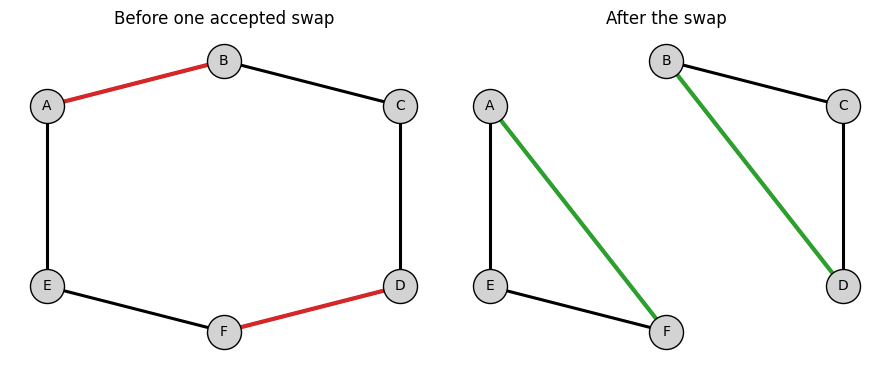

Degrees before: {'A': 2, 'B': 2, 'E': 2, 'C': 2, 'D': 2, 'F': 2}
Degrees after : {'A': 2, 'B': 2, 'E': 2, 'C': 2, 'D': 2, 'F': 2}


In [4]:
swap_demo = nx.Graph()
swap_demo.add_edges_from(
    [
        ("A", "B"),
        ("A", "E"),
        ("B", "C"),
        ("C", "D"),
        ("D", "F"),
        ("E", "F"),
    ]
)

swap_before = swap_demo.copy()
swap_after = swap_demo.copy()
swap_after.remove_edge("A", "B")
swap_after.remove_edge("D", "F")
swap_after.add_edge("A", "F")
swap_after.add_edge("D", "B")

deg_before = dict(swap_before.degree())
deg_after = dict(swap_after.degree())
assert deg_before == deg_after

pos_swap = {
    "A": (-1.0, 0.8),
    "B": (0.0, 1.2),
    "C": (1.0, 0.8),
    "D": (1.0, -0.8),
    "E": (-1.0, -0.8),
    "F": (0.0, -1.2),
}

fig, axes = plt.subplots(1, 2, figsize=(9, 3.8), dpi=100)

nx.draw_networkx_nodes(swap_before, pos_swap, ax=axes[0], node_size=600, node_color="lightgray", edgecolors="black")
nx.draw_networkx_labels(swap_before, pos_swap, ax=axes[0], font_size=10)
nx.draw_networkx_edges(swap_before, pos_swap, ax=axes[0], width=2.2)
nx.draw_networkx_edges(
    swap_before,
    pos_swap,
    ax=axes[0],
    edgelist=[("A", "B"), ("D", "F")],
    width=3.0,
    edge_color="tab:red",
)
axes[0].set_title("Before one accepted swap")
axes[0].set_axis_off()

nx.draw_networkx_nodes(swap_after, pos_swap, ax=axes[1], node_size=600, node_color="lightgray", edgecolors="black")
nx.draw_networkx_labels(swap_after, pos_swap, ax=axes[1], font_size=10)
nx.draw_networkx_edges(swap_after, pos_swap, ax=axes[1], width=2.2)
nx.draw_networkx_edges(
    swap_after,
    pos_swap,
    ax=axes[1],
    edgelist=[("A", "F"), ("D", "B")],
    width=3.0,
    edge_color="tab:green",
)
axes[1].set_title("After the swap")
axes[1].set_axis_off()

plt.tight_layout()
plt.show()

print("Degrees before:", deg_before)
print("Degrees after :", deg_after)

Every degree stayed the same, but the local wiring changed. That is the whole idea of a configuration-model null: hold node-level opportunity fixed and ask what structure emerges from the reconnection.


,graph,n,m,triangles,average_clustering
0,clustered original,40,120,120,0.599286
1,degree-preserving randomized,40,120,25,0.125357


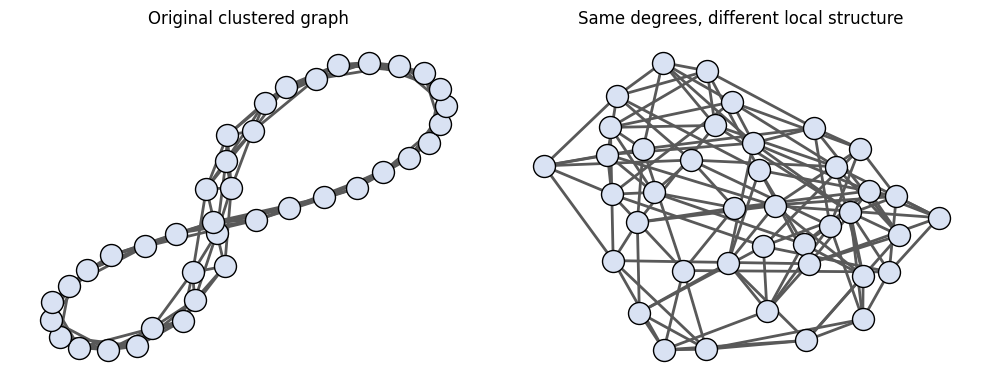

In [5]:
# A clustered graph and a degree-preserving randomization of it.
G_ws = nx.watts_strogatz_graph(n=40, k=6, p=0.05, seed=SEED)
G_ws = nx.Graph(G_ws)

G_ws_rand = double_edge_swap_simple(
    G_ws,
    nswap=2500,
    max_tries=50000,
    rng_local=random.Random(SEED),
)

stats_df = pd.DataFrame(
    {
        "graph": ["clustered original", "degree-preserving randomized"],
        "n": [G_ws.number_of_nodes(), G_ws_rand.number_of_nodes()],
        "m": [G_ws.number_of_edges(), G_ws_rand.number_of_edges()],
        "triangles": [triangle_count_nx(G_ws), triangle_count_nx(G_ws_rand)],
        "average_clustering": [nx.average_clustering(G_ws), nx.average_clustering(G_ws_rand)],
    }
)
display(stats_df)

deg_original = sorted(d for _, d in G_ws.degree())
deg_randomized = sorted(d for _, d in G_ws_rand.degree())
assert deg_original == deg_randomized

fig, axes = plt.subplots(1, 2, figsize=(10, 4), dpi=100)
draw_graph(G_ws, ax=axes[0], title="Original clustered graph", pos=nx.spring_layout(G_ws, seed=SEED))
draw_graph(G_ws_rand, ax=axes[1], title="Same degrees, different local structure", pos=nx.spring_layout(G_ws_rand, seed=SEED))
plt.tight_layout()
plt.show()

The point is not that the randomized graph is "wrong." The point is that **degree sequence alone is not the network**. Once you see that, motif analysis becomes a natural next step: local subgraphs are one way to describe *how* a graph with a given degree sequence is organized.

This also previews a major theme of the notebook. Any claim of the form "this pattern is special" is really shorthand for:

> this pattern is special **relative to a chosen baseline**.

In motif work, the baseline is a random-graph null model. In signed-network work later on, the same issue reappears with sign-shuffling nulls and degree-preserving signed nulls.


## 2. Motif language: induced subgraphs, graphlets, and motifs

A **subgraph** is any smaller graph formed from some subset of nodes and edges. For motif work, the most important version is the **induced subgraph**.

If $S \subseteq V$, then $G[S]$ contains:

- every node in $S$, and
- every edge of $G$ whose endpoints both lie in $S$.

That "include all internal edges" rule is important. It means that a fixed node set contributes exactly one induced pattern.

Two terms appear constantly in this area:

- A **graphlet** is a small induced subgraph used descriptively. A graphlet count tells us what local patterns are present.
- A **motif** is a graphlet that is statistically over-represented or under-represented relative to a null model. A motif claim is not just "this pattern occurs a lot." It is "this pattern occurs more than expected under a baseline."

NOTE: This distinction often shows up in the literature, but I don't think it's that useful.

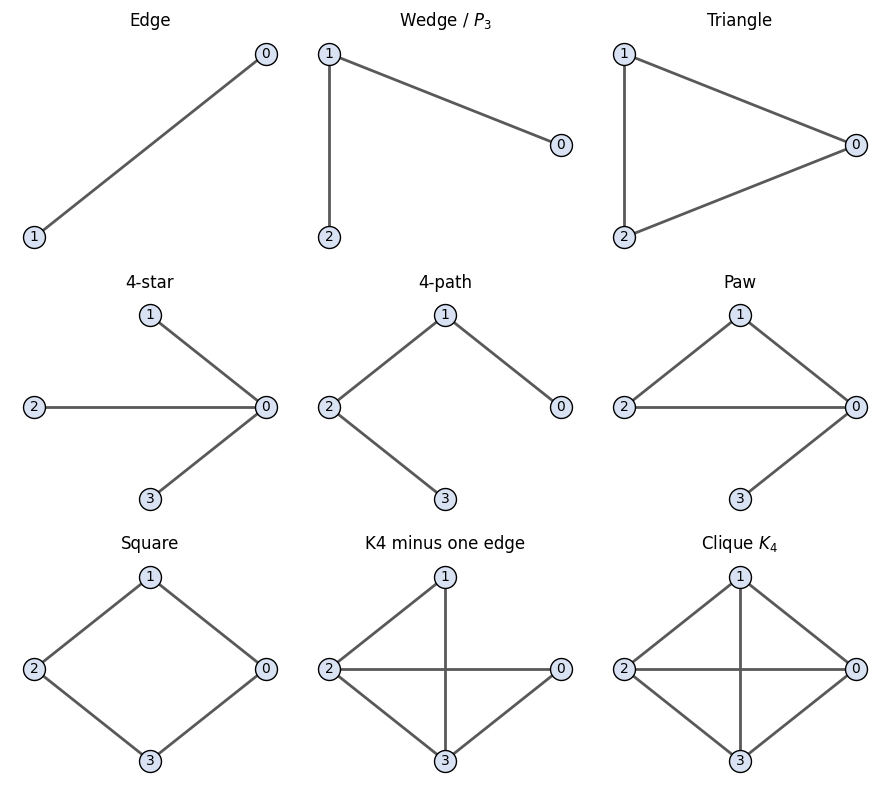

In [6]:
# A gallery of connected undirected graphlets on 2, 3, and 4 nodes.
H_edge = nx.Graph([(0, 1)])
H_wedge = nx.path_graph(3)
H_triangle = nx.complete_graph(3)

H_star4 = nx.star_graph(3)
H_path4 = nx.path_graph(4)

H_paw = nx.Graph()
H_paw.add_edges_from([(0, 1), (1, 2), (2, 0), (0, 3)])

H_square = nx.cycle_graph(4)
H_kite = nx.complete_graph(4)
H_kite.remove_edge(0, 1)
H_clique4 = nx.complete_graph(4)

motif_gallery = [
    ("Edge", H_edge),
    ("Wedge / $P_3$", H_wedge),
    ("Triangle", H_triangle),
    ("4-star", H_star4),
    ("4-path", H_path4),
    ("Paw", H_paw),
    ("Square", H_square),
    ("K4 minus one edge", H_kite),
    ("Clique $K_4$", H_clique4),
]

fig, axes = plt.subplots(3, 3, figsize=(9, 8), dpi=100)
for ax, (name, H) in zip(axes.ravel(), motif_gallery):
    draw_graph(H, ax=ax, title=name)
for ax in axes.ravel()[len(motif_gallery):]:
    ax.set_axis_off()
plt.tight_layout()
plt.show()


First, **induced** and **non-induced** counting are different. If a triangle is present, then it also contains three wedges as ordinary subgraphs. So non-induced counts can be much larger than induced counts.

Second, **undirected** and **directed** motifs are different objects. An undirected triangle is just one pattern. Directed triads already split into many types because orientation matters.

Third, **connected** and **disconnected** graphlets answer different questions. In this notebook, when we say graphlet or motif without further qualification, we mean a **connected induced subgraph**.

Fourth, **node-labeled** and **unlabeled** counting are different. In most of the chapter we classify unlabeled patterns, so isomorphic copies are treated as the same type even when they occur on different host-graph nodes.

### One fixed node set, two different counting conventions

Let's make the bookkeeping completely explicit on the simplest host graph possible: a single triangle on nodes $\{0,1,2\}$.

- As an **induced** 3-node subgraph, that node set contributes exactly **one triangle**.
- As a **non-induced** pattern source, the same three nodes also contain **three wedges**, because we can choose any two of the three edges and ignore the third.

So when two sources report different wedge counts, they can both be correct while answering different questions. The node set stayed the same. The counting rule changed.

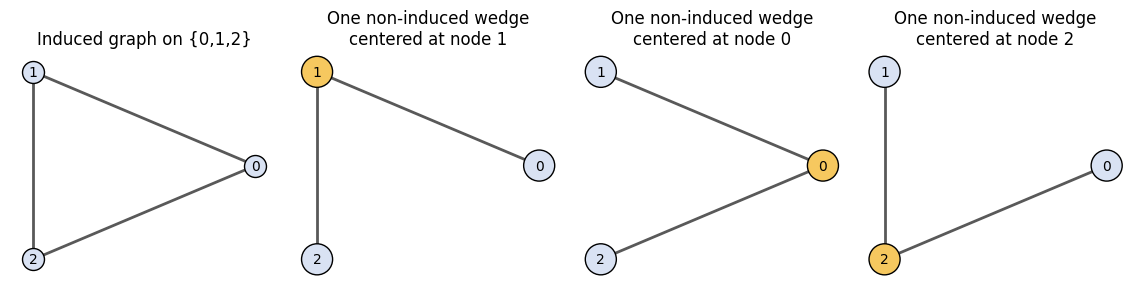

In [7]:
triangle_host = nx.complete_graph(3)
triangle_nodes = [0, 1, 2]
triangle_edge_sets = [
    [(0, 1), (1, 2)],
    [(0, 1), (0, 2)],
    [(0, 2), (1, 2)],
]
triangle_pos = nx.circular_layout(triangle_host)

fig, axes = plt.subplots(1, 4, figsize=(11.5, 3.0), dpi=100)

draw_graph(
    triangle_host,
    ax=axes[0],
    title="Induced graph on {0,1,2}",
    pos=triangle_pos,
)

for ax, edges, center in zip(axes[1:], triangle_edge_sets, [1, 0, 2]):
    H = nx.Graph()
    H.add_nodes_from(triangle_nodes)
    H.add_edges_from(edges)

    nx.draw_networkx_nodes(
        H,
        triangle_pos,
        ax=ax,
        node_size=500,
        node_color=[NODE_FILL_COLOR if u != center else "#f6c85f" for u in triangle_nodes],
        edgecolors="black",
        linewidths=1.0,
    )
    nx.draw_networkx_edges(H, triangle_pos, ax=ax, width=2, edge_color=EDGE_DRAW_COLOR)
    nx.draw_networkx_labels(H, triangle_pos, ax=ax, font_size=10)
    ax.set_axis_off()
    ax.set_title(f"One non-induced wedge\ncentered at node {center}")

plt.tight_layout()
plt.show()

The picture is an **induced** census, the left panel is the answer for that node set. In a **non-induced** census, the three wedge panels are also counted. This is why papers and software that report motif counts need to say induced or non-induced before the numbers become interpretable.

### Symmetry, automorphisms, and graphlet orbits

There is one more layer of precision that becomes important as soon as we move beyond whole-pattern counts: **symmetry**.

An **automorphism** of a graphlet is a relabeling of its nodes that leaves the graphlet unchanged. Automorphisms tell us which nodes inside a pattern really play the same structural role. The equivalence classes induced by those symmetries are called **orbits**.

Why do we care?

- For whole-pattern counts, automorphisms explain overcounting factors. The $1/6$ in the triangle formula is really a symmetry correction.
- For node-level graphlet features, orbits matter even more. In a 4-path, the two end nodes are structurally equivalent to each other, and the two middle nodes are structurally equivalent to each other, but an end node and a middle node are not the same role.
- Graphlet-degree vectors and orbit counts generalize ordinary degree and triangle participation by asking not just "how many graphlets touch this node?" but "how many times does this node appear in each orbit?"

This is why graphlet language often goes beyond just pattern frequency. It also gives us a vocabulary for **local roles** inside patterns, a perspective developed especially clearly in the graphlet literature around Pržulj (2007), Milenković and Pržulj (2008), and later orbit-counting work such as Hočevar and Demšar (2014).

For tiny graphlets we can compute the automorphisms exactly by brute force.


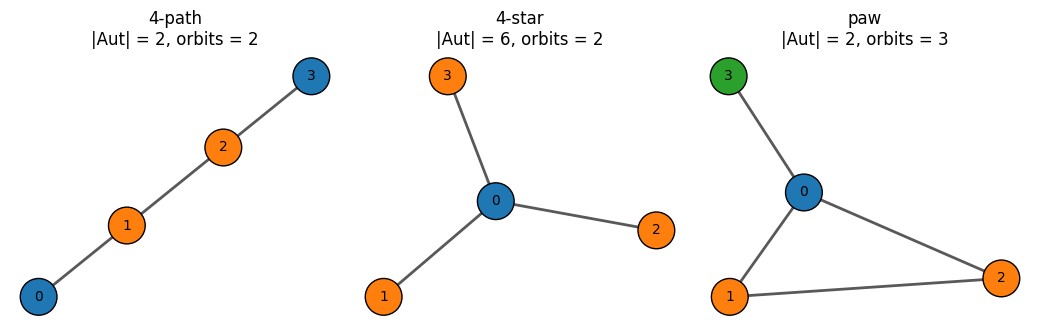

,graphlet,orbit_id,nodes_in_orbit,orbit_size
0,4-path,0,"(0, 3)",2
1,4-path,1,"(1, 2)",2
2,4-star,0,"(0,)",1
3,4-star,1,"(1, 2, 3)",3
4,paw,0,"(0,)",1
5,paw,1,"(1, 2)",2
6,paw,2,"(3,)",1


In [8]:
def automorphism_permutations(H):
    """Return automorphisms of a tiny undirected graph as index permutations."""
    nodes = list(H.nodes())
    A = nx.to_numpy_array(H, nodelist=nodes, dtype=int)
    autos = []
    k = len(nodes)

    for perm in itertools.permutations(range(k)):
        ok = True
        for i in range(k):
            for j in range(k):
                if A[i, j] != A[perm[i], perm[j]]:
                    ok = False
                    break
            if not ok:
                break
        if ok:
            autos.append(perm)

    return nodes, autos


def orbit_partition(H):
    """Partition the nodes of a tiny graph into automorphism orbits."""
    nodes, autos = automorphism_permutations(H)
    unseen = set(range(len(nodes)))
    orbits = []

    while unseen:
        i = min(unseen)
        orb = {perm[i] for perm in autos}
        orbits.append(tuple(nodes[j] for j in sorted(orb)))
        unseen -= orb

    return nodes, autos, orbits


orbit_examples = [
    ("4-path", H_path4),
    ("4-star", H_star4),
    ("paw", H_paw),
]

orbit_rows = []
palette_orbits = ["tab:blue", "tab:orange", "tab:green", "tab:red"]

fig, axes = plt.subplots(1, 3, figsize=(10.5, 3.4), dpi=100)

for ax, (name, H) in zip(axes, orbit_examples):
    nodes, autos, orbits = orbit_partition(H)

    orbit_id = {}
    for oid, orbit in enumerate(orbits):
        for u in orbit:
            orbit_id[u] = oid

    pos = nx.spring_layout(H, seed=SEED)

    nx.draw_networkx_nodes(
        H,
        pos,
        ax=ax,
        node_size=700,
        node_color=[palette_orbits[orbit_id[u]] for u in H.nodes()],
        edgecolors="black",
        linewidths=1.0,
    )
    nx.draw_networkx_edges(H, pos, ax=ax, width=2, edge_color=EDGE_DRAW_COLOR)
    nx.draw_networkx_labels(H, pos, ax=ax, font_size=10)
    ax.set_title(f"{name}\n|Aut| = {len(autos)}, orbits = {len(orbits)}")
    ax.set_axis_off()

    for oid, orbit in enumerate(orbits):
        orbit_rows.append(
            {
                "graphlet": name,
                "orbit_id": oid,
                "nodes_in_orbit": orbit,
                "orbit_size": len(orbit),
            }
        )

plt.tight_layout()
plt.show()

display(pd.DataFrame(orbit_rows))


The examples capture the basic idea.

- In a 4-path, the two endpoints form one orbit and the two interior nodes form another.
- In a 4-star, the center is alone in one orbit and the leaves share a second orbit.
- In the paw, the leaf is unique, the triangle node incident to the leaf is unique, and the other two triangle nodes share an orbit.

That is the language behind **graphlet roles**. Ordinary degree is already an orbit count: it counts how many times a node appears in the unique orbit of the 2-node edge graphlet. Triangle participation is the same idea for the unique orbit of the 3-node triangle. Graphlet-degree vectors extend this logic across many graphlets and many orbits, which is why orbit structure matters in practice and not just in definitions.


A compact symmetry table is often more memorable than another abstract definition. For several common graphlets, the next cell computes the size of the automorphism group and the orbit sizes directly.

A useful rule of thumb is

$$
\text{unlabeled copies of } H
=
\frac{\text{labeled embeddings of } H}{|\mathrm{Aut}(H)|}
$$

when the labeled count treats symmetry-related relabelings as distinct. The denominator is exactly the symmetry correction.

In [9]:
graphlet_symmetry_examples = [
    ("Edge", H_edge),
    ("Wedge", H_wedge),
    ("Triangle", H_triangle),
    ("4-path", H_path4),
    ("4-star", H_star4),
    ("Paw", H_paw),
    ("Square", H_square),
    ("K4 minus one edge", H_kite),
    ("Clique K4", H_clique4),
]

symmetry_rows = []
for name, H in graphlet_symmetry_examples:
    nodes_here, autos_here = automorphism_permutations(H)
    _, _, orbits_here = orbit_partition(H)
    symmetry_rows.append(
        {
            "graphlet": name,
            "nodes": H.number_of_nodes(),
            "edges": H.number_of_edges(),
            "|Aut(H)|": len(autos_here),
            "number of orbits": len(orbits_here),
            "orbit sizes": tuple(len(orbit) for orbit in orbits_here),
        }
    )

df_symmetry = pd.DataFrame(symmetry_rows)
display(df_symmetry)

,graphlet,nodes,edges,|Aut(H)|,number of orbits,orbit sizes
0,Edge,2,1,2,1,"(2,)"
1,Wedge,3,2,2,2,"(2, 1)"
2,Triangle,3,3,6,1,"(3,)"
3,4-path,4,3,2,2,"(2, 2)"
4,4-star,4,3,6,2,"(1, 3)"
5,Paw,4,4,2,3,"(1, 2, 1)"
6,Square,4,4,8,1,"(4,)"
7,K4 minus one edge,4,5,4,2,"(2, 2)"
8,Clique K4,4,6,24,1,"(4,)"


Now the triangle correction factor is no longer mysterious. A triangle has $|\mathrm{Aut}(H)|=6$, so six labelings collapse to one unlabeled copy. A wedge has only two automorphisms, because its leaves can swap but its center cannot. Orbit structure is the node-level version of the same idea: it tells us which positions inside a graphlet are genuinely different.

## 3. Counting motifs on a toy graph

Before writing general code, it is worth doing one small graph by hand. This is where most counting mistakes first show up.

We will use a six-node toy graph and classify every three-node subset as either:

- disconnected,
- a wedge, or
- a triangle.

That sounds simple, but it forces us to be precise about what exactly is being counted.


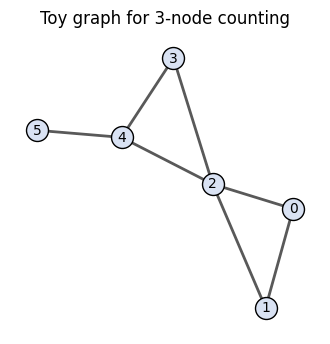

In [10]:
# A small graph with both wedges and triangles.
G_toy = nx.Graph()
G_toy.add_edges_from(
    [
        (0, 1), (1, 2), (2, 0),   # triangle on {0,1,2}
        (2, 3), (3, 4),           # a path extension
        (2, 4),                   # triangle on {2,3,4}
        (4, 5),                   # tail
    ]
)

fig, ax = plt.subplots(figsize=(4, 4), dpi=100)
draw_graph(G_toy, ax=ax, title="Toy graph for 3-node counting", pos=nx.spring_layout(G_toy, seed=SEED))
plt.show()


Let $T$ denote the number of triangles and let $W$ denote the number of **induced** wedges.

One easy way to count wedges is to start from node degrees. Every node $i$ with degree $k_i$ contributes

$$
\binom{k_i}{2}
$$

two-step paths centered at $i$. Here:

- $k_i$ is the degree of node $i$,
- $\binom{k_i}{2}$ is the number of unordered neighbor pairs of $i$.

If none of those neighbor pairs were connected to each other, then summing $\binom{k_i}{2}$ over all nodes would count every wedge exactly once.


But triangles interfere with that count. Each triangle contributes three connected triples, one centered at each of its vertices. So for a simple undirected graph,

$$
W = \sum_i \binom{k_i}{2} - 3T.
$$

This formula makes sense because it starts from **all connected triples centered at a node** and then removes the triples that close into triangles.


For example, node 2 in the toy graph has degree 4, so it contributes $\binom{4}{2}=6$ centered triples. Two of those triples close into triangles, namely $\{0,1,2\}$ and $\{2,3,4\}$. So only 4 of those 6 centered triples remain induced wedges. The formula handles this globally by subtracting $3T$, because each triangle contributes one centered triple at each of its three vertices.


## \#OurTurn... As a class: 


Let's use our eyes to figure out how many motfis of size 3 there are.

![](images/test_counting.png)

_________

## \#OurTurn... As a class: 

Now... let's think about how to algorithmically count these.

In [11]:
G_toy

________________

In [12]:
def classify_triple_undirected(G, triple):
    """Classify a 3-node subset as disconnected, wedge, or triangle."""
    H = G.subgraph(triple)
    m = H.number_of_edges()
    if m == 3:
        return "triangle"
    if m == 2 and nx.is_connected(H):
        return "wedge"
    return "other"

In [13]:
triple_rows = []
for triple in combinations(G_toy.nodes(), 3):
    label = classify_triple_undirected(G_toy, triple)
    triple_rows.append({"triple": triple, "class": label})
    
df_triples = pd.DataFrame(triple_rows)
display(df_triples)


,triple,class
0,"(0, 1, 2)",triangle
1,"(0, 1, 3)",other
2,"(0, 1, 4)",other
3,"(0, 1, 5)",other
4,"(0, 2, 3)",wedge
5,"(0, 2, 4)",wedge
6,"(0, 2, 5)",other
7,"(0, 3, 4)",other
8,"(0, 3, 5)",other
9,"(0, 4, 5)",other


In [14]:
triangle_count = (df_triples["class"] == "triangle").sum()
wedge_count = (df_triples["class"] == "wedge").sum()

degrees = dict(G_toy.degree())
wedge_formula = sum(math.comb(k, 2) for k in degrees.values()) - 3 * triangle_count

print("Triangle count by explicit enumeration:", triangle_count)
print("Wedge count by explicit enumeration   :", wedge_count)
print("Wedge count from degree formula       :", wedge_formula)

Triangle count by explicit enumeration: 2
Wedge count by explicit enumeration   : 6
Wedge count from degree formula       : 6


The code cell above is doing two things at once.

First, it is a literal numerical example of the formula. In the notation above:

- the symbol $k_i$ is represented by the Python dictionary `degrees`,
- the quantity $T$ is represented by the variable `triangle_count`,
- the formula output is stored in `wedge_formula`.

Second, it is a reminder that even tiny counting formulas encode a specific convention. Here, $W$ counts **induced** wedges, not all length-2 walks.


____________

## 4. Motif counting with adjacency algebra and `einsum`

For a handful of important patterns, we do not need to enumerate node subsets explicitly. Matrix algebra can do the counting for us.

This is useful for two reasons.

First, it is often faster.

Second, it tells us what a count *means*. For example, triangle counts are really counts of closed walks of length three, corrected for overcounting.

And third, it gives us a clean bridge to code. Once you can read a motif formula as a contraction of adjacency entries, `trace` identities and `einsum` calls stop feeling like separate worlds.


For a simple undirected graph with adjacency matrix $A$, the number of triangles is

$$
T = \frac{1}{6}\,\mathrm{tr}(A^3).
$$

Every symbol matters here:

- $A$ is the $n \times n$ adjacency matrix of the graph,
- $A^3$ counts length-3 walks,
- $\mathrm{tr}(A^3)$ is the sum of the diagonal entries, so it counts length-3 closed walks,
- the factor $1/6$ appears because each undirected triangle is counted from 3 starting vertices and 2 directions.

We will verify that identity numerically in the next cell.


To see why the factor is $6$, consider a single triangle on nodes $\{0,1,2\}$. Its adjacency matrix has ones everywhere off the diagonal. Then $A^3$ has diagonal entries equal to $2$: from each starting node there are exactly two closed walks of length 3, one clockwise and one counterclockwise. So $\mathrm{tr}(A^3)=6$, and dividing by $6$ returns exactly one triangle.


In [15]:
def adjacency_numpy(G, nodelist=None):
    """Return the adjacency matrix of an undirected graph as an integer NumPy array."""
    if nodelist is None:
        nodelist = list(G.nodes())
    A = nx.to_numpy_array(G, nodelist=nodelist, dtype=int)
    return A, nodelist


def triangle_count_trace(A):
    """Count undirected triangles as tr(A^3) / 6."""
    return int(np.trace(A @ A @ A) // 6)

In [16]:
A_toy, toy_nodes = adjacency_numpy(G_toy)
A_toy_sparse = nx.adjacency_matrix(G_toy, nodelist=toy_nodes).toarray().astype(int)
triangle_trace = triangle_count_trace(A_toy)

In [17]:
print("Triangle count from explicit enumeration:", triangle_count)
print("Triangle count from trace formula       :", triangle_trace)

Triangle count from explicit enumeration: 2
Triangle count from trace formula       : 2


Directed graphs give different formulas because orientation matters.

For a simple directed graph with adjacency matrix $A$:

$$
C_3^{\to} = \frac{1}{3}\,\mathrm{tr}(A^3)
$$

counts directed 3-cycles, because a directed cycle has 3 starting points but only one orientation consistent with the arrows.

A second classic pattern is the **feed-forward loop** with edges $i \to j$, $j \to k$, and $i \to k$. If we count only the presence of those three edges and ignore whether extra edges are present, then the count is

$$
\mathrm{FFL}_{\mathrm{noninduced}} = \sum_{i,j,k} A_{ij}A_{ik}A_{jk}.
$$

That is exactly what `np.einsum("ij,ik,jk->", A, A, A)` computes.

Notice what has happened pedagogically: we moved from a local picture of three nodes to algebraic expressions that still remember the same pattern.


In [18]:
def directed_3cycles_trace(A):
    """Count directed 3-cycles as tr(A^3) / 3."""
    return int(np.trace(A @ A @ A) // 3)


def ffl_count_einsum(A):
    """Non-induced feed-forward loop count."""
    return int(np.einsum("ij,ik,jk->", A, A, A))


# Small directed example with planted feed-forward loops.
D_demo = nx.gnp_random_graph(18, 0.10, seed=SEED, directed=True)
D_demo.remove_edges_from(nx.selfloop_edges(D_demo))

planted_ffls = [(0, 1, 2), (3, 4, 5), (6, 7, 8)]
for i, j, k in planted_ffls:
    D_demo.add_edge(i, j)
    D_demo.add_edge(j, k)
    D_demo.add_edge(i, k)

A_demo = nx.to_numpy_array(D_demo, dtype=int)

cycles3 = directed_3cycles_trace(A_demo)
ffl_noninduced = ffl_count_einsum(A_demo)
triad_census_demo = nx.triadic_census(D_demo)
ffl_induced = triad_census_demo["030T"]  # transitive triad

print("Directed 3-cycles from trace formula:", cycles3)
print("Non-induced FFL count via einsum    :", ffl_noninduced)
print("Induced FFL count via triad census  :", ffl_induced)

Directed 3-cycles from trace formula: 0
Non-induced FFL count via einsum    : 6
Induced FFL count via triad census  : 6


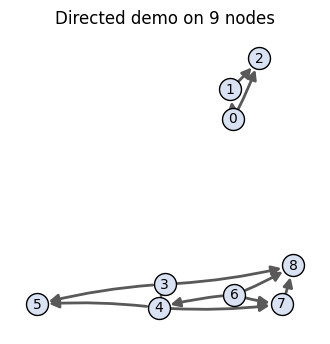

In [19]:
fig, ax = plt.subplots(figsize=(4, 4), dpi=100)
draw_digraph(D_demo.subgraph(range(9)), ax=ax, title="Directed demo on 9 nodes")
plt.show()


The induced/non-induced distinction is one of the most common sources of confusion in motif work.

The `einsum` count above treats a triple as an FFL whenever the three target edges exist. If the same triple also contains extra reciprocal edges, it still contributes.

The triadic census does something different. It classifies each 3-node set by its **entire** edge pattern. That is why the induced FFL count is the triad type `030T`.

So in general,

$$
\text{non-induced FFL count} \ge \text{induced 030T count}.
$$

That inequality is not a bug. It is the result of answering two different questions.


## Your turn!

Suppose you add one extra edge to every planted feed-forward loop in the directed demo above. For example, imagine adding the reverse edge on one side.

Which count do you expect to change more dramatically?

- the non-induced `einsum` count
- the induced `030T` triad count

Try to answer before re-running the cell with modifications.


## 5. Why counting gets hard: combinatorics, isomorphism, and symmetry

Even before null models enter the picture, motif counting is computationally nontrivial.

There are at least three separate reasons.

**Combinatorics.** On $k$ labeled nodes there are many possible edge sets. For undirected graphs the count is $2^{\binom{k}{2}}$ because each of the $\binom{k}{2}$ possible edges is present or absent.

**Isomorphism.** Motif types are usually **unlabeled** patterns. That means we have to identify when two different labeled edge sets are actually the same pattern after relabeling the nodes.

**Symmetry.** Even after we know the pattern type, some node positions inside that pattern may be interchangeable while others are not. Those symmetries control both overcounting factors and node-level graphlet roles.

The next cell uses NetworkX's graph atlas to show how quickly the number of connected undirected graphlet types grows.


In [20]:
def atlas_graphs(n, connected=None):
    """Return graph-atlas representatives on n nodes.

    Parameters
    ----------
    n : int
        Number of nodes.
    connected : {None, True, False}
        If True, return only connected representatives.
        If False, return only disconnected representatives.
        If None, return all representatives.
    """
    out = []
    for G in nx.graph_atlas_g():
        if G.number_of_nodes() != n:
            continue
        if connected is True and n > 0 and not nx.is_connected(G):
            continue
        if connected is False and n > 0 and nx.is_connected(G):
            continue
        out.append(nx.convert_node_labels_to_integers(G))
    return out

In [21]:
rows = []
for k in range(1, 8):
    all_graphs = atlas_graphs(k, connected=None)
    connected_graphs = atlas_graphs(k, connected=True)
    rows.append(
        {
            "k": k,
            "labeled_undirected_graphs": 2 ** (k * (k - 1) // 2),
            "unlabeled_undirected_graphs": len(all_graphs),
            "connected_graphlet_types": len(connected_graphs),
        }
    )

df_counts = pd.DataFrame(rows)
display(df_counts)


,k,labeled_undirected_graphs,unlabeled_undirected_graphs,connected_graphlet_types
0,1,1,1,1
1,2,2,2,1
2,3,8,4,2
3,4,64,11,6
4,5,1024,34,21
5,6,32768,156,112
6,7,2097152,1044,853


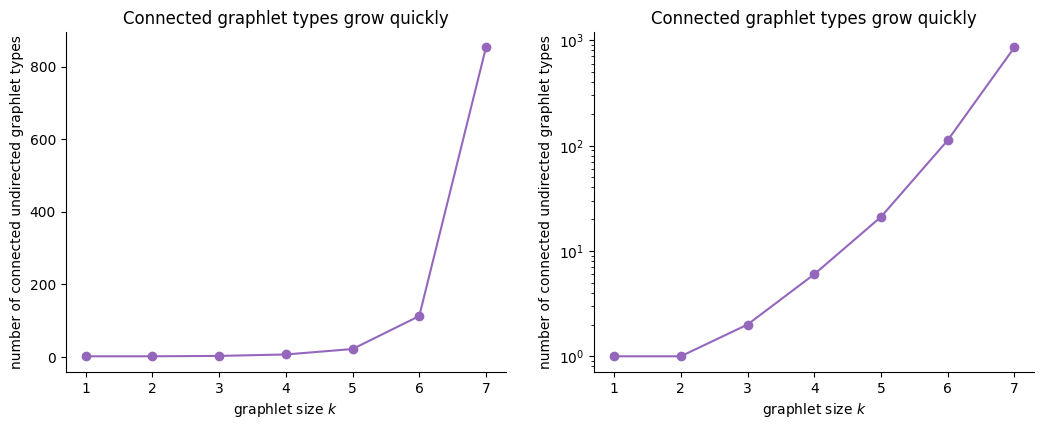

In [22]:
fig, ax = plt.subplots(1,2,figsize=(12.5, 4.5), dpi=100)
ax[0].plot(df_counts["k"], df_counts["connected_graphlet_types"], marker="o", color="tab:purple")
ax[0].set_xlabel("graphlet size $k$")
ax[0].set_ylabel("number of connected undirected graphlet types")
ax[0].set_title("Connected graphlet types grow quickly")

ax[1].semilogy(df_counts["k"], df_counts["connected_graphlet_types"], marker="o", color="tab:purple")
ax[1].set_xlabel("graphlet size $k$")
ax[1].set_ylabel("number of connected undirected graphlet types")
ax[1].set_title("Connected graphlet types grow quickly")
plt.show()

For teaching-sized examples, brute force is still very useful. We can enumerate every $k$-node subset, take the induced subgraph, and then collapse isomorphic copies into a canonical representation.

The next cell implements a tiny exact canonical labeling routine for very small undirected graphs. It is intentionally not optimized. The point is clarity.


In [23]:
def canonical_adj_string(H):
    """Canonical adjacency signature for a very small undirected graph.

    The graph is relabeled in all possible ways, and the lexicographically
    smallest adjacency bitstring is returned. This is exact but scales like k!.
    """
    nodes = list(H.nodes())
    k = len(nodes)
    if k == 0:
        return ""

    idx = {u: i for i, u in enumerate(nodes)}
    A = [[0] * k for _ in range(k)]
    for u, v in H.edges():
        i = idx[u]
        j = idx[v]
        A[i][j] = 1
        A[j][i] = 1

    best = None
    for perm in itertools.permutations(range(k)):
        code = 0
        for ii in perm:
            for jj in perm:
                if ii == jj:
                    continue
                code = (code << 1) | A[ii][jj]
        if best is None or code < best:
            best = code

    return format(best, f"0{k * (k - 1)}b")


def induced_connected_subgraphs_bruteforce(G, k):
    """Yield connected induced k-node subgraphs by brute force."""
    for subset in combinations(G.nodes(), k):
        H = G.subgraph(subset).copy()
        if nx.is_connected(H):
            yield H


def motif_census_bruteforce(G, k):
    """Exact graphlet census on connected induced k-node subgraphs."""
    counts = Counter()
    reps = {}
    for H in induced_connected_subgraphs_bruteforce(G, k):
        sig = canonical_adj_string(H)
        counts[sig] += 1
        if sig not in reps:
            reps[sig] = H
    return counts, reps

In [24]:
# Map the six connected 4-node graphlets to readable names.
graphlet4_library = {
    "4-star": H_star4,
    "4-path": H_path4,
    "paw": H_paw,
    "square": H_square,
    "kite": H_kite,
    "clique4": H_clique4,
}
sig_to_name4 = {canonical_adj_string(H): name for name, H in graphlet4_library.items()}

G_karate = nx.karate_club_graph()
counts4, reps4 = motif_census_bruteforce(G_karate, k=4)

plot_df = (
    pd.DataFrame(
        {
            "graphlet": [sig_to_name4.get(sig, sig) for sig in counts4.keys()],
            "count": list(counts4.values()),
        }
    )
    .sort_values("count", ascending=False)
    .reset_index(drop=True)
)
display(plot_df)

,graphlet,count
0,4-star,1098
1,4-path,681
2,paw,452
3,kite,85
4,square,36
5,clique4,11


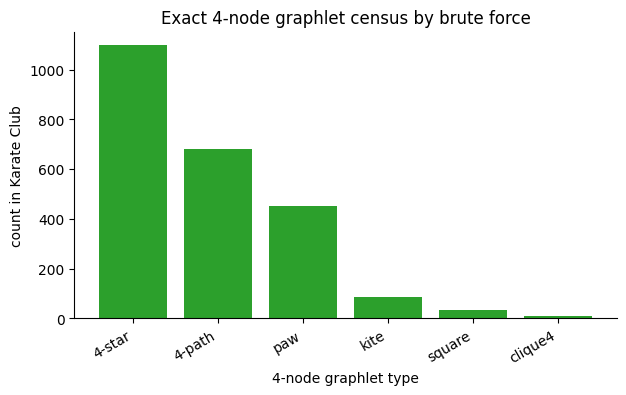

In [25]:
fig, ax = plt.subplots(figsize=(7, 3.8), dpi=100)

ax.bar(plot_df["graphlet"], plot_df["count"], color="tab:green")
ax.set_xlabel("4-node graphlet type")
ax.set_ylabel("count in Karate Club")
ax.set_title("Exact 4-node graphlet census by brute force")
plt.xticks(rotation=30, ha="right")
plt.show()

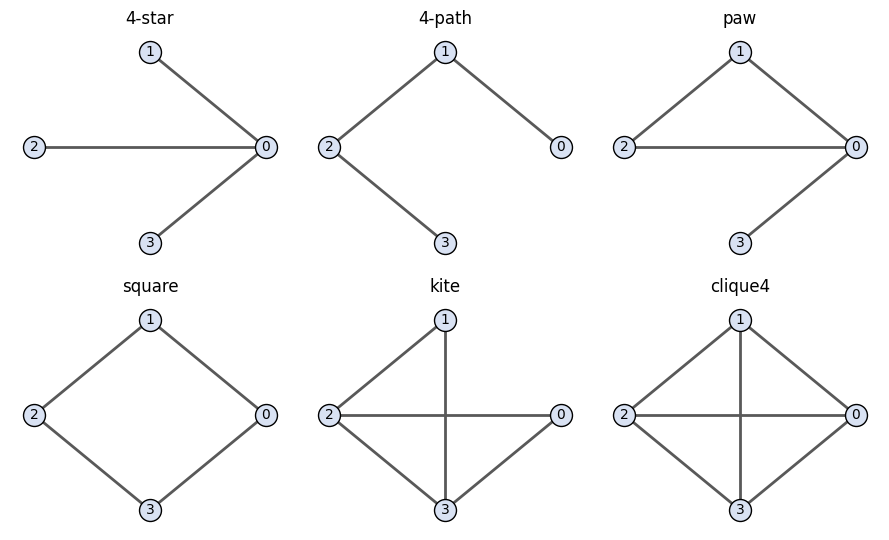

In [26]:

fig, axes = plt.subplots(2, 3, figsize=(9, 5.5), dpi=100)
for ax, (name, H) in zip(axes.ravel(), graphlet4_library.items()):
    draw_graph(H, ax=ax, title=name)
plt.tight_layout()
plt.show()

The point of the Karate Club example is not that 4-node graphlets are magically interpretable in every domain. The point is that a **graphlet distribution** is already a rich description of local structure before we ever talk about significance.

Once we add a null model, some of these graphlets may become motif candidates. Without a null model, they are simply descriptive local summaries.


## 6. Motif discovery is a statistical claim

Up to this point we have been doing **motif census**: counting local patterns.

Motif **discovery** adds a baseline. If $N_M(G)$ is the observed count of pattern $M$ in graph $G$, then a standard summary is the z-score

$$
z_M = \frac{N_M(G) - \mu_M}{\sigma_M}.
$$

Here:

- $N_M(G)$ is the observed motif count,
- $\mu_M$ is the mean motif count under the chosen null model,
- $\sigma_M$ is the standard deviation under that same null.

The formula makes sense because it answers a familiar question: *how many null-model standard deviations away from the null mean is the observation?*

A second practical quantity is the empirical one-sided p-value

$$
p_M = \frac{1 + \#\{r : N_M(G_r) \ge N_M(G)\}}{R + 1},
$$

where $G_1,\dots,G_R$ are null-model samples. This estimates how often the null produces a count at least as large as the observed one.

The crucial phrase in both formulas is **under the chosen null model**. Change the null, and you are asking a different scientific question.


In [27]:
def z_from_samples(samples, obs):
    """Return null mean, null standard deviation, and z-score."""
    samples = np.asarray(samples, dtype=float)
    mu = samples.mean()
    sd = samples.std(ddof=1)
    z = (obs - mu) / sd if sd > 0 else np.nan
    return mu, sd, z


def empirical_upper_tail_p(samples, obs):
    """Empirical one-sided p-value for enrichment."""
    samples = np.asarray(samples, dtype=float)
    return (1 + np.sum(samples >= obs)) / (len(samples) + 1)

,null_model,observed_triangles,null_mean,null_sd,z_score,empirical_p_upper
0,Erdos-Renyi matched on density,120,35.586667,12.307681,6.858590,0.006623
1,degree-preserving edge swaps,120,22.033333,3.769209,25.991308,0.006623


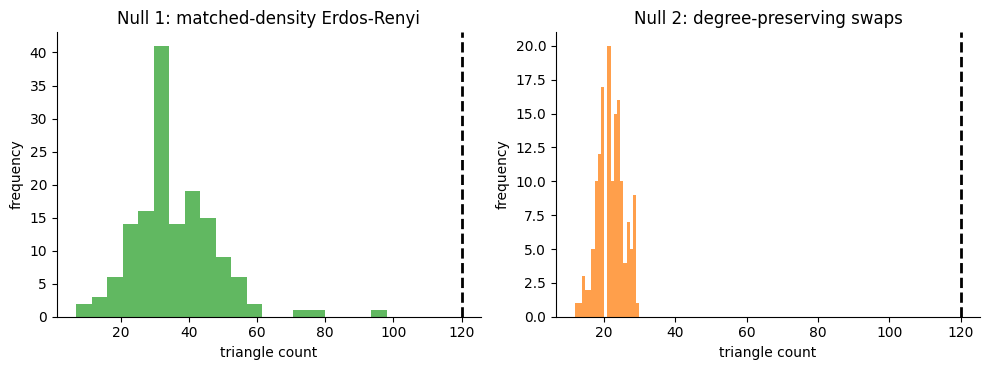

In [28]:
# Compare triangle significance under two nulls on the same observed graph.
n = G_ws.number_of_nodes()
m = G_ws.number_of_edges()
p_er = (2 * m) / (n * (n - 1))

obs_triangles = triangle_count_nx(G_ws)

triangles_er = []
for r in range(150):
    G_null = nx.gnp_random_graph(n, p_er, seed=SEED + r)
    triangles_er.append(triangle_count_nx(G_null))

triangles_deg = []
chain = G_ws.copy()
rng_chain = random.Random(SEED)
for r in range(150):
    chain = double_edge_swap_simple(chain, nswap=250, max_tries=20000, rng_local=rng_chain)
    triangles_deg.append(triangle_count_nx(chain))

mu_er, sd_er, z_er = z_from_samples(triangles_er, obs_triangles)
mu_deg, sd_deg, z_deg = z_from_samples(triangles_deg, obs_triangles)

p_er_emp = empirical_upper_tail_p(triangles_er, obs_triangles)
p_deg_emp = empirical_upper_tail_p(triangles_deg, obs_triangles)

summary_nulls = pd.DataFrame(
    {
        "null_model": ["Erdos-Renyi matched on density", "degree-preserving edge swaps"],
        "observed_triangles": [obs_triangles, obs_triangles],
        "null_mean": [mu_er, mu_deg],
        "null_sd": [sd_er, sd_deg],
        "z_score": [z_er, z_deg],
        "empirical_p_upper": [p_er_emp, p_deg_emp],
    }
)
display(summary_nulls)

fig, axes = plt.subplots(1, 2, figsize=(10, 3.8), dpi=100)

axes[0].hist(triangles_er, bins=20, color="tab:green", alpha=0.75)
axes[0].axvline(obs_triangles, linestyle="--", linewidth=2, color=REFERENCE_LINE_COLOR)
axes[0].set_xlabel("triangle count")
axes[0].set_ylabel("frequency")
axes[0].set_title("Null 1: matched-density Erdos-Renyi")

axes[1].hist(triangles_deg, bins=20, color="tab:orange", alpha=0.75)
axes[1].axvline(obs_triangles, linestyle="--", linewidth=2, color=REFERENCE_LINE_COLOR)
axes[1].set_xlabel("triangle count")
axes[1].set_ylabel("frequency")
axes[1].set_title("Null 2: degree-preserving swaps")

plt.tight_layout()
plt.show()


This is one of the main lessons of motif analysis.

Under an Erdos-Renyi baseline, the clustered graph looks extremely triangle-rich. Under a degree-preserving baseline, it can still look triangle-rich, but the size of the claim changes because the null already explains away part of the structure.

That is why good motif work reports the null model as part of the scientific claim, not as an implementation detail. It is also why a z-score should never be read in isolation: if the null variance is tiny, if the samples are highly correlated, or if we are screening many motifs at once, apparently dramatic values can be misleading.


### Diagnostic note: null samples are data too

In the degree-preserving example above, the null graphs were generated by a swap **chain** rather than by an oracle that returns independent draws. That distinction matters.

Sequential swap samples are usually correlated. If you record a statistic after every modest block of swaps, nearby samples often look similar. For teaching-sized examples that is fine, but in research settings it affects burn-in, thinning, Monte Carlo error, and how seriously to take a reported z-score.

A second caution is inferential: if you scan many candidate motifs at once, some extreme z-scores will occur by chance. That is where empirical p-values, multiple-testing correction, and robustness across null models become important.

The next cell makes the first point visible by plotting the triangle count along the swap chain.


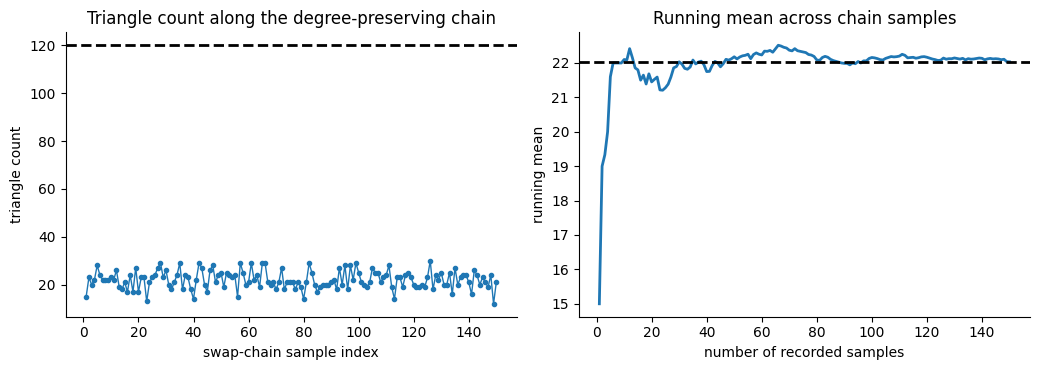

Lag-1 correlation of successive triangle counts: -0.027
Null mean from the recorded chain            : 22.033


In [29]:
chain_triangles = np.asarray(triangles_deg, dtype=float)
running_mean_triangles = np.cumsum(chain_triangles) / np.arange(1, len(chain_triangles) + 1)

if np.std(chain_triangles[:-1]) > 0 and np.std(chain_triangles[1:]) > 0:
    lag1 = np.corrcoef(chain_triangles[:-1], chain_triangles[1:])[0, 1]
else:
    lag1 = np.nan

fig, axes = plt.subplots(1, 2, figsize=(10.5, 3.8), dpi=100)

axes[0].plot(np.arange(1, len(chain_triangles) + 1), chain_triangles, marker="o", markersize=3, linewidth=1)
axes[0].axhline(obs_triangles, linestyle="--", linewidth=2, color=REFERENCE_LINE_COLOR)
axes[0].set_xlabel("swap-chain sample index")
axes[0].set_ylabel("triangle count")
axes[0].set_title("Triangle count along the degree-preserving chain")

axes[1].plot(np.arange(1, len(chain_triangles) + 1), running_mean_triangles, linewidth=2)
axes[1].axhline(np.mean(chain_triangles), linestyle="--", linewidth=2, color=REFERENCE_LINE_COLOR)
axes[1].set_xlabel("number of recorded samples")
axes[1].set_ylabel("running mean")
axes[1].set_title("Running mean across chain samples")

plt.tight_layout()
plt.show()

print("Lag-1 correlation of successive triangle counts:", round(float(lag1), 3))
print("Null mean from the recorded chain            :", round(float(np.mean(chain_triangles)), 3))


The point is not that this chain is wrong. The point is that the Monte Carlo procedure is part of the method.

For a teaching notebook, a modest chain is enough to show the idea. For real motif studies, we usually want to think about at least four diagnostics:

- whether the swap chain has mixed away from its starting graph,
- how many swaps occur between recorded samples,
- whether the null standard deviation is stable enough for a z-score to be meaningful,
- whether the same scientific conclusion survives under more than one plausible null.

One practical edge case is already handled in the code: if the null standard deviation is zero, the z-score is undefined, so `z_from_samples` returns `NaN` instead of pretending the evidence is infinite.


A running mean is helpful, but students usually care about the inferential summaries themselves. The next plot recomputes the triangle z-score and empirical upper-tail p-value after the first $R$ recorded null samples for $R=10,11,\dots$.

We should not expect perfect stability on a short chain. The point is to see that the reported z-score is itself a Monte Carlo estimate, not a fixed constant attached to the graph.

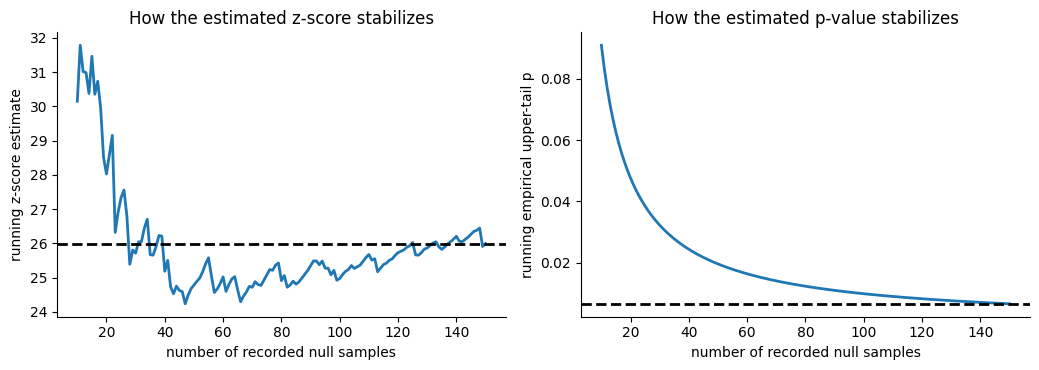

In [30]:
running_rows = []
for R in range(10, len(chain_triangles) + 1):
    sample_prefix = chain_triangles[:R]
    mu_R, sd_R, z_R = z_from_samples(sample_prefix, obs_triangles)
    p_R = empirical_upper_tail_p(sample_prefix, obs_triangles)
    running_rows.append(
        {
            "R": R,
            "z_estimate": z_R,
            "empirical_p_upper": p_R,
        }
    )

df_running_null = pd.DataFrame(running_rows)

fig, axes = plt.subplots(1, 2, figsize=(10.5, 3.8), dpi=100)

axes[0].plot(df_running_null["R"], df_running_null["z_estimate"], linewidth=2)
axes[0].axhline(df_running_null["z_estimate"].iloc[-1], linestyle="--", linewidth=2, color=REFERENCE_LINE_COLOR)
axes[0].set_xlabel("number of recorded null samples")
axes[0].set_ylabel("running z-score estimate")
axes[0].set_title("How the estimated z-score stabilizes")

axes[1].plot(df_running_null["R"], df_running_null["empirical_p_upper"], linewidth=2)
axes[1].axhline(df_running_null["empirical_p_upper"].iloc[-1], linestyle="--", linewidth=2, color=REFERENCE_LINE_COLOR)
axes[1].set_xlabel("number of recorded null samples")
axes[1].set_ylabel("running empirical upper-tail p")
axes[1].set_title("How the estimated p-value stabilizes")

plt.tight_layout()
plt.show()

When these curves drift, the graph has not changed. What changed is our estimate of the null mean, null variance, and tail probability. That is the practical meaning of the phrase **null samples are data too**.

### A directed end-to-end example: planted feed-forward loops

Undirected triangles are the easiest motif to teach, but directed motifs are where the classic network-motif literature became especially influential.

We will now do a small end-to-end example on a directed graph.

1. Generate a directed graph.
2. Plant extra feed-forward loops.
3. Count triad types in the observed graph.
4. Generate a null ensemble by **directed degree-preserving edge swaps**.
5. Compute triad z-scores and empirical enrichment p-values across the 16 triad-census categories.

This is a small version of the standard motif-discovery workflow.


A directed degree-preserving null needs the directed analogue of the same edge-swap idea. We swap $(u,v)$ and $(x,y)$ into $(u,y)$ and $(x,v)$, but only when that keeps the graph simple and preserves both the in-degree and out-degree of every node.


In [31]:
def directed_edge_swap(G, nswap=1, max_tries=10000, rng_local=None):
    """Degree-preserving edge swaps for a simple directed graph."""
    if rng_local is None:
        rng_local = random.Random(SEED)

    if not G.is_directed():
        raise ValueError("directed_edge_swap expects an nx.DiGraph.")

    H = G.copy()
    swaps = 0
    tries = 0

    while swaps < nswap and tries < max_tries:
        tries += 1
        edges = list(H.edges())
        if len(edges) < 2:
            break

        (u, v), (x, y) = rng_local.sample(edges, 2)
        if len({u, v, x, y}) < 4:
            continue
        if u == y or x == v:
            continue
        if H.has_edge(u, y) or H.has_edge(x, v):
            continue

        H.remove_edge(u, v)
        H.remove_edge(x, y)
        H.add_edge(u, y)
        H.add_edge(x, v)
        swaps += 1

    return H


In [32]:
D_check = nx.gnp_random_graph(20, 0.15, seed=SEED, directed=True)
D_check.remove_edges_from(nx.selfloop_edges(D_check))
din_before = sorted(d for _, d in D_check.in_degree())
dout_before = sorted(d for _, d in D_check.out_degree())
D_check_swapped = directed_edge_swap(D_check, nswap=200, max_tries=20000, rng_local=random.Random(SEED))
din_after = sorted(d for _, d in D_check_swapped.in_degree())
dout_after = sorted(d for _, d in D_check_swapped.out_degree())

In [33]:
def triad_census_bruteforce(D):
    """Brute-force triad census for a directed graph."""
    counts = Counter({name: 0 for name in nx.algorithms.triads.TRIAD_NAMES})
    triads_mod = nx.algorithms.triads
    for v, u, w in combinations(D.nodes(), 3):
        code = triads_mod._tricode(D, v, u, w)
        name = triads_mod.TRICODE_TO_NAME[code]
        counts[name] += 1
    return counts


def triad_null_summary(D, R=80, nswap=200, seed=SEED):
    """Triad counts, null moments, z-scores, and empirical upper-tail p-values."""
    obs = nx.triadic_census(D)
    triad_types = sorted(obs.keys())

    chain = D.copy()
    rng_local = random.Random(seed)
    samples = []

    for _ in range(R):
        chain = directed_edge_swap(chain, nswap=nswap, max_tries=20000, rng_local=rng_local)
        samples.append(nx.triadic_census(chain))

    mu = {}
    sd = {}
    z = {}
    p_upper = {}
    for triad_name in triad_types:
        vals = np.array([s[triad_name] for s in samples], dtype=float)
        mu[triad_name] = vals.mean()
        sd[triad_name] = vals.std(ddof=1)
        z[triad_name] = (obs[triad_name] - mu[triad_name]) / sd[triad_name] if sd[triad_name] > 0 else np.nan
        p_upper[triad_name] = empirical_upper_tail_p(vals, obs[triad_name])

    return obs, mu, sd, z, p_upper


In [34]:
D_planted = nx.gnp_random_graph(28, 0.06, seed=SEED, directed=True)
D_planted.remove_edges_from(nx.selfloop_edges(D_planted))

rng_ffl = random.Random(SEED)
planted_triples = [tuple(rng_ffl.sample(list(D_planted.nodes()), 3)) for _ in range(18)]
for i, j, k in planted_triples:
    D_planted.add_edge(i, j)
    D_planted.add_edge(j, k)
    D_planted.add_edge(i, k)

obs_triad, mu_triad, sd_triad, z_triad, p_triad = triad_null_summary(
    D_planted,
    R=70,
    nswap=150,
    seed=SEED,
)

triad_df = pd.DataFrame(
    {
        "triad": list(obs_triad.keys()),
        "observed": [obs_triad[t] for t in obs_triad],
        "null_mean": [mu_triad[t] for t in obs_triad],
        "null_sd": [sd_triad[t] for t in obs_triad],
        "z": [z_triad[t] for t in obs_triad],
        "empirical_p_upper": [p_triad[t] for t in obs_triad],
    }
).sort_values("z", ascending=False)

display(triad_df.head(8))

,triad,observed,null_mean,null_sd,z,empirical_p_upper
1,012,1299,1224.757143,32.818533,2.262224,0.028169
8,030T,34,21.600000,5.734210,2.162460,0.042254
12,120U,4,1.728571,1.178570,1.927275,0.084507
14,210,1,0.428571,0.603647,0.946628,0.380282
9,030C,7,5.642857,2.092330,0.648627,0.352113
10,201,1,1.228571,1.181640,-0.193436,0.690141
6,111D,18,19.857143,6.945514,-0.267387,0.619718
11,120D,1,1.442857,1.137448,-0.389343,0.732394


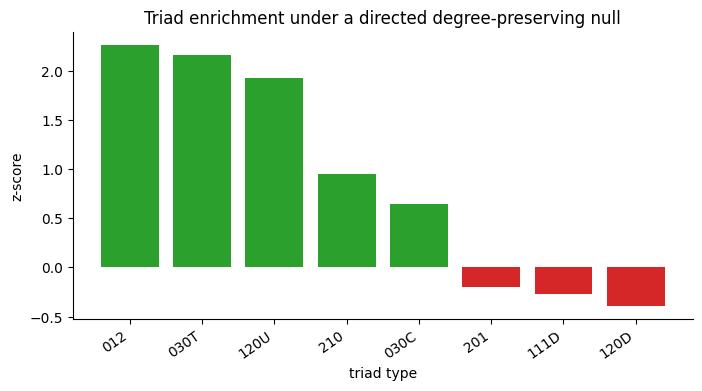

The transitive triad 030T is the induced version of a feed-forward loop.
Observed 030T count: 34
Null mean 030T     : 21.6
z-score for 030T   : 2.16
Upper-tail p for 030T: 0.0423


In [35]:
fig, ax = plt.subplots(figsize=(8, 3.8), dpi=100)
top = triad_df.head(8)
ax.bar(top["triad"], top["z"], color=["tab:green" if z >= 0 else "tab:red" for z in top["z"]])
ax.set_xlabel("triad type")
ax.set_ylabel("z-score")
ax.set_title("Triad enrichment under a directed degree-preserving null")
plt.xticks(rotation=35, ha="right")
plt.show()

print("The transitive triad 030T is the induced version of a feed-forward loop.")
print("Observed 030T count:", obs_triad["030T"])
print("Null mean 030T     :", round(mu_triad["030T"], 2))
print("z-score for 030T   :", round(z_triad["030T"], 2))
print("Upper-tail p for 030T:", round(p_triad["030T"], 4))


Even in this tiny example, the workflow matters more than the raw count. Planting extra feed-forward loops raises the count of a specific directed triad type, but the scientific claim only becomes meaningful after comparison to a null that preserves the degree sequences.

There is also a practical inferential caution here. We are screening **all 16 triad-census categories** at once, so the table is best read as a ranked diagnostic rather than as the final word on significance. In larger studies, it is common to pair motif z-scores with empirical p-values, multiple-testing control, and robustness checks across more than one null model.

That is the basic motif logic in one sentence:

> Count a local pattern, choose a baseline, quantify deviation, then interpret carefully.


## 7. Interpretation, robustness, and a compact view of the $dK$ idea

The strongest version of the motif lesson is this:

> a motif claim is always conditional on what the null model is forced to preserve.

The $dK$ viewpoint packages that idea into a hierarchy of increasingly strict local constraints.

Start with an observed graph $G_0$. Instead of describing a small pattern only by its **shape**, the $dK$ series describes it by shape **and** by the degrees of the participating nodes in $G_0$. Those fixed degrees act like labels carried by the motif. The result is a sequence of null models that preserve richer and richer local structure.

If we write $\Delta_d(G)$ for the counts of connected induced degree-labeled motifs on $d$ vertices, then a $dK$ null keeps that degree-labeled local description fixed while randomizing everything else it still can. This is why the hierarchy is often called **inclusive**: once a null preserves a richer degree-labeled local description, it also preserves the lower-order ingredients nested inside it.

A practical mental menu is:

- **0K** preserves only average degree or density,
- **1K** preserves the full degree sequence,
- **2K** preserves the joint degree distribution across edges,
- **3K** preserves degree-labeled wedges and triangles,
- **4K** preserves degree-labeled connected 4-node motifs.

Why does this matter for interpretation?

A triangle can look highly enriched under a density-matched Erdős-Rényi null simply because the real graph has heterogeneous degrees. It may still look enriched under a 1K null. Under a 2K null, some of that apparent enrichment may disappear again if degree-degree mixing already explains much of the closure. And under a true 3K null, degree-labeled 3-node motifs are no longer the thing being tested at all, because they are built into the baseline.

So the deeper lesson is not the notation by itself. The lesson is that a “motif” can stop being surprising as soon as the null model becomes rich enough to encode the mechanism that produced it.

Appendix B makes this concrete on toy graphs and small computations.


We will compute $\Delta_1$, $\Delta_2$, and $\Delta_3$ explicitly in Appendix B, and we will also build tiny 1K and 2K samplers there so the preservation logic is something you can see rather than just hear about.


## Motifs summary

By now we have three distinct but connected ideas.

First, a graphlet census is a **descriptive** summary of local structure.

Second, motif discovery is a **statistical** statement that depends on what the null model preserves.

Third, triads are the perfect transition point to signed networks, because once edges can be positive or negative, the same three-node pattern can encode consistency, tension, alliance, conflict, or hierarchy.

That is where we turn next.


# The pivot: from unsigned local patterns to signed triads

Up to now a triad has been described by **which edges exist**.

But many real systems care about **what kind** of edge exists. Friendship versus hostility. Trust versus distrust. Activation versus inhibition. Alliance versus conflict.

The cleanest place to feel that shift is a triangle. In an unsigned graph, a triangle is just a triangle. In a signed graph, there are four sign patterns up to symmetry.


In [36]:
def make_signed_triangle(signs):
    """Create a 3-node signed triangle from a list like [+1, +1, -1]."""
    G = nx.Graph()
    G.add_nodes_from([0, 1, 2])
    edges = [(0, 1), (1, 2), (0, 2)]
    for edge, s in zip(edges, signs):
        G.add_edge(*edge, **{SIGN: int(s)})
    return G


signed_triangle_examples = [
    ("+++", [+1, +1, +1]),
    ("++-", [+1, +1, -1]),
    ("+--", [+1, -1, -1]),
    ("---", [-1, -1, -1]),
]

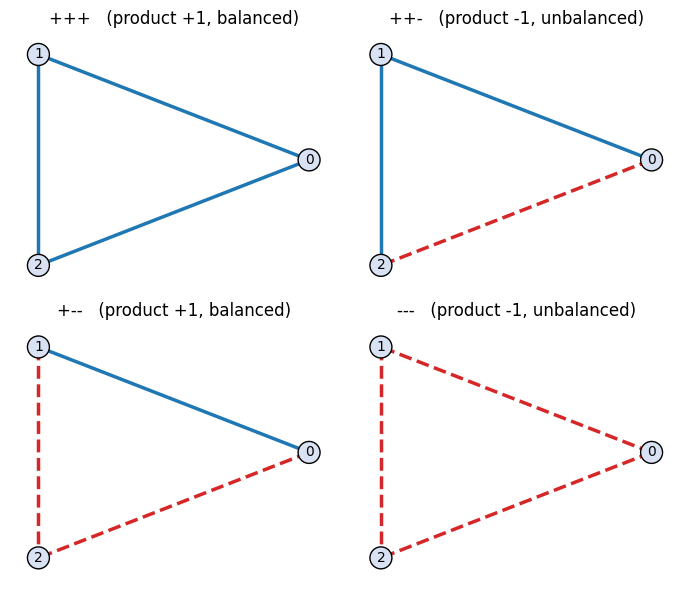

In [37]:
fig, axes = plt.subplots(2, 2, figsize=(7, 6), dpi=100)
for ax, (label, signs) in zip(axes.ravel(), signed_triangle_examples):
    G_ex = make_signed_triangle(signs)
    product = np.prod(signs)
    balance_label = "balanced" if product > 0 else "unbalanced"
    draw_signed_graph(G_ex, ax=ax, title=f"{label}   (product {product:+d}, {balance_label})", pos=nx.circular_layout(G_ex))
plt.tight_layout()
plt.show()

For a signed triangle on nodes $i,j,k$, define the sign product

$$
\sigma(i,j,k) = s_{ij}s_{jk}s_{ki},
$$

where each edge sign $s_{ab}$ is either $+1$ or $-1$.

This quantity is doing exactly what we want:

- $\sigma(i,j,k)=+1$ means the triangle has an **even** number of negative edges,
- $\sigma(i,j,k)=-1$ means the triangle has an **odd** number of negative edges.

That one formula is the bridge between the two halves of the notebook. In Part I, triads were local patterns. In Part II, those same triads become local statements about **consistency versus tension**.

The rest of the signed-network material can be read as the question:

> what happens when we take motif thinking seriously, but now the local patterns are signed?


## Your turn!

Which signed triangle patterns would you expect to be common in each of the following settings?

- a two-camp rivalry system
- a trust network inside a cohesive team
- a biological regulation system with activation and inhibition
- an online reputation system

There is not always one right answer, but the exercise forces you to connect sign patterns to domain meaning rather than treating sign as decoration.


# Part II: Signed Networks

![](images/signed_nets.png)

## 8. Why signed edges matter

Unsigned graphs collapse very different relations into the same binary question: is an edge present or not?

That collapse can be too aggressive. A positive and a negative relation may have opposite consequences for closure, diffusion, consensus, and community structure. A negative tie is not "missing information." It is often the point of the model.

The local signed-triad story is classically associated with Heider (1946), and its graph-theoretic balance formulation was developed by Harary (1953) and Cartwright and Harary (1956).

Signed edges appear in many domains:

- trust and distrust in reputation systems,
- friendship and hostility in social data,
- support and opposition in political data,
- activation and inhibition in biological regulation,
- positive and negative association in correlation-derived networks.

The last example needs special care: a negative correlation is **not automatically** an antagonistic relation. We will return to that caveat later.


For the signed-network half of the notebook, we will lean a lot on the recent review by Diaz-Diaz et al. (2026). It is one of the clearest overviews of what signed-network methods are actually doing, where the standard definitions come from, and where the main pitfalls still are.


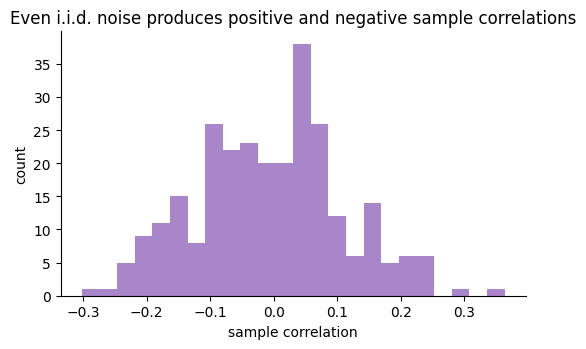

In [38]:
# A tiny reminder that correlations can be signed even when the data-generating process has no antagonism.
X = rng.normal(size=(80, 24))
C = np.corrcoef(X, rowvar=False)
corr_vals = C[np.triu_indices_from(C, k=1)]

fig, ax = plt.subplots(figsize=(6, 3.5), dpi=100)
ax.hist(corr_vals, bins=24, color="tab:purple", alpha=0.8)
ax.set_xlabel("sample correlation")
ax.set_ylabel("count")
ax.set_title("Even i.i.d. noise produces positive and negative sample correlations")
plt.show()


The histogram above is a caution, not a contradiction.

The mathematics of signed graphs is perfectly well-defined even when signs come from thresholded correlations. But the *semantics* change. A negative edge in a friendship network and a negative edge in a correlation network are not the same kind of statement.

That is why signed-network interpretation always starts with: **what does the sign mean in this dataset?**


## 9. Signed representations

For an undirected signed graph, the signed adjacency matrix $A$ is

$$
A_{ij} =
\begin{cases}
+1 & \text{if } i \text{ and } j \text{ share a positive edge},\\
-1 & \text{if } i \text{ and } j \text{ share a negative edge},\\
0 & \text{if no edge is present.}
\end{cases}
$$

Two derived matrices are especially useful:

$$
A^+_{ij} = \max(A_{ij}, 0),
\qquad
A^-_{ij} = \max(-A_{ij}, 0).
$$

These are the positive and negative layers. They satisfy

$$
A = A^+ - A^-,
\qquad
|A| = A^+ + A^-.
$$

This decomposition is useful because many signed methods can be understood as interactions between a positive layer and a negative layer.


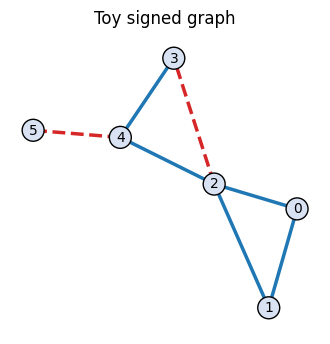

In [39]:
# A small signed graph we will reuse in several sections.
G_signed_toy = nx.Graph()
G_signed_toy.add_nodes_from(range(6))

# Positive triangle on {0,1,2}
G_signed_toy.add_edge(0, 1, **{SIGN: +1})
G_signed_toy.add_edge(1, 2, **{SIGN: +1})
G_signed_toy.add_edge(2, 0, **{SIGN: +1})

# A second triangle with one negative edge
G_signed_toy.add_edge(2, 3, **{SIGN: -1})
G_signed_toy.add_edge(3, 4, **{SIGN: +1})
G_signed_toy.add_edge(2, 4, **{SIGN: +1})

# Tail
G_signed_toy.add_edge(4, 5, **{SIGN: -1})

fig, ax = plt.subplots(figsize=(4, 4), dpi=100)
draw_signed_graph(G_signed_toy, ax=ax, title="Toy signed graph", pos=nx.spring_layout(G_signed_toy, seed=SEED))
plt.show()

In [40]:
def signed_adjacency_matrix(G, nodelist=None):
    """Return the signed adjacency matrix and node order for an undirected signed graph."""
    if nodelist is None:
        nodelist = list(G.nodes())

    idx = {u: i for i, u in enumerate(nodelist)}
    A = np.zeros((len(nodelist), len(nodelist)), dtype=float)

    for u, v, d in G.edges(data=True):
        s = float(d.get(SIGN, +1))
        i = idx[u]
        j = idx[v]
        A[i, j] = s
        A[j, i] = s

    return A, nodelist

In [41]:
A_signed, signed_nodes = signed_adjacency_matrix(G_signed_toy)
A_pos = np.maximum(A_signed, 0)
A_neg = np.maximum(-A_signed, 0)

print("Signed adjacency matrix A")
display(pd.DataFrame(A_signed, index=signed_nodes, columns=signed_nodes))

Signed adjacency matrix A


,0,1,2,3,4,5
0,0.0,1.0,1.0,0.0,0.0,0.0
1,1.0,0.0,1.0,0.0,0.0,0.0
2,1.0,1.0,0.0,-1.0,1.0,0.0
3,0.0,0.0,-1.0,0.0,1.0,0.0
4,0.0,0.0,1.0,1.0,0.0,-1.0
5,0.0,0.0,0.0,0.0,-1.0,0.0


In [42]:
print("Positive layer A_pos")
display(pd.DataFrame(A_pos, index=signed_nodes, columns=signed_nodes))

Positive layer A_pos


,0,1,2,3,4,5
0,0.0,1.0,1.0,0.0,0.0,0.0
1,1.0,0.0,1.0,0.0,0.0,0.0
2,1.0,1.0,0.0,0.0,1.0,0.0
3,0.0,0.0,0.0,0.0,1.0,0.0
4,0.0,0.0,1.0,1.0,0.0,0.0
5,0.0,0.0,0.0,0.0,0.0,0.0


In [43]:
print("Negative layer A_neg")
display(pd.DataFrame(A_neg, index=signed_nodes, columns=signed_nodes))

Negative layer A_neg


,0,1,2,3,4,5
0,-0.0,0.0,0.0,-0.0,-0.0,-0.0
1,0.0,-0.0,0.0,-0.0,-0.0,-0.0
2,0.0,0.0,-0.0,1.0,0.0,-0.0
3,-0.0,-0.0,1.0,-0.0,0.0,-0.0
4,-0.0,-0.0,0.0,0.0,-0.0,1.0
5,-0.0,-0.0,-0.0,-0.0,1.0,-0.0


The matrix identities above are not just bookkeeping. They tell us how to define basic signed statistics.

For an unweighted signed graph, the positive degree and negative degree of node $i$ are

$$
k_i^+ = \sum_j \mathbb{1}[A_{ij} > 0],
\qquad
k_i^- = \sum_j \mathbb{1}[A_{ij} < 0].
$$

From these we get two more summaries:

$$
k_i^{\mathrm{abs}} = k_i^+ + k_i^-,
\qquad
k_i^{\mathrm{net}} = k_i^+ - k_i^-.
$$

Here:

- $k_i^{\mathrm{abs}}$ is the ordinary degree in the underlying unsigned graph,
- $k_i^{\mathrm{net}}$ measures the local balance between positive and negative ties.

The next cell computes all four quantities on the toy graph.


In [44]:
def signed_degrees(G):
    """Return positive, negative, absolute, and net degrees as dictionaries."""
    k_pos = {u: 0 for u in G.nodes()}
    k_neg = {u: 0 for u in G.nodes()}

    for u, v, d in G.edges(data=True):
        if d.get(SIGN, +1) > 0:
            k_pos[u] += 1
            k_pos[v] += 1
        else:
            k_neg[u] += 1
            k_neg[v] += 1

    k_abs = {u: k_pos[u] + k_neg[u] for u in G.nodes()}
    k_net = {u: k_pos[u] - k_neg[u] for u in G.nodes()}
    return k_pos, k_neg, k_abs, k_net

In [45]:
k_pos, k_neg, k_abs, k_net = signed_degrees(G_signed_toy)

df_signed_deg = pd.DataFrame(
    {
        "k_pos": pd.Series(k_pos),
        "k_neg": pd.Series(k_neg),
        "k_abs": pd.Series(k_abs),
        "k_net": pd.Series(k_net),
    }
).sort_index()
display(df_signed_deg)

,k_pos,k_neg,k_abs,k_net
0,2,0,2,2
1,2,0,2,2
2,3,1,4,2
3,1,1,2,0
4,2,1,3,1
5,0,1,1,-1


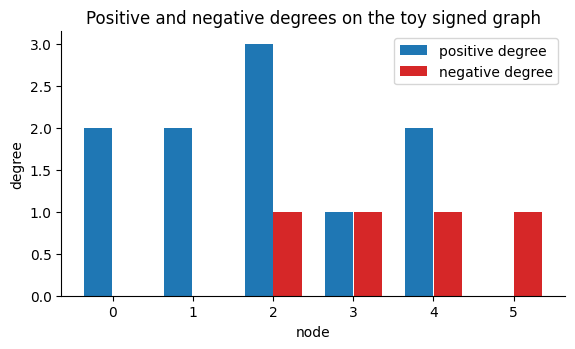

In [46]:

fig, ax = plt.subplots(figsize=(6.5, 3.5), dpi=100)
x = np.arange(len(df_signed_deg))
ax.bar(x - 0.18, df_signed_deg["k_pos"], width=0.35, label="positive degree", color=POS_EDGE_COLOR)
ax.bar(x + 0.18, df_signed_deg["k_neg"], width=0.35, label="negative degree", color=NEG_EDGE_COLOR)
ax.set_xticks(x)
ax.set_xticklabels(df_signed_deg.index)
ax.set_xlabel("node")
ax.set_ylabel("degree")
ax.set_title("Positive and negative degrees on the toy signed graph")
ax.legend()
plt.show()

A quick reading habit is worth building here.

- $k_i^{\mathrm{abs}}$ tells us **how many** signed relations touch node $i$.
- $k_i^{\mathrm{net}}$ tells us the **direction** of the local sign balance.

Those are not the same question. Two nodes can have the same absolute degree and very different signed neighborhoods depending on how many of those ties are positive versus negative.

## 10. Signed walks and the parity lift

In an unsigned graph, a walk is mostly about connectivity and length. In a signed graph, a walk also has a **parity**: the product of the signs along its edges.

If a walk uses an even number of negative edges, its sign product is positive. If it uses an odd number of negative edges, its sign product is negative.

That makes matrix powers meaningful in a new way. For a signed adjacency matrix $A$,

$$
(A^k)_{ij}
$$

is the number of positive length-$k$ walks from $i$ to $j$ **minus** the number of negative length-$k$ walks from $i$ to $j$.

That statement is worth checking directly.


In [47]:
def count_signed_walks(G, source, target, k):
    """Count positive and negative walks of length k between two nodes.

    The function uses dynamic programming over walk length and parity of the
    number of negative edges.
    """
    dp = {source: (1, 0)}  # node -> (positive count, negative count) at length 0

    for _ in range(k):
        new = defaultdict(lambda: (0, 0))
        for u, (pos_ct, neg_ct) in dp.items():
            for v in G.neighbors(u):
                s = G[u][v].get(SIGN, +1)
                cur_pos, cur_neg = new[v]
                if s > 0:
                    new[v] = (cur_pos + pos_ct, cur_neg + neg_ct)
                else:
                    new[v] = (cur_pos + neg_ct, cur_neg + pos_ct)
        dp = new

    return dp.get(target, (0, 0))

In [48]:

node_to_idx = {u: i for i, u in enumerate(signed_nodes)}

rows = []
for k in [1, 2, 3, 4]:
    pos_ct, neg_ct = count_signed_walks(G_signed_toy, source=0, target=4, k=k)
    signed_count = np.linalg.matrix_power(A_signed, k)[node_to_idx[0], node_to_idx[4]]
    total_count = np.linalg.matrix_power(np.abs(A_signed), k)[node_to_idx[0], node_to_idx[4]]
    rows.append(
        {
            "k": k,
            "positive_walks": pos_ct,
            "negative_walks": neg_ct,
            "A^k entry (pos-neg)": signed_count,
            "|A|^k entry (pos+neg)": total_count,
        }
    )

df_walks = pd.DataFrame(rows)
display(df_walks)

,k,positive_walks,negative_walks,A^k entry (pos-neg),|A|^k entry (pos+neg)
0,1,0,0,0.0,0.0
1,2,1,0,1.0,1.0
2,3,1,1,0.0,2.0
3,4,7,1,6.0,8.0


A very useful way to organize this idea is the **parity lift**.

Create two copies of every node: $(i,+)$ and $(i,-)$. Then:

- a positive edge keeps you in the same layer,
- a negative edge sends you to the opposite layer.

In matrix form, the lift of a signed adjacency matrix $A$ is

$$
B =
\begin{pmatrix}
A^+ & A^- \\
A^- & A^+
\end{pmatrix}.
$$

This looks like a technical trick, but it is conceptually powerful. It turns signed walk parity into an ordinary unsigned walk problem on a larger graph.


For a concrete trace, consider nodes 2 and 3 in the toy signed graph, which are connected by a negative edge. A length-2 walk from node 0 to node 3 that passes through node 2 starts at state $(0,+)$, moves to $(2,+)$ via the positive edge $\{0,2\}$, and then moves to $(3,-)$ via the negative edge $\{2,3\}$. The walk ends in the opposite layer, exactly because the walk sign is negative.


In [49]:
def parity_lift_matrix_from_A(A):
    """Return the 2n x 2n parity-lift adjacency matrix."""
    A_pos = np.maximum(A, 0)
    A_neg = np.maximum(-A, 0)
    top = np.hstack([A_pos, A_neg])
    bottom = np.hstack([A_neg, A_pos])
    return np.vstack([top, bottom])


In [50]:

B_lift = parity_lift_matrix_from_A(A_signed)

rows = []
for k in [1, 2, 3, 4]:
    Bk = np.linalg.matrix_power(B_lift, k)
    i = node_to_idx[0]
    j = node_to_idx[4]
    pos_from_lift = Bk[i, j]
    neg_from_lift = Bk[i, j + len(signed_nodes)]
    pos_ct, neg_ct = count_signed_walks(G_signed_toy, source=0, target=4, k=k)
    rows.append(
        {
            "k": k,
            "positive from graph count": pos_ct,
            "positive from lift": pos_from_lift,
            "negative from graph count": neg_ct,
            "negative from lift": neg_from_lift,
        }
    )

df_lift = pd.DataFrame(rows)
display(df_lift)

,k,positive from graph count,positive from lift,negative from graph count,negative from lift
0,1,0,0.0,0,-0.0
1,2,1,1.0,0,0.0
2,3,1,1.0,1,1.0
3,4,7,7.0,1,1.0


The block matrix is correct, but it becomes much easier to remember once we draw the lifted graph itself. To keep the picture readable, we will visualize the lift of a four-node signed subgraph.

Read the lifted graph left to right:

- the top row is the $+$ layer,
- the bottom row is the $-$ layer,
- blue edges stay within a layer because the original edge was positive,
- red edges jump across layers because the original edge was negative.

In [51]:
lift_nodes = [0, 2, 3, 4]
G_lift_demo = G_signed_toy.subgraph(lift_nodes).copy()

H_lift_demo = nx.Graph()
for u in G_lift_demo.nodes():
    H_lift_demo.add_node((u, +1))
    H_lift_demo.add_node((u, -1))

for u, v, d in G_lift_demo.edges(data=True):
    s = +1 if d.get(SIGN, +1) > 0 else -1
    H_lift_demo.add_edge((u, +1), (v, s))
    H_lift_demo.add_edge((u, -1), (v, -s))

pos_original = nx.spring_layout(G_lift_demo, seed=SEED)
pos_lift_demo = {}
for i, u in enumerate(lift_nodes):
    pos_lift_demo[(u, +1)] = (i, 1.0)
    pos_lift_demo[(u, -1)] = (i, 0.0)

lift_edge_colors = []
for a, b in H_lift_demo.edges():
    same_layer = a[1] == b[1]
    lift_edge_colors.append(POS_EDGE_COLOR if same_layer else NEG_EDGE_COLOR)

lift_labels = {(u, s): f"{u}{'+' if s > 0 else '-'}" for u, s in H_lift_demo.nodes()}

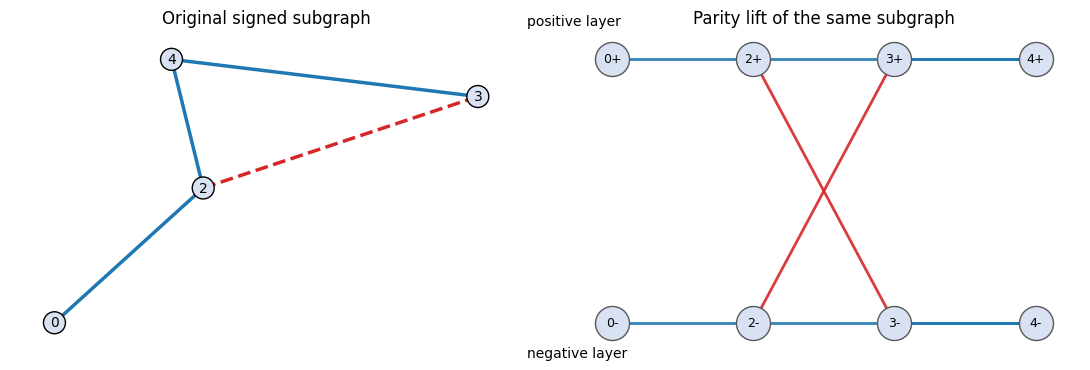

In [52]:
fig, axes = plt.subplots(1, 2, figsize=(11.0, 3.8), dpi=100)

draw_signed_graph(
    G_lift_demo,
    ax=axes[0],
    title="Original signed subgraph",
    pos=pos_original,
)

nx.draw_networkx_nodes(
    H_lift_demo,
    pos_lift_demo,
    node_size=600,
    node_color=NODE_FILL_COLOR,
    edgecolors=EDGE_DRAW_COLOR,
    linewidths=1.0,
    ax=axes[1],
)
nx.draw_networkx_edges(
    H_lift_demo,
    pos_lift_demo,
    edge_color=lift_edge_colors,
    width=2.0,
    alpha=0.9,
    ax=axes[1],
)
nx.draw_networkx_labels(H_lift_demo, pos_lift_demo, labels=lift_labels, font_size=9, ax=axes[1])

axes[1].set_title("Parity lift of the same subgraph")
axes[1].text(-0.6, 1.13, "positive layer", fontsize=10)
axes[1].text(-0.6, -0.13, "negative layer", fontsize=10)
axes[1].set_axis_off()

plt.tight_layout()
plt.show()

This picture shows why the parity lift is more than a trick. A signed question about walk parity becomes an ordinary reachability question in a doubled unsigned graph. Distances $d^+(i,j)$ and $d^-(i,j)$ are just shortest-path lengths from $(i,+)$ to $(j,+)$ and $(j,-)$ in that lifted graph.

The parity lift also suggests a careful notion of distance.

Instead of forcing one "signed distance" between nodes $i$ and $j$, it is often better to keep two distances:

$$
d^+(i,j) = \text{shortest positive-parity path length},
\qquad
d^-(i,j) = \text{shortest negative-parity path length}.
$$

This pair tells you whether the shortest relationship between two nodes is friendly, antagonistic, or both depending on the available paths.


In [53]:
def parity_lift_graph(G):
    """Build the unsigned parity-lift graph on states (node, parity)."""
    H = nx.Graph()

    for u in G.nodes():
        H.add_node((u, +1))
        H.add_node((u, -1))

    for u, v, d in G.edges(data=True):
        s = +1 if d.get(SIGN, +1) > 0 else -1
        H.add_edge((u, +1), (v, s))
        H.add_edge((u, -1), (v, -s))

    return H


def parity_shortest_distances(G, source):
    """Return the shortest positive- and negative-parity distances from a source."""
    H = parity_lift_graph(G)
    dist = nx.single_source_shortest_path_length(H, (source, +1))
    rows = []
    for u in G.nodes():
        rows.append(
            {
                "node": u,
                "d_plus": dist.get((u, +1), np.inf),
                "d_minus": dist.get((u, -1), np.inf),
            }
        )
    return pd.DataFrame(rows).set_index("node")

In [54]:

df_parity_dist = parity_shortest_distances(G_signed_toy, source=0)
display(df_parity_dist)


,d_plus,d_minus
node,,
0,0,5
1,1,5
2,1,4
3,3,2
4,2,3
5,4,3


The walk viewpoint also leads to a node-level summary that appears throughout signed-network methods: **signed Katz centrality**.

For a signed adjacency matrix $A$ and attenuation parameter $\alpha$, define

$$
x = (I - \alpha A)^{-1}\mathbf{1}
  = \sum_{k=0}^{\infty} \alpha^k A^k \mathbf{1},
\qquad
0 < \alpha < \frac{1}{\rho(A)}.
$$

Every symbol has a concrete interpretation.

- $x_i$ is the Katz score of node $i$.
- $I$ is the identity matrix.
- $\mathbf{1}$ is the all-ones vector.
- $\rho(A)$ is the spectral radius of $A$.
- $\alpha^k$ downweights long walks.

Why does this form make sense? Because $A^k\mathbf{1}$ aggregates length-$k$ signed walks touching each node, so positive and negative walk contributions can reinforce or cancel. In the code below, $A$ is `A_signed`, $\alpha$ is `alpha_katz`, and $x$ is `x_katz_signed`.

This is not the only sensible signed centrality, but it is a clean way to see how the walk-counting story extends from distances to node importance.

For numerical work below we use a slightly stronger safety rule and choose $\alpha$ from $\rho(|A|)$, the spectral radius of the entrywise-absolute matrix. That guarantees the Neumann series converges even before any sign cancellations are taken into account.


In [55]:
def katz_via_series(A, alpha, kmax=20):
    """Approximate Katz scores by truncating the Neumann series."""
    n = A.shape[0]
    x = np.zeros(n)
    Ak = np.eye(n)
    ones = np.ones(n)

    for k in range(kmax + 1):
        x += (alpha ** k) * (Ak @ ones)
        Ak = Ak @ A

    return x

In [56]:
rho_abs = float(np.max(np.abs(np.linalg.eigvalsh(np.abs(A_signed)))))
alpha_katz = 0.75 / rho_abs if rho_abs > 0 else 0.1

x_katz_signed = np.linalg.solve(
    np.eye(len(signed_nodes)) - alpha_katz * A_signed,
    np.ones(len(signed_nodes)),
)
x_katz_abs = np.linalg.solve(
    np.eye(len(signed_nodes)) - alpha_katz * np.abs(A_signed),
    np.ones(len(signed_nodes)),
)
x_katz_series = katz_via_series(A_signed, alpha_katz, kmax=40)
series_error = np.linalg.norm(x_katz_signed - x_katz_series)

df_katz = pd.DataFrame(
    {
        "katz_signed": x_katz_signed,
        "katz_unsigned_support": x_katz_abs,
    },
    index=signed_nodes,
).round(3)
display(df_katz)

,katz_signed,katz_unsigned_support
0,2.493,3.486
1,2.493,3.486
2,2.740,5.228
3,0.749,3.680
4,1.862,4.166
5,0.469,2.189


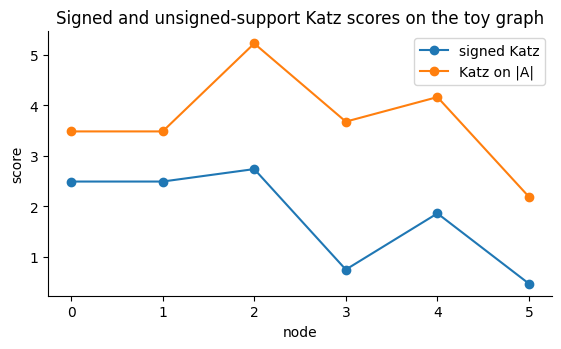

alpha_katz: 0.2853
Series approximation error ||x_direct - x_series||_2: 7e-08


In [57]:
fig, ax = plt.subplots(figsize=(6.5, 3.5), dpi=100)
ax.plot(df_katz.index, df_katz["katz_signed"], marker="o", label="signed Katz", color=POS_EDGE_COLOR)
ax.plot(df_katz.index, df_katz["katz_unsigned_support"], marker="o", label="Katz on |A|", color="tab:orange")
ax.set_xlabel("node")
ax.set_ylabel("score")
ax.set_title("Signed and unsigned-support Katz scores on the toy graph")
ax.legend()
plt.show()

print("alpha_katz:", round(alpha_katz, 4))
print("Series approximation error ||x_direct - x_series||_2:", round(float(series_error), 8))

The comparison is useful precisely because the two curves are **not** the same.

The `katz_unsigned_support` scores only ask whether walks exist on the support graph. The `katz_signed` scores allow cancellation from antagonistic walks. That is why signed node summaries are usually built from $A$, $A^+$, and $A^-$ explicitly rather than by forgetting the signs and applying an unsigned method unchanged.


## Your turn!

Pick two nodes in the toy signed graph and inspect both `d_plus` and `d_minus`.

Can you find a pair for which the shortest positive-parity path is longer than the shortest negative-parity path? What does that mean in words?


## 11. Structural balance: from signed triads to global factions

The most famous idea in signed networks is **structural balance theory**.

The local version starts with triangles.

For a signed triangle on nodes $i,j,k$, recall the sign product

$$
\sigma(i,j,k) = s_{ij}s_{jk}s_{ki}.
$$

If $\sigma(i,j,k)=+1$, the triangle is called **balanced**. If $\sigma(i,j,k)=-1$, it is **unbalanced**.

This recovers the four sign patterns from the pivot section:

- balanced: $+++$ and $+--$
- unbalanced: $++-$ and $---$

One reason this matters is that the same triadic language from motifs now becomes a language of local tension and local consistency.


Another important point is that balance is really a property of a whole **switching class** of sign assignments, not of a single drawing with fixed plus and minus marks. The switching construction just below makes that precise by showing how node sign-flips can transform a balanced graph into an all-positive one without changing its structural content.


In [58]:
def triangle_balance_counts(G):
    """Return counts of balanced and unbalanced triangles in an undirected signed graph."""
    balanced = 0
    unbalanced = 0
    for i, j, k in combinations(G.nodes(), 3):
        if G.has_edge(i, j) and G.has_edge(j, k) and G.has_edge(i, k):
            prod = (
                G[i][j].get(SIGN, +1)
                * G[j][k].get(SIGN, +1)
                * G[i][k].get(SIGN, +1)
            )
            if prod > 0:
                balanced += 1
            else:
                unbalanced += 1
    return balanced, unbalanced


def triangle_index_trace(G):
    """Return tr(A^3) / tr(|A|^3) for an undirected signed graph."""
    A, _ = signed_adjacency_matrix(G)
    num = np.trace(A @ A @ A)
    den = np.trace(np.abs(A) @ np.abs(A) @ np.abs(A))
    return float(num / den) if den != 0 else np.nan


In [59]:


bal_toy, unbal_toy = triangle_balance_counts(G_signed_toy)
tri_index_toy = triangle_index_trace(G_signed_toy)
trace_A3 = np.trace(A_signed @ A_signed @ A_signed)

print("Balanced triangles  :", bal_toy)
print("Unbalanced triangles:", unbal_toy)
print("tr(A^3)             :", trace_A3)
print("6 * (balanced - unbalanced):", 6 * (bal_toy - unbal_toy))
print("Triangle balance index C_tri :", tri_index_toy)


Balanced triangles  : 1
Unbalanced triangles: 1
tr(A^3)             : 0.0
6 * (balanced - unbalanced): 0
Triangle balance index C_tri : 0.0


The trace identity above is worth unpacking.

For an undirected signed adjacency matrix $A$,

$$
\mathrm{tr}(A^3) = 6\big(\#\text{balanced triangles} - \#\text{unbalanced triangles}\big).
$$

And because

$$
\mathrm{tr}(|A|^3) = 6\big(\#\text{all triangles}\big),
$$

the normalized quantity

$$
C_{\mathrm{tri}} = \frac{\mathrm{tr}(A^3)}{\mathrm{tr}(|A|^3)}
$$

measures the excess of balanced over unbalanced triangles among all triangles.

The symbols map directly to the code:

- $A$ is `A_signed`,
- $\mathrm{tr}(A^3)$ is `trace_A3`,
- $C_{\mathrm{tri}}$ is `tri_index_toy`.

A value of $C_{\mathrm{tri}}=1$ means every triangle is balanced. A value near $0$ means balanced and unbalanced triangles largely cancel.


### From triangles to whole graphs

The classical graph-level extension is due to Harary (1953) and Cartwright and Harary (1956).

A signed graph is **strongly balanced** if every cycle has positive sign product. A theorem then says that a connected strongly balanced graph can be partitioned into two groups such that:

- positive edges lie within groups,
- negative edges lie between groups.

So local balance in all cycles implies a global **two-faction** structure.

A weaker notion, due to Davis (1967), allows more than two groups and rules out only cycles with exactly one negative edge. That weaker balance notion is often closer to what real data can support.


In practice, checking a **cycle basis** is enough: every cycle in the graph can be built from basis cycles by symmetric difference, and the sign of the resulting cycle is the product of the signs of those basis cycles.


In [60]:
def cycle_sign(G, cycle):
    """Return the sign product around a cycle."""
    prod = 1
    for t in range(len(cycle)):
        u = cycle[t]
        v = cycle[(t + 1) % len(cycle)]
        prod *= G[u][v].get(SIGN, +1)
    return prod


def is_balanced_cycle_basis(G):
    """Check strong balance by testing whether every cycle in a cycle basis is positive."""
    for comp in nx.connected_components(G):
        H = G.subgraph(comp)
        for cyc in nx.cycle_basis(H):
            if cycle_sign(H, cyc) < 0:
                return False
    return True

In [61]:
def switch_graph(G, x):
    """Switch a signed graph using node labels x_i in {+1, -1}."""
    H = nx.Graph()
    H.add_nodes_from(G.nodes())
    for u, v, d in G.edges(data=True):
        s_new = x[u] * d.get(SIGN, +1) * x[v]
        H.add_edge(u, v, **{SIGN: int(np.sign(s_new))})
    return H


def make_perfectly_balanced_two_faction_graph(n1, n2, p=0.6, seed=SEED):
    """Generate a connected perfectly balanced signed graph with two factions."""
    rng_local = np.random.default_rng(seed)
    G = nx.Graph()

    group1 = list(range(n1))
    group2 = list(range(n1, n1 + n2))
    G.add_nodes_from(group1 + group2)

    for group in [group1, group2]:
        for a, b in zip(group[:-1], group[1:]):
            G.add_edge(a, b, **{SIGN: +1})

    G.add_edge(group1[0], group2[0], **{SIGN: -1})

    for i, j in combinations(group1, 2):
        if not G.has_edge(i, j) and rng_local.random() < p:
            G.add_edge(i, j, **{SIGN: +1})
    for i, j in combinations(group2, 2):
        if not G.has_edge(i, j) and rng_local.random() < p:
            G.add_edge(i, j, **{SIGN: +1})
    for i in group1:
        for j in group2:
            if not G.has_edge(i, j) and rng_local.random() < p:
                G.add_edge(i, j, **{SIGN: -1})

    labels = {u: +1 for u in group1}
    labels.update({u: -1 for u in group2})
    return G, labels

Toy signed graph strongly balanced?       False
Constructed two-faction graph balanced?   True
Balanced graph switches to all-positive?  True


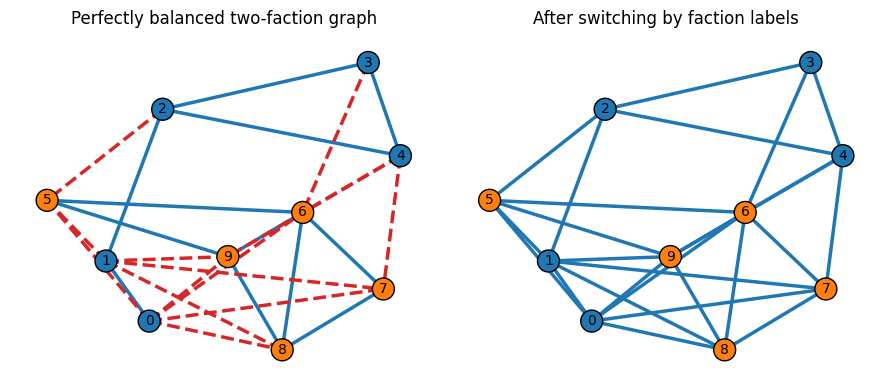

In [62]:
G_balanced, faction_labels = make_perfectly_balanced_two_faction_graph(5, 5, p=0.55, seed=SEED)
print("Toy signed graph strongly balanced?      ", is_balanced_cycle_basis(G_signed_toy))
print("Constructed two-faction graph balanced?  ", is_balanced_cycle_basis(G_balanced))

# Switching a balanced graph by its faction labels should make all edges positive.
G_switched = switch_graph(G_balanced, faction_labels)
all_positive_after_switch = all(d[SIGN] > 0 for _, _, d in G_switched.edges(data=True))
print("Balanced graph switches to all-positive? ", all_positive_after_switch)

fig, axes = plt.subplots(1, 2, figsize=(9, 4), dpi=100)
colors = ["tab:blue" if faction_labels[u] > 0 else "tab:orange" for u in G_balanced.nodes()]
pos_bal = nx.spring_layout(G_balanced, seed=SEED)
draw_signed_graph(G_balanced, ax=axes[0], title="Perfectly balanced two-faction graph", pos=pos_bal, node_colors=colors)
draw_signed_graph(G_switched, ax=axes[1], title="After switching by faction labels", pos=pos_bal, node_colors=colors)
plt.tight_layout()
plt.show()

The switching operation is important enough to name explicitly.

Given node labels $x_i \in \{-1,+1\}$, define the switched edge signs by

$$
s'_{ij} = x_i s_{ij} x_j.
$$

This transformation preserves cycle sign products, so balance is a property of a whole **switching class**, not just one edge labeling.

That is why the theorem "balanced if and only if switchable to all-positive" is so useful. It turns a structural statement about every cycle into a concrete construction.


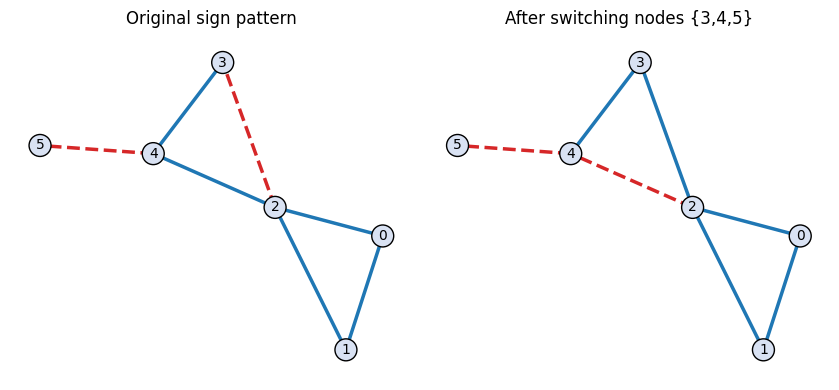

Triangle counts before switching : (1, 1)
Triangle counts after switching  : (1, 1)
C_tri before switching           : 0.0
C_tri after switching            : 0.0


In [63]:
x_switch = {u: (+1 if u in {0, 1, 2} else -1) for u in G_signed_toy.nodes()}
G_switched = switch_graph(G_signed_toy, x_switch)

bal_before, unbal_before = triangle_balance_counts(G_signed_toy)
bal_after, unbal_after = triangle_balance_counts(G_switched)

ctri_before = triangle_index_trace(G_signed_toy)
ctri_after = triangle_index_trace(G_switched)

assert (bal_before, unbal_before) == (bal_after, unbal_after)
assert np.isclose(ctri_before, ctri_after)
assert is_balanced_cycle_basis(G_signed_toy) == is_balanced_cycle_basis(G_switched)

pos_switch = nx.spring_layout(G_signed_toy, seed=SEED)
fig, axes = plt.subplots(1, 2, figsize=(8.5, 4), dpi=100)
draw_signed_graph(G_signed_toy, ax=axes[0], title="Original sign pattern", pos=pos_switch)
draw_signed_graph(G_switched, ax=axes[1], title="After switching nodes {3,4,5}", pos=pos_switch)
plt.tight_layout()
plt.show()

print("Triangle counts before switching :", (bal_before, unbal_before))
print("Triangle counts after switching  :", (bal_after, unbal_after))
print("C_tri before switching           :", round(ctri_before, 3))
print("C_tri after switching            :", round(ctri_after, 3))


### Strong balance versus weak balance

The two-faction theorem is the signature result for **strong** balance. But there is a useful relaxation called **weak balance**.

Weak balance allows more than two groups, as long as positive ties stay within groups and negative ties run across groups. At the triangle level, the distinction is very concrete:

- strong balance allows $+++$ and $+--$,
- weak balance allows those two patterns **and** $---$,
- both notions forbid $++-$.

So the pattern that separates weak from strong balance is the all-negative triangle. A graph with many $---$ triads can still be weakly balanced even though it cannot be represented by only two factions.

One caveat matters here. The clean global characterization of weak balance is sharpest for **complete** signed graphs, or for models where missing edges are interpreted in a principled way. On sparse empirical graphs, the absence of an edge is not automatically the same thing as a neutral or irrelevant relation. So in sparse settings, weak balance should be read with the same care we apply to motif claims: it depends on what information the data actually contain.


In [64]:
def triangle_sign_pattern_counts(G):
    """Count +++, ++-, +--, and --- triangles in an undirected signed graph."""
    counts = Counter({"+++": 0, "++-": 0, "+--": 0, "---": 0})
    for i, j, k in combinations(G.nodes(), 3):
        if G.has_edge(i, j) and G.has_edge(j, k) and G.has_edge(i, k):
            signs = sorted(
                [
                    G[i][j].get(SIGN, +1),
                    G[j][k].get(SIGN, +1),
                    G[i][k].get(SIGN, +1),
                ],
                reverse=True,
            )
            label = "".join("+" if s > 0 else "-" for s in signs)
            counts[label] += 1
    return counts


def make_weakly_balanced_three_group_graph(group_sizes=(2, 2, 2)):
    """Construct a complete signed graph with positive within-group and negative across-group edges."""
    G = nx.Graph()
    labels = {}
    groups = []

    node = 0
    for g, size in enumerate(group_sizes):
        group = []
        for _ in range(size):
            G.add_node(node)
            labels[node] = g
            group.append(node)
            node += 1
        groups.append(group)

    for u, v in combinations(G.nodes(), 2):
        s = +1 if labels[u] == labels[v] else -1
        G.add_edge(u, v, **{SIGN: s})

    return G, labels, groups

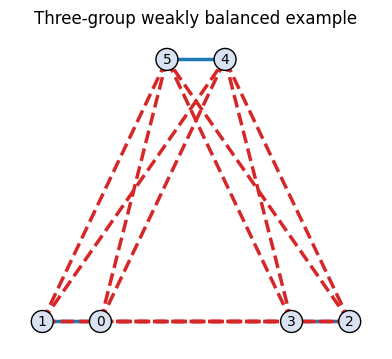

Triangle sign patterns: {'+++': 0, '++-': 0, '+--': 12, '---': 8}
Strongly balanced?     False


In [65]:
G_weak, weak_labels, weak_groups = make_weakly_balanced_three_group_graph((2, 2, 2))
weak_patterns = triangle_sign_pattern_counts(G_weak)

assert weak_patterns["++-"] == 0
assert weak_patterns["---"] > 0
assert not is_balanced_cycle_basis(G_weak)

centers = [(-1.2, 0.0), (1.2, 0.0), (0.0, 1.5)]
pos_weak = {}
for group, center in zip(weak_groups, centers):
    cx, cy = center
    for t, u in enumerate(group):
        angle = 2 * np.pi * t / max(1, len(group))
        pos_weak[u] = np.array([cx + 0.28 * np.cos(angle), cy + 0.28 * np.sin(angle)])

fig, ax = plt.subplots(figsize=(4.8, 4.2), dpi=100)
draw_signed_graph(G_weak, ax=ax, title="Three-group weakly balanced example", pos=pos_weak)
plt.show()

print("Triangle sign patterns:", dict(weak_patterns))
print("Strongly balanced?    ", is_balanced_cycle_basis(G_weak))

This example is pedagogically useful because the message is visible by inspection.

There are no $++-$ triangles, so the local weak-balance rule is satisfied. But there are $---$ triangles using one node from each group, so strong balance fails. That is exactly why weak balance is interpreted as a **multi-camp** generalization of the usual two-faction picture.

Because this example is complete, the global three-group interpretation is clean. In a sparse signed graph, one should be more cautious: missing edges can hide or blur the camp structure that a complete-graph theorem would make explicit.


At this point it helps to compare three local triangle profiles side by side:

- a mixed toy graph,
- a perfectly strongly balanced two-faction graph,
- a weakly balanced three-group graph.

The next figure plots **proportions** rather than raw counts so that graphs with different numbers of triangles stay comparable.

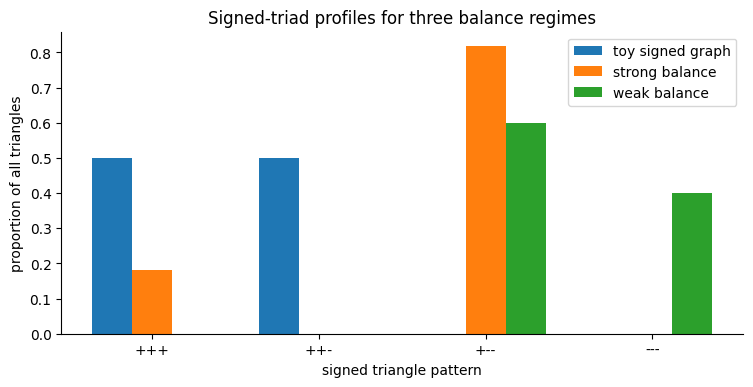

In [66]:
triangle_profile_graphs = {
    "toy signed graph": G_signed_toy,
    "strong balance": G_balanced,
    "weak balance": G_weak,
}

pattern_order = ["+++", "++-", "+--", "---"]
profile_rows = []
for graph_name, G_here in triangle_profile_graphs.items():
    counts_here = triangle_sign_pattern_counts(G_here)
    total_here = sum(counts_here.values())
    for pattern in pattern_order:
        profile_rows.append(
            {
                "graph": graph_name,
                "pattern": pattern,
                "count": counts_here[pattern],
                "proportion": counts_here[pattern] / total_here if total_here > 0 else np.nan,
            }
        )

df_triangle_profiles = pd.DataFrame(profile_rows)

fig, ax = plt.subplots(figsize=(8.8, 4.0), dpi=100)
x = np.arange(len(pattern_order))
width = 0.24
graphs_in_order = list(triangle_profile_graphs.keys())

for shift, graph_name in zip([-width, 0.0, width], graphs_in_order):
    vals = (
        df_triangle_profiles[df_triangle_profiles["graph"] == graph_name]
        .set_index("pattern")
        .loc[pattern_order, "proportion"]
        .values
    )
    ax.bar(x + shift, vals, width=width, label=graph_name)

ax.set_xticks(x)
ax.set_xticklabels(pattern_order)
ax.set_xlabel("signed triangle pattern")
ax.set_ylabel("proportion of all triangles")
ax.set_title("Signed-triad profiles for three balance regimes")
ax.legend()
plt.show()

This comparison keeps the two notions of balance straight.

- **Strong balance** eliminates both $++-$ and $---$.
- **Weak balance** eliminates only $++-$.
- A generic empirical graph can contain all four patterns.

So the signed-triad profile is not just a descriptive table. It is a quick diagnostic of which balance story, if any, is even plausible for the data.

## 12. Balance also needs a null model

Balance measures can look impressive in isolation, but the same warning from motifs returns here:

> a signed-network statistic only has meaning relative to a baseline.

Two especially common baselines are:

1. **sign shuffling on a fixed topology**  
   Keep the underlying graph fixed and randomly permute the signs. This preserves the support of the graph and the overall fraction of negative edges.

2. **rewiring within the positive and negative layers**  
   Rewire the positive layer and the negative layer separately so that each node's positive degree and negative degree stay fixed.

These nulls answer different questions. The first asks whether the observed sign arrangement is special *on the given topology*. The second asks a tougher question: is the observed balance special even after preserving how positive and negative ties are distributed across nodes?


The simplest signed null keeps the underlying topology fixed and only permutes signs. The next cell implements exactly that operation.


In [67]:
def shuffle_edge_signs(G, seed=SEED):
    """Shuffle signs on a fixed undirected topology."""
    rng_local = np.random.default_rng(seed)
    signs = [d.get(SIGN, +1) for _, _, d in G.edges(data=True)]
    rng_local.shuffle(signs)

    H = nx.Graph()
    H.add_nodes_from(G.nodes())
    for (u, v, _), s in zip(G.edges(data=True), signs):
        H.add_edge(u, v, **{SIGN: int(s)})
    return H


def split_by_sign(G):
    """Return positive and negative unsigned layers on the same node set."""
    G_pos = nx.Graph()
    G_neg = nx.Graph()
    G_pos.add_nodes_from(G.nodes())
    G_neg.add_nodes_from(G.nodes())

    for u, v, d in G.edges(data=True):
        if d.get(SIGN, +1) > 0:
            G_pos.add_edge(u, v)
        else:
            G_neg.add_edge(u, v)

    return G_pos, G_neg

A stronger signed null rewires the positive and negative layers separately. This is the signed analogue of a configuration-model swap: positive degrees and negative degrees are kept fixed in their respective layers, but the detailed pairing structure is allowed to change.

To keep the signed graph simple, the two rewired layers must remain edge-disjoint. That is the only subtle point in the implementation below.


In [68]:
def degree_preserving_edge_swaps(G_layer, nswap=1000, seed=SEED, forbidden_edges=None):
    """Degree-preserving swaps in one undirected layer, avoiding a set of forbidden edges."""
    if forbidden_edges is None:
        forbidden_edges = set()

    rng_local = random.Random(seed)
    H = G_layer.copy()
    edges = [(min(u, v), max(u, v)) for u, v in H.edges()]
    edge_set = set(edges)

    if len(edges) < 2:
        return H

    swaps = 0
    tries = 0
    while swaps < nswap and tries < 20000:
        tries += 1
        i1, i2 = rng_local.sample(range(len(edges)), 2)
        a, b = edges[i1]
        c, d = edges[i2]

        if len({a, b, c, d}) < 4:
            continue

        if rng_local.random() < 0.5:
            x, y = a, d
            u, v = c, b
        else:
            x, y = a, c
            u, v = d, b

        if x == y or u == v:
            continue

        e1 = (min(x, y), max(x, y))
        e2 = (min(u, v), max(u, v))

        if e1 in edge_set or e2 in edge_set:
            continue
        if e1 in forbidden_edges or e2 in forbidden_edges:
            continue

        H.remove_edge(a, b)
        H.remove_edge(c, d)
        H.add_edge(*e1)
        H.add_edge(*e2)

        edge_set.remove((a, b))
        edge_set.remove((c, d))
        edge_set.add(e1)
        edge_set.add(e2)

        edges[i1] = e1
        edges[i2] = e2
        swaps += 1

    return H


def signed_degree_preserving_null(G, nswap=1200, seed=SEED):
    """Rewire positive and negative layers separately while keeping them edge-disjoint."""
    G_pos, G_neg = split_by_sign(G)

    neg_forbidden = {tuple(sorted(e)) for e in G_neg.edges()}
    G_pos_rw = degree_preserving_edge_swaps(
        G_pos,
        nswap=nswap,
        seed=seed,
        forbidden_edges=neg_forbidden,
    )

    pos_forbidden = {tuple(sorted(e)) for e in G_pos_rw.edges()}
    G_neg_rw = degree_preserving_edge_swaps(
        G_neg,
        nswap=nswap,
        seed=seed + 1,
        forbidden_edges=pos_forbidden,
    )

    H = nx.Graph()
    H.add_nodes_from(G.nodes())
    for u, v in G_pos_rw.edges():
        H.add_edge(u, v, **{SIGN: +1})
    for u, v in G_neg_rw.edges():
        H.add_edge(u, v, **{SIGN: -1})

    k_pos_0, k_neg_0, _, _ = signed_degrees(G)
    k_pos_1, k_neg_1, _, _ = signed_degrees(H)

    assert k_pos_0 == k_pos_1
    assert k_neg_0 == k_neg_1
    assert set(tuple(sorted(e)) for e in G_pos_rw.edges()).isdisjoint(
        set(tuple(sorted(e)) for e in G_neg_rw.edges())
    )

    return H


def make_two_faction_signed_graph(n1, n2, p=0.22, p_flip=0.08, seed=SEED):
    """Create a noisy two-faction signed graph."""
    rng_local = np.random.default_rng(seed)
    G = nx.Graph()
    group1 = [f"A{i}" for i in range(n1)]
    group2 = [f"B{i}" for i in range(n2)]
    G.add_nodes_from(group1 + group2)

    for i, j in combinations(group1, 2):
        if rng_local.random() < p:
            s = +1 if rng_local.random() >= p_flip else -1
            G.add_edge(i, j, **{SIGN: s})
    for i, j in combinations(group2, 2):
        if rng_local.random() < p:
            s = +1 if rng_local.random() >= p_flip else -1
            G.add_edge(i, j, **{SIGN: s})
    for i in group1:
        for j in group2:
            if rng_local.random() < p:
                s = -1 if rng_local.random() >= p_flip else +1
                G.add_edge(i, j, **{SIGN: s})

    return G

,null_model,observed_C_tri,null_mean,null_sd,z_score,empirical_p_upper
0,shuffle signs on fixed topology,0.707317,0.009756,0.154725,4.508381,0.012346
1,rewire within sign layers,0.707317,0.022019,0.168641,4.063665,0.024390


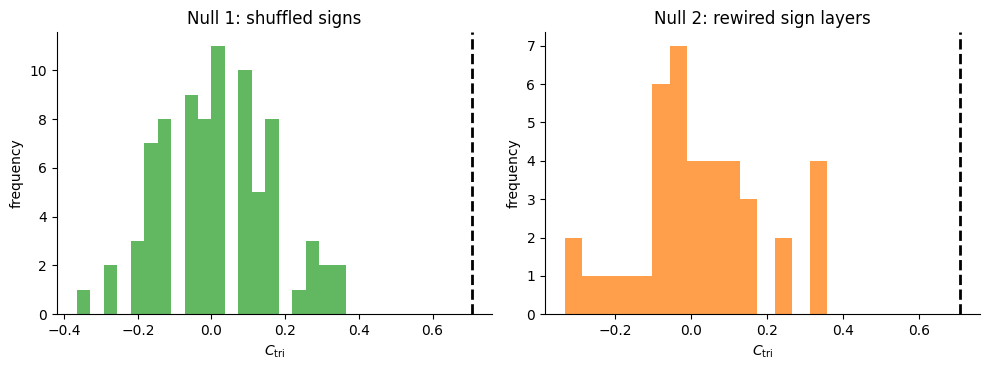

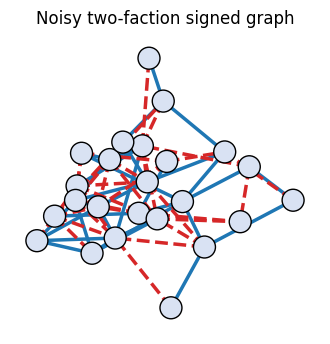

In [69]:
G_structured = make_two_faction_signed_graph(12, 12, p=0.25, p_flip=0.10, seed=SEED)
obs_ctri = triangle_index_trace(G_structured)

ctri_shuffle = []
for r in range(80):
    H = shuffle_edge_signs(G_structured, seed=SEED + r)
    ctri_shuffle.append(triangle_index_trace(H))

ctri_rewire = []
for r in range(40):
    H = signed_degree_preserving_null(G_structured, nswap=800, seed=SEED + 10 * r)
    ctri_rewire.append(triangle_index_trace(H))

mu_shuffle, sd_shuffle, z_shuffle = z_from_samples(ctri_shuffle, obs_ctri)
mu_rewire, sd_rewire, z_rewire = z_from_samples(ctri_rewire, obs_ctri)

p_shuffle = empirical_upper_tail_p(ctri_shuffle, obs_ctri)
p_rewire = empirical_upper_tail_p(ctri_rewire, obs_ctri)

signed_null_df = pd.DataFrame(
    {
        "null_model": ["shuffle signs on fixed topology", "rewire within sign layers"],
        "observed_C_tri": [obs_ctri, obs_ctri],
        "null_mean": [mu_shuffle, mu_rewire],
        "null_sd": [sd_shuffle, sd_rewire],
        "z_score": [z_shuffle, z_rewire],
        "empirical_p_upper": [p_shuffle, p_rewire],
    }
)
display(signed_null_df)

fig, axes = plt.subplots(1, 2, figsize=(10, 3.8), dpi=100)

axes[0].hist(ctri_shuffle, bins=20, color="tab:green", alpha=0.75)
axes[0].axvline(obs_ctri, linestyle="--", linewidth=2, color=REFERENCE_LINE_COLOR)
axes[0].set_xlabel(r"$C_{\mathrm{tri}}$")
axes[0].set_ylabel("frequency")
axes[0].set_title("Null 1: shuffled signs")

axes[1].hist(ctri_rewire, bins=15, color="tab:orange", alpha=0.75)
axes[1].axvline(obs_ctri, linestyle="--", linewidth=2, color=REFERENCE_LINE_COLOR)
axes[1].set_xlabel(r"$C_{\mathrm{tri}}$")
axes[1].set_ylabel("frequency")
axes[1].set_title("Null 2: rewired sign layers")

plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(4, 4), dpi=100)
draw_signed_graph(G_structured, ax=ax, title="Noisy two-faction signed graph", pos=nx.spring_layout(G_structured, seed=SEED))
plt.show()


The two null distributions are not interchangeable.

If the graph looks very balanced under sign shuffling but much less exceptional under sign-layer rewiring, that tells you the apparent balance is partly explained by heterogeneous positive and negative degree structure.

A useful further benchmark, common in more recent signed-network work, keeps the support graph fixed and preserves each node's **expected** tendency to create positive ties. On a fixed topology this can be written as an independent-edge sign model,

$$
\mathbb{P}(s_{ij}=+1)=\sigma(\theta_i+\theta_j),
\qquad
\sigma(x)=\frac{1}{1+e^{-x}},
$$

where $s_{ij}\in\{-1,+1\}$ is the edge sign, $\theta_i$ is a node-specific sign-bias parameter, and $\sigma$ is the logistic function. The parameters are fitted so that the expected positive degree of node $i$ matches the observed one. That baseline is stronger than naive sign shuffling because it respects node-level sign tendencies in expectation.

This is one place where the recent literature has become especially careful. Work such as Hao and Kovács (2024) and Gallo et al. (2024) argues that conclusions about balance can change substantially when the null model preserves more of the heterogeneous signed structure.

So the signed-graph analogue of the motif lesson from Part I is the same one again: **the null model is part of the claim.**


## 13. From local balance to global balance: the frustration index

Triangle-based balance is local. It only looks at 3-cycles.

A graph-level alternative is the **frustration index**, which asks for the best possible split of nodes into two factions. Write node labels as $x_i \in \{-1,+1\}$ and define an edge to be **satisfied** when $s_{ij} = x_i x_j$.

That means:

- positive edges want endpoints with the same label,
- negative edges want endpoints with opposite labels.

The frustration index is then

$$
L(G) = \min_{x_i \in \{-1,+1\}} \sum_{\{i,j\}\in E} \mathbb{1}[s_{ij} \ne x_i x_j].
$$

Every symbol has a job:

- the binary variable $x_i$ is the faction label of node $i$,
- the indicator $\mathbb{1}[s_{ij} \ne x_i x_j]$ is 1 exactly when edge $\{i,j\}$ is frustrated by that labeling,
- the minimum searches over all two-way labelings.

This is a natural global notion of imbalance, but it is also a hard optimization problem in general. So we start with a tiny exact brute-force solver for small graphs.


On the signed path $0\text{-}1\text{-}2\text{-}3$ with edge signs $(+,-,+)$, the assignment $x=(+1,+1,-1,-1)$ satisfies the positive edge $\{0,1\}$ and the negative edge $\{1,2\}$ but frustrates the positive edge $\{2,3\}$. If we switch to $x=(+1,+1,-1,+1)$, then $\{2,3\}$ becomes satisfied but $\{1,2\}$ becomes frustrated instead. Either way exactly one edge is frustrated, so the frustration index is $1$.


In [70]:
def frustration_index_bruteforce(G):
    """Exact frustration index by brute force over all 2^(n-1) sign assignments."""
    nodes = list(G.nodes())
    n = len(nodes)
    idx = {u: i for i, u in enumerate(nodes)}
    edges = [(u, v, d.get(SIGN, +1)) for u, v, d in G.edges(data=True)]

    best = None
    best_x = None

    # Fix the first node at +1 to remove the global sign symmetry.
    for mask in range(1 << (n - 1)):
        x = np.ones(n, dtype=int)
        for i in range(1, n):
            bit = (mask >> (i - 1)) & 1
            x[i] = +1 if bit == 0 else -1

        frustrated = 0
        for u, v, s in edges:
            if s * x[idx[u]] * x[idx[v]] < 0:
                frustrated += 1

        if best is None or frustrated < best:
            best = frustrated
            best_x = x.copy()

    assignment = {nodes[i]: int(best_x[i]) for i in range(n)}
    return int(best), assignment

Exact frustration index on the toy graph: 1
Best two-faction labeling: {0: 1, 1: 1, 2: 1, 3: -1, 4: -1, 5: 1}


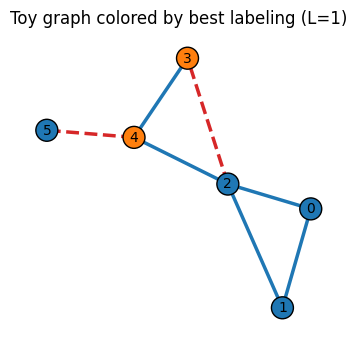

In [71]:

L_toy, x_toy = frustration_index_bruteforce(G_signed_toy)
print("Exact frustration index on the toy graph:", L_toy)
print("Best two-faction labeling:", x_toy)

toy_colors = ["tab:blue" if x_toy[u] > 0 else "tab:orange" for u in G_signed_toy.nodes()]
fig, ax = plt.subplots(figsize=(4, 4), dpi=100)
draw_signed_graph(
    G_signed_toy,
    ax=ax,
    title=f"Toy graph colored by best labeling (L={L_toy})",
    pos=nx.spring_layout(G_signed_toy, seed=SEED),
    node_colors=toy_colors,
)
plt.show()


A subtle but important scope note: the frustration index is a **two-faction** objective. It asks for the best labeling in $\{-1,+1\}$. That makes it perfectly aligned with strong balance, but not with weak balance.

A graph can be weakly balanced with three or more camps and still have positive two-faction frustration, because every forced two-way split merges at least one pair of camps that would prefer to stay separate.


Two-faction frustration on the 3-group weakly balanced graph: 4
Best +/- labeling: {0: 1, 1: 1, 2: -1, 3: -1, 4: 1, 5: 1}


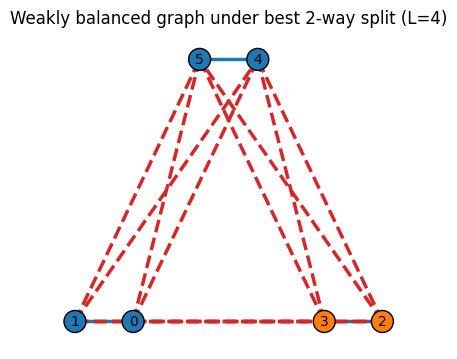

In [72]:
L_weak_two, x_weak_two = frustration_index_bruteforce(G_weak)

print("Two-faction frustration on the 3-group weakly balanced graph:", L_weak_two)
print("Best +/- labeling:", x_weak_two)

weak_two_colors = ["tab:blue" if x_weak_two[u] > 0 else "tab:orange" for u in G_weak.nodes()]
fig, ax = plt.subplots(figsize=(4.8, 4.2), dpi=100)
draw_signed_graph(
    G_weak,
    ax=ax,
    title=f"Weakly balanced graph under best 2-way split (L={L_weak_two})",
    pos=pos_weak,
    node_colors=weak_two_colors,
)
plt.show()


This is exactly why we later move to multi-way objectives. Strong balance, weak balance, frustration, signed Laplacians, and correlation clustering are related, but they are not interchangeable.


The frustration index has a clean linear-algebra connection.

For a signed adjacency matrix $A$, define the signed Laplacian

$$
L_s = D - A,
$$

where the diagonal matrix $D$ uses **absolute degrees**:

$$
D_{ii} = \sum_j |A_{ij}|.
$$

Why absolute degrees? Because then the quadratic form becomes

$$
y^\top L_s y
= \frac{1}{2}\sum_{i,j} |A_{ij}|\,\big(y_i - s_{ij}y_j\big)^2,
$$

which is always nonnegative. That makes $L_s$ positive semidefinite.

If we plug in a binary vector $x \in \{-1,+1\}^n$, each satisfied edge contributes 0 and each frustrated edge contributes 4. So

$$
x^\top L_s x
=
4 \sum_{\{i,j\}\in E} \mathbb{1}[s_{ij} \ne x_i x_j].
$$

This is the bridge between balance and spectral methods: minimizing frustration is a discrete optimization problem, and the signed Laplacian gives a natural continuous relaxation.


In [73]:
def signed_laplacian_matrix(G, normalised=False):
    """Return the signed Laplacian L_s = D - A for an undirected signed graph."""
    A, nodes = signed_adjacency_matrix(G)
    d = np.sum(np.abs(A), axis=1)
    D = np.diag(d)
    L = D - A

    if not normalised:
        return L, nodes

    with np.errstate(divide="ignore"):
        inv_sqrt = 1.0 / np.sqrt(d)
    inv_sqrt[np.isinf(inv_sqrt)] = 0.0
    D_inv_sqrt = np.diag(inv_sqrt)
    L_norm = np.eye(len(nodes)) - D_inv_sqrt @ A @ D_inv_sqrt
    return L_norm, nodes


def frustrated_edges_count(G, x):
    """Count frustrated edges under a dictionary x mapping nodes to +/-1."""
    total = 0
    for u, v, d in G.edges(data=True):
        s = d.get(SIGN, +1)
        if s * x[u] * x[v] < 0:
            total += 1
    return total

In [74]:

L_mat_toy, nodes_toy = signed_laplacian_matrix(G_signed_toy)
x_vec = np.array([x_toy[u] for u in nodes_toy], dtype=float)
quad_value = float(x_vec @ L_mat_toy @ x_vec)

print("x^T L_s x on the toy graph:", quad_value)
print("4 * frustration index     :", 4 * L_toy)


x^T L_s x on the toy graph: 4.0
4 * frustration index     : 4


A second baby-step check is to inspect the edge contributions one at a time.

For an undirected signed edge $\{i,j\}$ with sign $s_{ij}$ and a binary labeling $x$, the contribution from that edge to $x^\top L_s x$ is

$$
|A_{ij}|\big(x_i - s_{ij}x_j\big)^2.
$$

Because $x_i$ and $x_j$ are each $\pm 1$, that quantity is always either $0$ or $4$.

- It is $0$ when the edge is satisfied.
- It is $4$ when the edge is frustrated.

So the quadratic form is not mysterious: it is just counting frustrated edges, multiplied by $4$.


In [75]:
edge_rows = []
for u, v, d in G_signed_toy.edges(data=True):
    s = d.get(SIGN, +1)
    xu = x_toy[u]
    xv = x_toy[v]
    edge_term = abs(s) * (xu - s * xv) ** 2
    edge_rows.append(
        {
            "edge": (u, v),
            "sign": s,
            "x_u": xu,
            "x_v": xv,
            "satisfied?": edge_term == 0,
            "edge contribution to x^T L_s x": edge_term,
        }
    )

df_edge_terms = pd.DataFrame(edge_rows)
display(df_edge_terms)

print("Sum of one-edge contributions:", int(df_edge_terms["edge contribution to x^T L_s x"].sum()))
print("Quadratic form x^T L_s x     :", int(round(quad_value)))

,edge,sign,x_u,x_v,satisfied?,edge contribution to x^T L_s x
0,"(0, 1)",1,1,1,True,0
1,"(0, 2)",1,1,1,True,0
2,"(1, 2)",1,1,1,True,0
3,"(2, 3)",-1,1,-1,True,0
4,"(2, 4)",1,1,-1,False,4
5,"(3, 4)",1,-1,-1,True,0
6,"(4, 5)",-1,-1,1,True,0


Sum of one-edge contributions: 4
Quadratic form x^T L_s x     : 4


A second way to see why $L_s$ is the right object is to write it as a signed incidence product.

Choose an arbitrary orientation for each undirected edge $e=(u,v)$ with sign $s_{uv}$. Then define a row of a signed incidence matrix $B_s$ by placing $+1$ in column $u$ and $-s_{uv}$ in column $v$. For weighted edges one would scale by $\sqrt{|w_{uv}|}$, but our examples here are unweighted. The resulting identity

$$
L_s = B_s^\top B_s
$$

says that the signed Laplacian is built from edgewise disagreement terms $y_u - s_{uv}y_v$. Positive edges prefer agreement; negative edges prefer opposition.


In [76]:
def signed_incidence_matrix(G, nodelist=None):
    """Return a signed incidence matrix B_s with an arbitrary edge orientation."""
    if nodelist is None:
        nodelist = list(G.nodes())
    idx = {u: i for i, u in enumerate(nodelist)}

    rows = []
    edge_list = []
    for u, v, d in G.edges(data=True):
        s = int(d.get(SIGN, +1))
        row = np.zeros(len(nodelist), dtype=float)
        row[idx[u]] = 1.0
        row[idx[v]] = -float(s)
        rows.append(row)
        edge_list.append((u, v, s))

    B = np.vstack(rows) if rows else np.zeros((0, len(nodelist)))
    return B, nodelist, edge_list


In [77]:


B_signed, nodes_inc, edge_list_inc = signed_incidence_matrix(G_signed_toy)
L_from_incidence = B_signed.T @ B_signed
L_toy_signed, _ = signed_laplacian_matrix(G_signed_toy)

print("Incidence-matrix identity holds on the toy graph:",
      np.allclose(L_from_incidence, L_toy_signed))

Incidence-matrix identity holds on the toy graph: True


A note on terminology from the signed-network literature:

- the matrix used in this notebook, $L_s=D_{|A|}-A$, is often called the **opposing Laplacian** because the diagonal uses absolute degrees and the quadratic form is always nonnegative;
- another matrix, sometimes called the **repelling Laplacian**, uses net signed degrees on the diagonal instead.

The opposing Laplacian is the right choice when the goal is balance, frustration, and faction recovery. The repelling Laplacian is more naturally tied to antagonistic dynamics. They answer different questions, so it is worth naming them separately.


In [78]:
def repelling_laplacian_matrix(G):
    """Return the repelling Laplacian using net signed degrees on the diagonal."""
    A, nodes = signed_adjacency_matrix(G)
    d_net = np.sum(A, axis=1)
    L_rep = np.diag(d_net) - A
    return L_rep, nodes

In [79]:

L_opp_toy, nodes_opp = signed_laplacian_matrix(G_signed_toy)
L_rep_toy, nodes_rep = repelling_laplacian_matrix(G_signed_toy)

eig_opp = np.linalg.eigvalsh(L_opp_toy)
eig_rep = np.linalg.eigvals(L_rep_toy)

lap_compare = pd.DataFrame(
    {
        "opposing_Laplacian_eigenvalues": np.round(np.sort(eig_opp), 6),
        "repelling_Laplacian_eigenvalues_realpart": np.round(np.sort(np.real(eig_rep)), 6),
    }
)
display(lap_compare)

,opposing_Laplacian_eigenvalues,repelling_Laplacian_eigenvalues_realpart
0,0.301031,-1.544156
1,0.488947,-0.690205
2,1.592855,0.000000
3,3.000000,1.512658
4,3.082748,3.000000
5,5.534418,3.721702


That identity gives a very useful interpretation of the smallest eigenvalue and its eigenvectors.

If a connected graph is perfectly balanced, there is a binary vector $x$ with zero frustration, and therefore $L_s x = 0$. So the smallest eigenvalue is $0$.

More generally, the number of zero eigenvalues equals the number of **balanced connected components**. That is the signed analogue of the ordinary Laplacian fact that zero-eigenvalue multiplicity counts connected components, except that here an unbalanced connected component does **not** contribute a zero mode.

If the graph is only approximately balanced, the smallest-eigenvector direction is often still informative. Rounding its signs provides a practical two-faction estimate.


In [80]:
def spectral_rounding_assignment(G):
    """Round the smallest eigenvector of the signed Laplacian to +/-1 labels."""
    L, nodes = signed_laplacian_matrix(G)
    evals, evecs = np.linalg.eigh(L)
    v0 = evecs[:, 0]
    x = {nodes[i]: (+1 if v0[i] >= 0 else -1) for i in range(len(nodes))}
    return x, evals


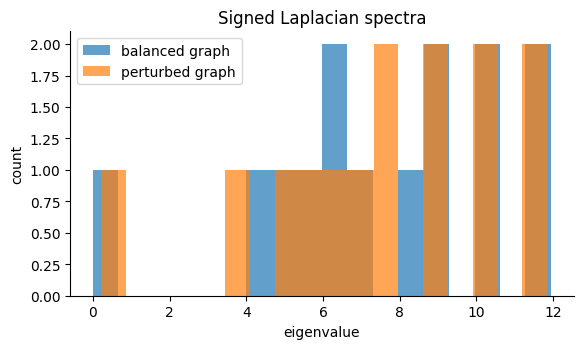

Smallest eigenvalue, balanced graph : -1.0015597949475278e-15
Smallest eigenvalue, perturbed graph: 0.21517095965376876
Balanced-graph faction recovery accuracy after sign flip correction: 1.0


In [81]:


# Compare a perfectly balanced graph and a slightly perturbed version.
G_bal_compare, true_labels = make_perfectly_balanced_two_faction_graph(7, 7, p=0.55, seed=SEED)
G_unbal_compare = G_bal_compare.copy()
u_flip, v_flip = list(G_unbal_compare.edges())[0]
G_unbal_compare[u_flip][v_flip][SIGN] *= -1

x_bal_round, evals_bal = spectral_rounding_assignment(G_bal_compare)
x_unbal_round, evals_unbal = spectral_rounding_assignment(G_unbal_compare)

fig, ax = plt.subplots(figsize=(6.5, 3.5), dpi=100)
ax.hist(evals_bal, bins=18, alpha=0.7, label="balanced graph", color=POS_EDGE_COLOR)
ax.hist(evals_unbal, bins=18, alpha=0.7, label="perturbed graph", color="tab:orange")
ax.set_xlabel("eigenvalue")
ax.set_ylabel("count")
ax.set_title("Signed Laplacian spectra")
ax.legend()
plt.show()

print("Smallest eigenvalue, balanced graph :", float(np.min(evals_bal)))
print("Smallest eigenvalue, perturbed graph:", float(np.min(evals_unbal)))

acc1 = np.mean([x_bal_round[u] == true_labels[u] for u in true_labels])
acc2 = np.mean([-x_bal_round[u] == true_labels[u] for u in true_labels])
print("Balanced-graph faction recovery accuracy after sign flip correction:", max(acc1, acc2))


For larger graphs, exact frustration is usually not practical. A common workflow is:

1. compute the smallest eigenvector of the signed Laplacian,
2. round its signs to get an initial two-faction assignment,
3. optionally refine the result with local search.

That is the signed analogue of many familiar cut-relaxation ideas from ordinary spectral graph theory.


Frustrated edges after spectral rounding : 7
Frustrated edges after local refinement  : 7


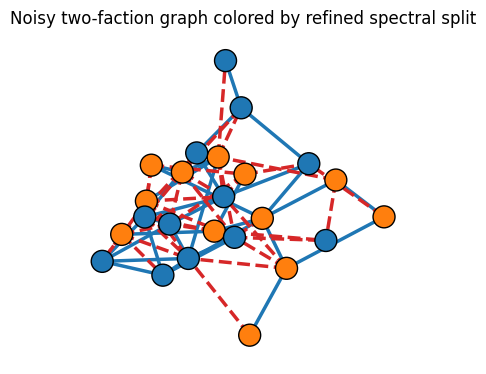

In [82]:
def greedy_local_improve(G, x0, max_sweeps=50):
    """Greedy single-node flips that reduce the number of frustrated edges."""
    x = dict(x0)
    nodes = list(G.nodes())

    improved = True
    sweep = 0
    while improved and sweep < max_sweeps:
        improved = False
        sweep += 1
        for u in nodes:
            delta = 0
            for v, d in G[u].items():
                s = d.get(SIGN, +1)
                before = 1 if s * x[u] * x[v] < 0 else 0
                after = 1 if s * (-x[u]) * x[v] < 0 else 0
                delta += after - before
            if delta < 0:
                x[u] *= -1
                improved = True
    return x


x_struct_round, _ = spectral_rounding_assignment(G_structured)
x_struct_refined = greedy_local_improve(G_structured, x_struct_round)
f_round = frustrated_edges_count(G_structured, x_struct_round)
f_refined = frustrated_edges_count(G_structured, x_struct_refined)

print("Frustrated edges after spectral rounding :", f_round)
print("Frustrated edges after local refinement  :", f_refined)

colors_round = ["tab:blue" if x_struct_refined[u] > 0 else "tab:orange" for u in G_structured.nodes()]
fig, ax = plt.subplots(figsize=(4.4, 4.4), dpi=100)
draw_signed_graph(
    G_structured,
    ax=ax,
    title="Noisy two-faction graph colored by refined spectral split",
    pos=nx.spring_layout(G_structured, seed=SEED),
    node_colors=colors_round,
)
plt.show()


### Signed distances, signed closeness, and walk-based balance

What should **distance** mean once negative edges exist?

If we treat a negative edge as a negative length, shortest-path distance stops being a distance almost immediately. A three-node chain with one negative edge and one positive edge already causes trouble: one pair can end up with a negative path length, and another pair can end up at distance zero even though the nodes are distinct.

A better move is to use a **global** distance built from the opposing Laplacian. The signed resistance distance between nodes $i$ and $j$ is

$$
d_{\mathrm{res}}(i,j)
=
\sqrt{(L_s^\dagger)_{ii} + (L_s^\dagger)_{jj} - 2(L_s^\dagger)_{ij}},
$$

where $L_s^\dagger$ is the Moore-Penrose pseudoinverse of the opposing Laplacian $L_s$.

Why this form? In ordinary graphs the same formula gives effective resistance. In signed graphs it still behaves like a genuine metric because the positive-semidefinite opposing Laplacian is doing the hard work.

Once we have a distance, a signed version of closeness is immediate:

$$
C_{\mathrm{close}}(i)
=
\left(\sum_{j \neq i} d_{\mathrm{res}}(i,j)\right)^{-1}.
$$

That gives us a nice contrast with signed Katz centrality. Katz counts signed walks. Resistance closeness asks whether the rest of the network is globally near once positive and negative ties are both taken seriously.


In [83]:
def signed_resistance_distance_matrix(G):
    """Return the signed resistance distance matrix from the opposing Laplacian."""
    L, nodes = signed_laplacian_matrix(G)
    L_pinv = np.linalg.pinv(L)
    diag = np.diag(L_pinv)
    R = diag[:, None] + diag[None, :] - 2.0 * L_pinv
    R = np.maximum(R, 0.0)
    D = np.sqrt(R)
    return D, nodes


def signed_resistance_closeness(G):
    """Resistance-based closeness centrality for a signed graph."""
    D, nodes = signed_resistance_distance_matrix(G)
    closeness = {}
    for i, u in enumerate(nodes):
        denom = float(np.sum(D[i]) - D[i, i])
        closeness[u] = 0.0 if denom == 0 else 1.0 / denom
    return closeness



In [84]:

D_res_toy, nodes_res_toy = signed_resistance_distance_matrix(G_signed_toy)
closeness_res_toy = signed_resistance_closeness(G_signed_toy)

centrality_compare = pd.DataFrame(
    {
        "node": nodes_res_toy,
        "net_degree": [k_net[u] for u in nodes_res_toy],
        "signed_Katz": [float(df_katz.loc[u, "katz_signed"]) for u in nodes_res_toy],
        "resistance_closeness": [closeness_res_toy[u] for u in nodes_res_toy],
    }
).round(3)
display(centrality_compare)


,node,net_degree,signed_Katz,resistance_closeness
0,0,2,2.493,0.155
1,1,2,2.493,0.155
2,2,2,2.740,0.173
3,3,0,0.749,0.135
4,4,1,1.862,0.152
5,5,-1,0.469,0.108


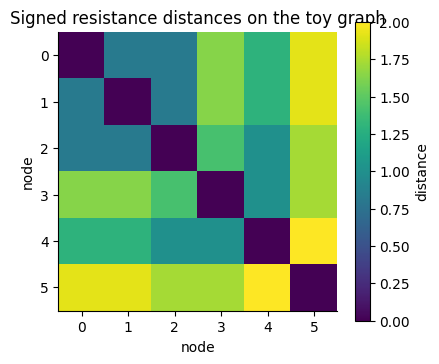

In [85]:

fig, ax = plt.subplots(figsize=(4.4, 3.8), dpi=100)
im = ax.imshow(D_res_toy, cmap="viridis")
ax.set_xticks(range(len(nodes_res_toy)))
ax.set_xticklabels(nodes_res_toy)
ax.set_yticks(range(len(nodes_res_toy)))
ax.set_yticklabels(nodes_res_toy)
ax.set_xlabel("node")
ax.set_ylabel("node")
ax.set_title("Signed resistance distances on the toy graph")
plt.colorbar(im, ax=ax, label="distance")
plt.tight_layout()
plt.show()


The heatmap is a good reminder that signed distance is not just shortest-path length with a minus sign glued on.

Nodes can be close because many compatible routes reinforce one another, and farther apart when the network keeps sending mixed signals. The table makes the centrality point concrete too: net degree, Katz, and resistance closeness are not redundant. One is purely local. One sums signed walks. One is built from a global metric.


A second matrix-based balance summary uses **closed walks** rather than just triangles.

If longer walks are down-weighted by the factorial penalty $1/k!$, a standard walk-based balance score is

$$
\kappa_\beta(G)
=
\frac{\mathrm{tr}(e^{\beta A})}{\mathrm{tr}(e^{\beta |A|})},
$$

where $\beta > 0$ controls how much long walks matter. Balanced graphs have $\kappa_\beta=1$. As imbalance grows, positive and negative closed walks stop reinforcing one another and the ratio drops.

This is a nice companion to the triangle index. The triangle index is sharply local. The walk index lets longer closed walks vote too.


In [86]:
def triangle_balance_index(G):
    """Signed triangle balance index tr(A^3) / tr(|A|^3)."""
    A, _ = signed_adjacency_matrix(G)
    A_abs = np.abs(A)
    denom = float(np.trace(A_abs @ A_abs @ A_abs))
    if denom == 0:
        return np.nan
    return float(np.trace(A @ A @ A) / denom)


def walk_balance_index(G, beta=1.0):
    """Estrada-Benzi style walk-balance index tr(exp(beta A)) / tr(exp(beta |A|))."""
    A, _ = signed_adjacency_matrix(G)
    A_abs = np.abs(A)
    num = float(np.real(np.trace(expm(beta * A))))
    den = float(np.real(np.trace(expm(beta * A_abs))))
    return np.nan if den == 0 else num / den


In [87]:
G_walk_balanced = G_bal_compare
G_walk_noisy = G_unbal_compare
G_walk_shuffle = shuffle_edge_signs(G_bal_compare, seed=SEED + 99)

balance_rows = []
for name, G_case in [
    ("balanced", G_walk_balanced),
    ("one sign flip", G_walk_noisy),
    ("sign-shuffled", G_walk_shuffle),
]:
    L_exact, _ = frustration_index_bruteforce(G_case)
    balance_rows.append(
        {
            "case": name,
            "triangle_index": triangle_balance_index(G_case),
            "walk_index_beta=1": walk_balance_index(G_case, beta=1.0),
            "frustration_index": L_exact,
        }
    )

balance_df = pd.DataFrame(balance_rows).round(3)
display(balance_df)


,case,triangle_index,walk_index_beta=1,frustration_index
0,balanced,1.000,1.000,0
1,one sign flip,1.000,0.889,1
2,sign-shuffled,0.033,0.099,12


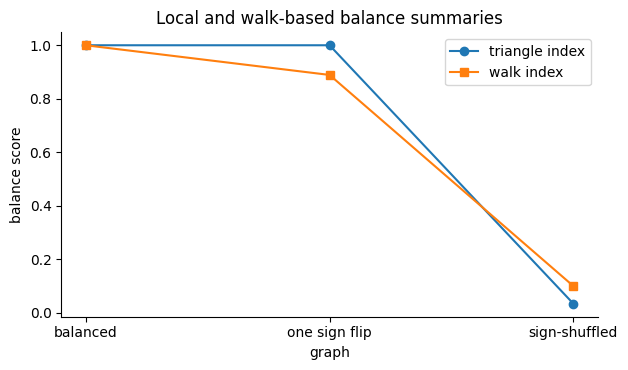

In [88]:



fig, ax = plt.subplots(figsize=(6.4, 3.8), dpi=100)
ax.plot(balance_df["case"], balance_df["triangle_index"], marker="o", label="triangle index")
ax.plot(balance_df["case"], balance_df["walk_index_beta=1"], marker="s", label="walk index")
ax.set_xlabel("graph")
ax.set_ylabel("balance score")
ax.set_title("Local and walk-based balance summaries")
ax.legend()
plt.tight_layout()
plt.show()


The useful distinction is local versus global again.

The triangle index only sees 3-cycles. The walk index lets longer closed walks vote too. On easy cases they usually agree. On graphs where the trouble lives in longer loops, they can part ways, and that disagreement is informative rather than annoying.


## 14. Signed community, node embeddings, and faction structure

Earlier in the course, communities were mostly about **dense internal connectivity**.

Signed data changes the target. A good signed partition should usually make

- positive edges mostly internal,
- negative edges mostly external.

For two groups, this is exactly the same logic as frustration minimization. For more than two groups, it leads naturally to signed stochastic block models, signed clustering objectives, node embeddings, and correlation-clustering viewpoints.

We will use a simple signed SBM as a controlled playground.


In [89]:
def make_signed_sbm(group_sizes, p_pos_in=0.25, p_neg_in=0.03, p_pos_out=0.03, p_neg_out=0.20, seed=SEED):
    """Generate an undirected signed stochastic block model."""
    rng_local = np.random.default_rng(seed)

    labels = {}
    node = 0
    for g, size in enumerate(group_sizes):
        for _ in range(size):
            labels[node] = g
            node += 1

    G = nx.Graph()
    G.add_nodes_from(labels.keys())

    for i, j in combinations(G.nodes(), 2):
        same = labels[i] == labels[j]
        r = rng_local.random()
        if same:
            if r < p_pos_in:
                G.add_edge(i, j, **{SIGN: +1})
            elif r < p_pos_in + p_neg_in:
                G.add_edge(i, j, **{SIGN: -1})
        else:
            if r < p_pos_out:
                G.add_edge(i, j, **{SIGN: +1})
            elif r < p_pos_out + p_neg_out:
                G.add_edge(i, j, **{SIGN: -1})

    return G, labels


Signed SBM nodes: 36
Signed SBM edges: 147
Two-faction recovery accuracy (up to global sign): 0.972


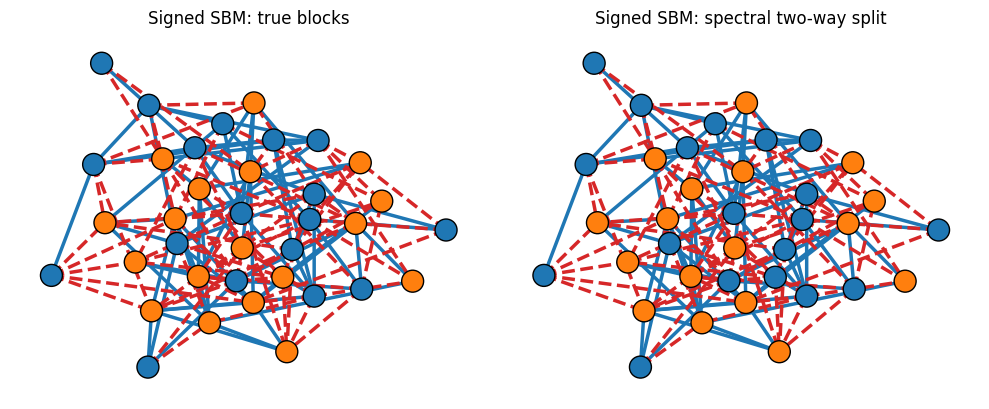

In [90]:
G_sbm, labels_sbm = make_signed_sbm(
    [18, 18],
    p_pos_in=0.24,
    p_neg_in=0.03,
    p_pos_out=0.03,
    p_neg_out=0.22,
    seed=SEED,
)

L_sbm, nodes_sbm = signed_laplacian_matrix(G_sbm)
evals_sbm, evecs_sbm = np.linalg.eigh(L_sbm)
v0 = evecs_sbm[:, 0]
pred_labels = {nodes_sbm[i]: (+1 if v0[i] >= 0 else -1) for i in range(len(nodes_sbm))}

true_pm = {u: (+1 if labels_sbm[u] == 0 else -1) for u in labels_sbm}
acc_raw = np.mean([pred_labels[u] == true_pm[u] for u in true_pm])
acc_flip = np.mean([-pred_labels[u] == true_pm[u] for u in true_pm])
acc_best = max(acc_raw, acc_flip)

print("Signed SBM nodes:", G_sbm.number_of_nodes())
print("Signed SBM edges:", G_sbm.number_of_edges())
print("Two-faction recovery accuracy (up to global sign):", round(acc_best, 3))

pos_sbm = nx.spring_layout(G_sbm, seed=SEED)
colors_true = ["tab:blue" if true_pm[u] > 0 else "tab:orange" for u in G_sbm.nodes()]
if acc_flip > acc_raw:
    pred_labels = {u: -pred_labels[u] for u in pred_labels}
colors_pred = ["tab:blue" if pred_labels[u] > 0 else "tab:orange" for u in G_sbm.nodes()]

fig, axes = plt.subplots(1, 2, figsize=(10, 4.2), dpi=100)
draw_signed_graph(G_sbm, ax=axes[0], title="Signed SBM: true blocks", pos=pos_sbm, node_colors=colors_true)
draw_signed_graph(G_sbm, ax=axes[1], title="Signed SBM: spectral two-way split", pos=pos_sbm, node_colors=colors_pred)
plt.tight_layout()
plt.show()


The signed SBM example connects several course themes at once.

- It is a **generative model**, so we know what structure was planted.
- It gives us a controlled place to test whether a method recovers that structure.
- It shows how signed Laplacian methods relate back to earlier community-detection ideas while changing the objective from "dense within" to "positive within, negative across."

This is also a good place to be honest about limitations. Not every signed graph is well described by two factions. Not every sign pattern comes from balance. And not every signed community method agrees on the right objective.


### Multi-way signed spectral methods

The smallest eigenvector of the signed Laplacian is a natural tool when the picture is close to **two factions**. But some signed graphs are better described by **three or more camps**.

A useful way to organize that situation is to split the signed adjacency matrix into positive and negative parts:

$$
A = A^+ - A^-,
\qquad
L^+ = D^+ - A^+,
\qquad
Q^- = D^- + A^-.
$$

Here:

- $A^+$ is the positive layer,
- $A^-$ is the negative layer,
- $D^+$ and $D^-$ are the corresponding diagonal degree matrices,
- $L^+$ is the ordinary Laplacian of the positive layer,
- $Q^-$ is the signless Laplacian of the negative layer.

The logic is intuitive.

- Positive edges should encourage nearby embedding coordinates, so they appear in a Laplacian term.
- Negative edges should discourage same-cluster assignments, so they appear in a signless-Laplacian term.

One regularized generalized-eigenvalue construction used in the literature is the SPONGE embedding:

$$
\big(L^+ + \tau^- D^-\big)x
= \lambda\,\big(Q^- + \tau^+ D^+\big)x.
$$

The regularization constants $\tau^+$ and $\tau^-$ keep the problem numerically stable and prevent isolated or low-degree nodes from dominating the embedding. In the code below, the left matrix is `M_left` and the right matrix is `M_right`.


For the 30- to 100-node examples in this notebook, dense linear algebra is still fine. Once the graph is genuinely sparse and large, do not compute a full dense spectrum just to keep a few extremal directions. Use sparse solvers such as `scipy.sparse.linalg.eigsh` and keep only the eigenpairs you actually need.


In [91]:
def split_signed_adjacency(G):
    """Return positive and negative adjacency matrices for an undirected signed graph."""
    A, nodes = signed_adjacency_matrix(G)
    A_pos = np.maximum(A, 0)
    A_neg = np.maximum(-A, 0)
    return A_pos, A_neg, nodes


def symmetric_inverse_sqrt(M, eps=1e-10):
    """Return a stable inverse square root for a symmetric positive semidefinite matrix."""
    evals, evecs = np.linalg.eigh(M)
    evals = np.maximum(evals, eps)
    return evecs @ np.diag(1.0 / np.sqrt(evals)) @ evecs.T


def signed_laplacian_embedding(G, k):
    """Use the k smallest eigenvectors of the signed Laplacian as an embedding."""
    L, nodes = signed_laplacian_matrix(G)
    n = len(nodes)

    if n > max(2 * k + 1, 20):
        evals, evecs = eigsh(csr_matrix(L), k=k, which="SM")
        order = np.argsort(evals)
        evals = np.asarray(evals)[order]
        evecs = np.asarray(evecs)[:, order]
        return evecs, nodes, evals

    evals, evecs = np.linalg.eigh(L)
    return evecs[:, :k], nodes, evals[:k]


def sponge_embedding_teaching(G, k, tau_plus=1.0, tau_minus=1.0, eps=1e-8):
    """Teaching-scale SPONGE-style embedding via a regularized symmetric reduction."""
    A_pos, A_neg, nodes = split_signed_adjacency(G)
    d_pos = A_pos.sum(axis=1)
    d_neg = A_neg.sum(axis=1)
    D_pos = np.diag(d_pos)
    D_neg = np.diag(d_neg)

    L_pos = D_pos - A_pos
    Q_neg = D_neg + A_neg

    M_left = L_pos + tau_minus * D_neg + eps * np.eye(len(nodes))
    M_right = Q_neg + tau_plus * D_pos + eps * np.eye(len(nodes))

    M_right_inv_sqrt = symmetric_inverse_sqrt(M_right, eps=eps)
    S = M_right_inv_sqrt @ M_left @ M_right_inv_sqrt
    evals, evecs = np.linalg.eigh(S)
    Z = M_right_inv_sqrt @ evecs[:, :k]
    return Z, nodes, evals[:k]


def kmeans_on_embedding(Z, k, seed=SEED):
    """Cluster rows of an embedding after row normalization."""
    norms = np.linalg.norm(Z, axis=1, keepdims=True)
    norms[norms == 0] = 1.0
    Z_norm = Z / norms
    km = KMeans(n_clusters=k, n_init=25, random_state=seed)
    return km.fit_predict(Z_norm)


,method,ARI against planted labels,smallest retained eigenvalues
0,3-way signed-Laplacian embedding,0.915415,"[2.1499, 2.6563, 2.7175]"
1,3-way SPONGE-style embedding,0.047494,"[0.3449, 0.5806, 0.5895]"


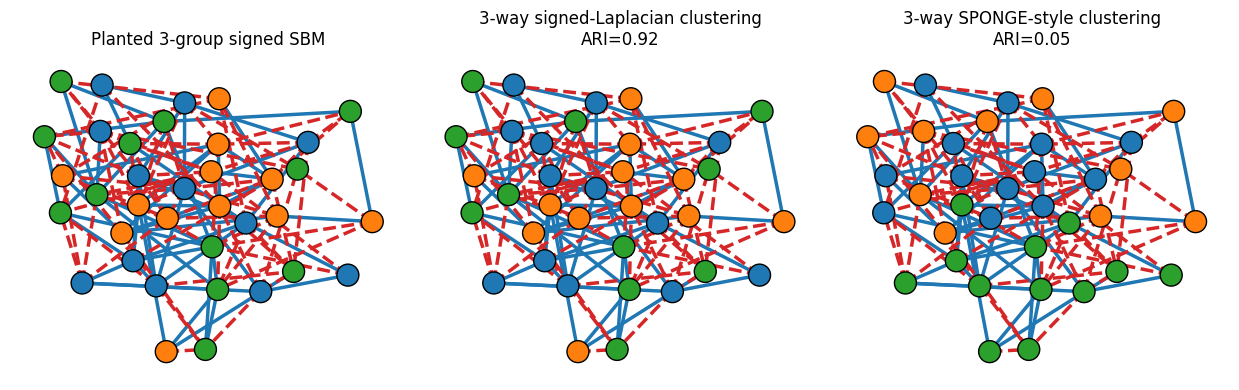

In [92]:
G_sbm3, labels_sbm3 = make_signed_sbm(
    [12, 12, 12],
    p_pos_in=0.24,
    p_neg_in=0.02,
    p_pos_out=0.02,
    p_neg_out=0.18,
    seed=SEED + 2,
)

Z_ls, nodes_sbm3, evals_ls = signed_laplacian_embedding(G_sbm3, 3)
pred_ls = kmeans_on_embedding(Z_ls, 3, seed=SEED)

Z_sp, nodes_sbm3_sp, evals_sp = sponge_embedding_teaching(G_sbm3, 3)
pred_sp = kmeans_on_embedding(Z_sp, 3, seed=SEED)

assert nodes_sbm3 == nodes_sbm3_sp
true_arr = np.array([labels_sbm3[u] for u in nodes_sbm3])
ari_ls = adjusted_rand_score(true_arr, pred_ls)
ari_sp = adjusted_rand_score(true_arr, pred_sp)

comparison_multi = pd.DataFrame(
    {
        "method": ["3-way signed-Laplacian embedding", "3-way SPONGE-style embedding"],
        "ARI against planted labels": [ari_ls, ari_sp],
        "smallest retained eigenvalues": [np.round(evals_ls, 4), np.round(evals_sp, 4)],
    }
)
display(comparison_multi)

palette = ["tab:blue", "tab:orange", "tab:green", "tab:red", "tab:purple", "tab:brown"]

def colors_from_label_dict(label_dict, nodes):
    """Map integer cluster labels to a reusable categorical color palette."""
    return [palette[int(label_dict[u]) % len(palette)] for u in nodes]

ls_labels = {nodes_sbm3[i]: int(pred_ls[i]) for i in range(len(nodes_sbm3))}
sp_labels = {nodes_sbm3[i]: int(pred_sp[i]) for i in range(len(nodes_sbm3))}

pos_sbm3 = nx.spring_layout(G_sbm3, seed=SEED)
fig, axes = plt.subplots(1, 3, figsize=(12.5, 4.0), dpi=100)
draw_signed_graph(
    G_sbm3,
    ax=axes[0],
    title="Planted 3-group signed SBM",
    pos=pos_sbm3,
    node_colors=colors_from_label_dict(labels_sbm3, list(G_sbm3.nodes())),
)
draw_signed_graph(
    G_sbm3,
    ax=axes[1],
    title=f"3-way signed-Laplacian clustering\nARI={ari_ls:.2f}",
    pos=pos_sbm3,
    node_colors=colors_from_label_dict(ls_labels, list(G_sbm3.nodes())),
)
draw_signed_graph(
    G_sbm3,
    ax=axes[2],
    title=f"3-way SPONGE-style clustering\nARI={ari_sp:.2f}",
    pos=pos_sbm3,
    node_colors=colors_from_label_dict(sp_labels, list(G_sbm3.nodes())),
)
plt.tight_layout()
plt.show()


The network drawings above show the graph in a spring layout, not in the coordinates used by the clustering methods themselves. Those are different pictures. The next figure plots the first two coordinates of each embedding, colored by the planted group labels.

This is often the cleaner diagnostic when a clustering result is surprising: before asking whether KMeans worked, ask whether the embedding geometry separated the groups at all.

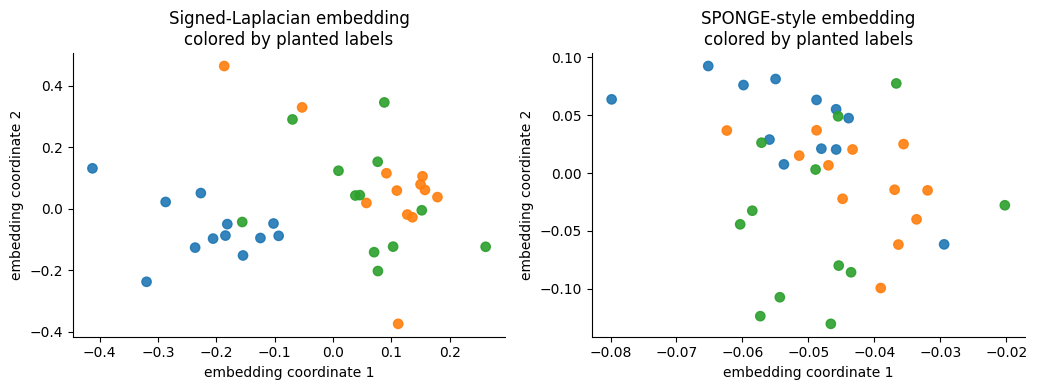

In [93]:
true_colors_sbm3 = [palette[int(labels_sbm3[u]) % len(palette)] for u in nodes_sbm3]

fig, axes = plt.subplots(1, 2, figsize=(10.5, 4.0), dpi=100)

axes[0].scatter(Z_ls[:, 0], Z_ls[:, 1], c=true_colors_sbm3, s=45, alpha=0.9)
axes[0].set_xlabel("embedding coordinate 1")
axes[0].set_ylabel("embedding coordinate 2")
axes[0].set_title("Signed-Laplacian embedding\ncolored by planted labels")

axes[1].scatter(Z_sp[:, 0], Z_sp[:, 1], c=true_colors_sbm3, s=45, alpha=0.9)
axes[1].set_xlabel("embedding coordinate 1")
axes[1].set_ylabel("embedding coordinate 2")
axes[1].set_title("SPONGE-style embedding\ncolored by planted labels")

plt.tight_layout()
plt.show()

A clean cluster picture in the embedding is what makes the downstream partition easy. If the colored clouds overlap heavily, no relabeling trick can fully rescue the result. That is why spectral methods should be interpreted at the level of the embedding, not only at the level of the final hard labels.

The new quantity in the table is the **adjusted Rand index** (ARI).

- ARI $=1$ means perfect recovery of the planted partition.
- ARI near $0$ means the clustering is no better than a chance relabeling.

So this experiment is a clean teaching example of a broader message from the signed-network review literature: once signed structure is not just a two-faction problem, the exact spectral objective starts to matter.


### Another objective: correlation clustering

Sometimes the number of groups is not known in advance, and sometimes the right question is not spectral at all.

A very direct objective is to minimize **disagreements**:

$$
\mathrm{disagree}(\mathcal C)
=
\#\{\text{positive edges across clusters}\}
+
\#\{\text{negative edges within clusters}\}.
$$

Every term has a plain-language reading.

- A positive edge is a disagreement if the partition cuts it.
- A negative edge is a disagreement if the partition keeps it inside one block.

This is the signed-network version of saying: keep friends together and enemies apart. The optimization problem is hard in general, so we use a small teaching heuristic rather than an exact solver.


In [94]:
def signed_disagreements(G, labels):
    """Count positive-across plus negative-within disagreements for a partition."""
    total = 0
    for u, v, d in G.edges(data=True):
        same = labels[u] == labels[v]
        s = d.get(SIGN, +1)
        if (s > 0 and not same) or (s < 0 and same):
            total += 1
    return total


def correlation_clustering_pivot(G, seed=SEED):
    """Randomized pivot-style heuristic for sparse signed graphs.

    Positive neighbors of the pivot join its cluster. Negative edges and
    missing edges are treated as reasons not to join.
    """
    rng_local = np.random.default_rng(seed)
    unassigned = set(G.nodes())
    labels = {}
    cluster_id = 0

    while unassigned:
        pivot = rng_local.choice(list(unassigned))
        labels[pivot] = cluster_id
        joiners = []
        for v in list(unassigned):
            if v == pivot:
                continue
            if G.has_edge(pivot, v) and G[pivot][v].get(SIGN, +1) > 0:
                joiners.append(v)
        for v in joiners:
            labels[v] = cluster_id
        unassigned.remove(pivot)
        for v in joiners:
            unassigned.discard(v)
        cluster_id += 1

    return labels


def best_pivot_partition(G, n_restarts=40, seed=SEED):
    """Return the best pivot partition found across several random restarts."""
    best_labels = None
    best_bad = None
    for r in range(n_restarts):
        labels = correlation_clustering_pivot(G, seed=seed + r)
        bad = signed_disagreements(G, labels)
        if best_bad is None or bad < best_bad:
            best_bad = bad
            best_labels = labels
    return best_labels, best_bad


labels_true3 = {u: labels_sbm3[u] for u in G_sbm3.nodes()}
labels_ls3 = {nodes_sbm3[i]: int(pred_ls[i]) for i in range(len(nodes_sbm3))}
labels_sp3 = {nodes_sbm3[i]: int(pred_sp[i]) for i in range(len(nodes_sbm3))}
labels_pivot3, bad_pivot3 = best_pivot_partition(G_sbm3, n_restarts=50, seed=SEED)

comparison_cc = pd.DataFrame(
    {
        "partition": [
            "planted labels",
            "3-way signed-Laplacian clustering",
            "3-way SPONGE-style clustering",
            "pivot correlation-clustering heuristic",
        ],
        "number of groups": [
            len(set(labels_true3.values())),
            len(set(labels_ls3.values())),
            len(set(labels_sp3.values())),
            len(set(labels_pivot3.values())),
        ],
        "disagreements": [
            signed_disagreements(G_sbm3, labels_true3),
            signed_disagreements(G_sbm3, labels_ls3),
            signed_disagreements(G_sbm3, labels_sp3),
            bad_pivot3,
        ],
        "ARI against planted labels": [
            1.0,
            adjusted_rand_score(true_arr, pred_ls),
            adjusted_rand_score(true_arr, pred_sp),
            adjusted_rand_score(true_arr, [labels_pivot3[u] for u in nodes_sbm3]),
        ],
    }
)
display(comparison_cc)


,partition,number of groups,disagreements,ARI against planted labels
0,planted labels,3,13,1.000000
1,3-way signed-Laplacian clustering,3,13,0.915415
2,3-way SPONGE-style clustering,3,55,0.047494
3,pivot correlation-clustering heuristic,15,31,0.273821


This comparison is useful because it separates two different ideas.

- The spectral methods are told in advance to look for **three groups**.
- The pivot heuristic is free to return **however many groups** it wants.

So disagreement minimization and spectral recovery are related, but they are not the same task. That distinction matters in real signed data, where the number of camps is often part of the question rather than part of the input.


### Two nearby directions worth keeping in view

The main lecture path emphasized undirected signed structure because it is the cleanest continuation of motif thinking. Two nearby extensions are also important.

First, **directed** signed networks are often better explained by **status theory** than by balance. In that setting, a positive edge and a negative edge do not just encode agreement versus conflict; together with direction they encode a ranking hypothesis. Appendix C works through that transform explicitly.

Second, the same local signed patterns can be turned into features for **sign prediction**. Appendix D shows this in a lightweight supervised example: the motif instinct from Part I becomes a predictive feature-engineering recipe in Part II.


### One more downstream task: sign prediction

Community detection is not the only downstream job. Another common task is **sign prediction**: infer whether an existing edge, or a candidate edge, should be positive or negative from the signed structure around it.

The local version uses signed triads, common neighbors, and short motifs. The global version uses faction structure, walk-based scores, or embeddings. Appendix D builds a small teaching-scale version of both ideas and shows where the extra global signal helps.


## 15. Dynamics on, of, and with signed networks

Static signed structure is only half the story.

Sometimes the edges stay fixed and node states move on top of them. That is **dynamics on** a signed network. Opinion models are the standard example.

Sometimes the nodes stay put and the signs themselves change. That is **dynamics of** the network. Balance models live here.

And sometimes both layers move together: opinions change, ties change, and the two keep reacting to each other. That is **dynamics with** the network.

We will keep everything toy-sized. The point is not to build the last word on signed dynamics. The point is to see how negative edges change the qualitative behavior.


### On: Altafini-style signed consensus

A standard signed consensus model is

$$
\dot{x}(t) = -L_s x(t),
$$

where $x_i(t)$ is node $i$'s opinion at time $t$ and $L_s$ is the opposing Laplacian.

Why does this form make sense? The Laplacian already computes a signed mismatch between a node and its neighbors. Putting a minus sign in front makes the dynamics relax that mismatch.

Balanced graphs usually polarize into two opposite camps. Unbalanced graphs instead collapse toward zero.


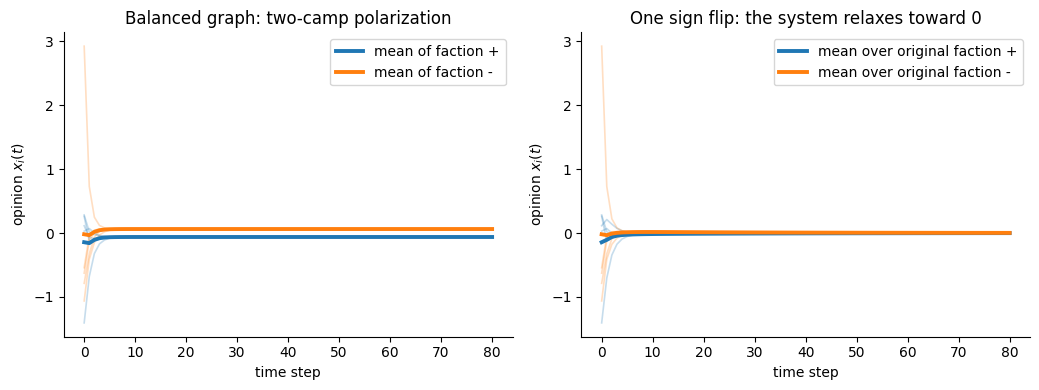

In [95]:
def euler_signed_consensus(G, x0, dt=0.10, steps=80):
    """Forward-Euler simulation of dx/dt = -L_s x."""
    L, nodes = signed_laplacian_matrix(G)
    x = np.array([x0[u] for u in nodes], dtype=float)
    traj = [x.copy()]
    for _ in range(steps):
        x = x - dt * (L @ x)
        traj.append(x.copy())
    return np.asarray(traj), nodes


G_dyn_bal, labels_dyn = make_perfectly_balanced_two_faction_graph(5, 5, p=0.50, seed=SEED + 200)
G_dyn_unbal = G_dyn_bal.copy()
u_flip_dyn, v_flip_dyn = list(G_dyn_unbal.edges())[0]
G_dyn_unbal[u_flip_dyn][v_flip_dyn][SIGN] *= -1

x0_dyn = {u: rng.normal() for u in G_dyn_bal.nodes()}
traj_bal, nodes_bal_dyn = euler_signed_consensus(G_dyn_bal, x0_dyn)
traj_unbal, nodes_unbal_dyn = euler_signed_consensus(G_dyn_unbal, x0_dyn)

idx_pos = [i for i, u in enumerate(nodes_bal_dyn) if labels_dyn[u] > 0]
idx_neg = [i for i, u in enumerate(nodes_bal_dyn) if labels_dyn[u] < 0]

fig, axes = plt.subplots(1, 2, figsize=(10.5, 4.0), dpi=100)

for i, u in enumerate(nodes_bal_dyn):
    color = POS_EDGE_COLOR if labels_dyn[u] > 0 else "tab:orange"
    axes[0].plot(traj_bal[:, i], color=color, alpha=0.25, linewidth=1.2)
axes[0].plot(traj_bal[:, idx_pos].mean(axis=1), color=POS_EDGE_COLOR, linewidth=2.8, label="mean of faction +")
axes[0].plot(traj_bal[:, idx_neg].mean(axis=1), color="tab:orange", linewidth=2.8, label="mean of faction -")
axes[0].set_xlabel("time step")
axes[0].set_ylabel("opinion $x_i(t)$")
axes[0].set_title("Balanced graph: two-camp polarization")
axes[0].legend()

for i, u in enumerate(nodes_unbal_dyn):
    color = POS_EDGE_COLOR if labels_dyn[u] > 0 else "tab:orange"
    axes[1].plot(traj_unbal[:, i], color=color, alpha=0.25, linewidth=1.2)
axes[1].plot(traj_unbal[:, idx_pos].mean(axis=1), color=POS_EDGE_COLOR, linewidth=2.8, label="mean over original faction +")
axes[1].plot(traj_unbal[:, idx_neg].mean(axis=1), color="tab:orange", linewidth=2.8, label="mean over original faction -")
axes[1].set_xlabel("time step")
axes[1].set_ylabel("opinion $x_i(t)$")
axes[1].set_title("One sign flip: the system relaxes toward 0")
axes[1].legend()

plt.tight_layout()
plt.show()


The balanced case does exactly what the theory says: the two camps settle to equal-and-opposite opinions.

After one sign flip, the same initial condition no longer has a perfectly compatible global split, and the dynamics relax toward zero instead. Other signed opinion models keep the same moral but change the mechanism. Voter models copy or oppose neighbors. Contagion models can flip, suppress, or redirect what is transmitted.


### Of: local balance updates on the edge signs

Now keep the nodes fixed and let the **signs** evolve.

The simplest balance toy model picks an unbalanced triangle and flips one of its edges. We will use a greedy version: among the three possible flips, choose one that reduces the **total** number of unbalanced triangles as much as possible.

That is not meant as literal sociology. It is just a clean way to see what balance-seeking edge dynamics are trying to do.


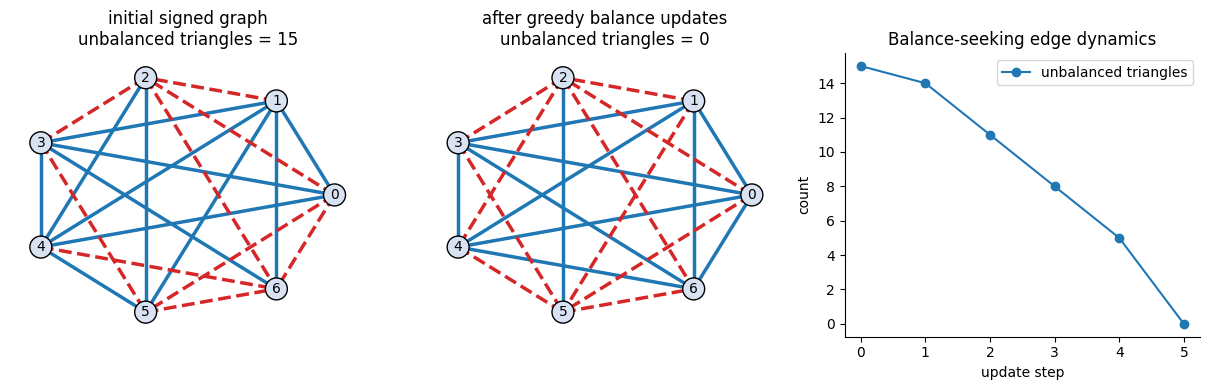

In [96]:
def random_complete_signed_graph(n, p_neg=0.35, seed=SEED):
    """Complete signed graph with independently sampled edge signs."""
    rng_local = np.random.default_rng(seed)
    G = nx.complete_graph(n)
    for u, v in G.edges():
        G[u][v][SIGN] = -1 if rng_local.random() < p_neg else +1
    return G


def unbalanced_triangles(G):
    """List all unbalanced triangles in a signed graph."""
    bad = []
    for tri in combinations(G.nodes(), 3):
        if G.has_edge(tri[0], tri[1]) and G.has_edge(tri[0], tri[2]) and G.has_edge(tri[1], tri[2]):
            prod = (
                G[tri[0]][tri[1]][SIGN]
                * G[tri[0]][tri[2]][SIGN]
                * G[tri[1]][tri[2]][SIGN]
            )
            if prod < 0:
                bad.append(tri)
    return bad


def greedy_balance_edge_flip_step(G, rng_local=None):
    """Flip one edge inside a random unbalanced triangle to reduce total imbalance."""
    if rng_local is None:
        rng_local = np.random.default_rng(SEED)

    bad = unbalanced_triangles(G)
    if not bad:
        return False

    tri = bad[int(rng_local.integers(len(bad)))]
    tri_edges = list(combinations(tri, 2))

    best_edges = []
    best_score = None
    for u, v in tri_edges:
        H = G.copy()
        H[u][v][SIGN] *= -1
        score = len(unbalanced_triangles(H))
        if best_score is None or score < best_score:
            best_score = score
            best_edges = [(u, v)]
        elif score == best_score:
            best_edges.append((u, v))

    u, v = best_edges[int(rng_local.integers(len(best_edges)))]
    G[u][v][SIGN] *= -1
    return True


def run_balance_edge_dynamics(G, steps=60, seed=SEED):
    """Run greedy balance-seeking sign updates and record imbalance over time."""
    H = G.copy()
    rng_local = np.random.default_rng(seed)
    history = [len(unbalanced_triangles(H))]
    for _ in range(steps):
        changed = greedy_balance_edge_flip_step(H, rng_local)
        history.append(len(unbalanced_triangles(H)))
        if not changed or history[-1] == 0:
            break
    return H, history


G_tri_start = random_complete_signed_graph(7, p_neg=0.42, seed=SEED + 300)
G_tri_end, hist_tri = run_balance_edge_dynamics(G_tri_start, steps=80, seed=SEED + 301)

pos_tri = nx.circular_layout(G_tri_start)
fig, axes = plt.subplots(1, 3, figsize=(12.2, 4.0), dpi=100)

draw_signed_graph(
    G_tri_start,
    ax=axes[0],
    title=f"initial signed graph\nunbalanced triangles = {len(unbalanced_triangles(G_tri_start))}",
    pos=pos_tri,
)
draw_signed_graph(
    G_tri_end,
    ax=axes[1],
    title=f"after greedy balance updates\nunbalanced triangles = {len(unbalanced_triangles(G_tri_end))}",
    pos=pos_tri,
)
axes[2].plot(range(len(hist_tri)), hist_tri, marker="o", label="unbalanced triangles")
axes[2].set_xlabel("update step")
axes[2].set_ylabel("count")
axes[2].set_title("Balance-seeking edge dynamics")
axes[2].legend()

plt.tight_layout()
plt.show()


The line usually drops fast, but that is partly because we chose a greedy rule.

Real social dynamics need not be monotone, and they are certainly not driven by balance alone. Still, the toy model makes one useful point visible: changing signs locally can reorganize the whole graph.


### With: coevolution of opinions and signs

Now let both layers move.

We will call an edge **satisfied** when a positive edge connects equal opinions or a negative edge connects opposite opinions. Then we repeatedly pick an unsatisfied edge and either flip its sign or flip one endpoint's opinion.

That single rule already creates feedback: opinions push on ties, and ties push back on opinions.


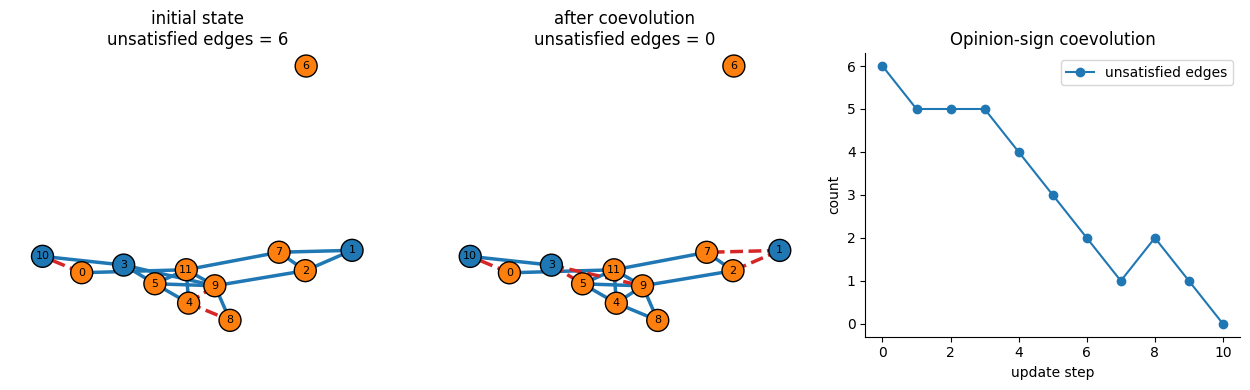

In [97]:
def random_signed_graph_with_opinions(n, p_edge=0.28, p_neg=0.35, seed=SEED):
    """Sparse signed graph together with binary node opinions."""
    rng_local = np.random.default_rng(seed)
    G = nx.gnp_random_graph(n, p_edge, seed=seed)
    for u, v in G.edges():
        G[u][v][SIGN] = -1 if rng_local.random() < p_neg else +1
    opinions = {u: (-1 if rng_local.random() < 0.5 else +1) for u in G.nodes()}
    return G, opinions


def unsatisfied_edges(G, opinions):
    """Edges whose sign disagrees with the endpoint opinions."""
    bad = []
    for u, v, d in G.edges(data=True):
        if d.get(SIGN, +1) != opinions[u] * opinions[v]:
            bad.append((u, v))
    return bad


def coevolve_opinions_and_signs(G, opinions, steps=120, p_flip_sign=0.60, seed=SEED):
    """Simple coevolution rule on unsatisfied edges."""
    H = G.copy()
    x = dict(opinions)
    rng_local = np.random.default_rng(seed)
    history = {
        "unsatisfied_edges": [len(unsatisfied_edges(H, x))],
        "positive_edge_fraction": [
            np.mean([d.get(SIGN, +1) > 0 for _, _, d in H.edges(data=True)]) if H.number_of_edges() else np.nan
        ],
    }

    for _ in range(steps):
        bad = unsatisfied_edges(H, x)
        if not bad:
            break

        u, v = bad[int(rng_local.integers(len(bad)))]
        if rng_local.random() < p_flip_sign:
            H[u][v][SIGN] *= -1
        else:
            if rng_local.random() < 0.5:
                x[u] *= -1
            else:
                x[v] *= -1

        history["unsatisfied_edges"].append(len(unsatisfied_edges(H, x)))
        history["positive_edge_fraction"].append(
            np.mean([d.get(SIGN, +1) > 0 for _, _, d in H.edges(data=True)]) if H.number_of_edges() else np.nan
        )

    return H, x, history


G_co_start, opinions_start = random_signed_graph_with_opinions(12, p_edge=0.26, p_neg=0.38, seed=SEED + 400)
G_co_end, opinions_end, hist_co = coevolve_opinions_and_signs(
    G_co_start,
    opinions_start,
    steps=140,
    p_flip_sign=0.60,
    seed=SEED + 401,
)

pos_co = nx.spring_layout(G_co_start, seed=SEED)
node_colors_start = [POS_EDGE_COLOR if opinions_start[u] > 0 else "tab:orange" for u in G_co_start.nodes()]
node_colors_end = [POS_EDGE_COLOR if opinions_end[u] > 0 else "tab:orange" for u in G_co_end.nodes()]

fig, axes = plt.subplots(1, 3, figsize=(12.6, 4.0), dpi=100)

draw_signed_graph(
    G_co_start,
    ax=axes[0],
    title=f"initial state\nunsatisfied edges = {len(unsatisfied_edges(G_co_start, opinions_start))}",
    pos=pos_co,
    node_colors=node_colors_start,
)
draw_signed_graph(
    G_co_end,
    ax=axes[1],
    title=f"after coevolution\nunsatisfied edges = {len(unsatisfied_edges(G_co_end, opinions_end))}",
    pos=pos_co,
    node_colors=node_colors_end,
)
axes[2].plot(hist_co["unsatisfied_edges"], marker="o", label="unsatisfied edges")
axes[2].set_xlabel("update step")
axes[2].set_ylabel("count")
axes[2].set_title("Opinion-sign coevolution")
axes[2].legend()

plt.tight_layout()
plt.show()


This is the simplest possible coevolution story, but the point is already there.

A system can reduce tension either by rewriting relationships or by changing minds. Richer models add memory, thresholds, asymmetry, rewiring, and domain-specific meaning for negative edges. The feedback loop is the part to remember.


## 16. Open problems worth keeping in view

Some questions in this area are still very alive.

- **How do we scale up?** Exact motif enumeration, frustration minimization, and rich signed inference all get expensive quickly.
- **What should we do with neutral and absent edges?** In a signed social network, "we never interacted" and "we interact but neither like nor dislike each other" are not the same thing.
- **How should negative edges act in dynamics?** Many toy models make a negative edge simply flip a signal. In practice it may suppress, delay, amplify, or reroute influence instead.
- **What counts as a larger signed motif?** Once signs, directions, and null constraints all matter, the motif space explodes.
- **When is a signed graph the right abstraction at all?** Correlation matrices, inferred dislike links, and platform-mediated interactions can all produce negative numbers, but not all negative numbers mean the same thing.
- **How should we benchmark methods across domains?** Balance, factions, polarization, hierarchy, and core-periphery structure can overlap without being the same thing.

That is part of what makes the recent signed-networks review so useful. It does not just list methods. It keeps asking where each method is appropriate, what assumptions it sneaks in, and what kind of evidence would actually change your mind.


# Summary

The first half of the notebook made one habit unavoidable: ask what is being counted, what the null preserves, and what claim the comparison actually supports.

The second half reused exactly the same habit on signed graphs. A sign is not decoration. It changes walks, balance, distance, centrality, partitions, and dynamics.

So the toolkit we built is fairly compact but already useful: motif counts, $dK$ constraints, signed adjacency decompositions, frustration and walk-based balance, resistance distance, spectral embeddings, disagreement objectives, sign-prediction ideas, and toy signed dynamics.

That is enough to start reading the modern motifs and signed-networks literatures without constantly wondering which pieces are definitions, which are baselines, and which are actual scientific claims.


# Appendix A: Efficient motif enumeration with ESU

The main lecture path used brute force because it is transparent. For larger graphs, the bottleneck is that brute force inspects every $k$-node subset whether or not it is connected.

ESU is a classic way around that. It enumerates connected node sets exactly once by growing them from a root node and maintaining an extension set that avoids duplicates.

The implementation below is intentionally teaching-oriented. The point is to understand what the algorithm is buying you, not to optimize every constant factor.


In [98]:
def esu_enumerate_nodesets(G, k):
    """Yield connected k-node sets using the ESU idea."""
    nodes_sorted = sorted(G.nodes())
    order = {u: i for i, u in enumerate(nodes_sorted)}

    def exclusive_neighbors(w, sub):
        excl = set(G.neighbors(w))
        for u in sub:
            excl -= set(G.neighbors(u))
        excl -= set(sub)
        return excl

    def extend(sub, ext, root):
        if len(sub) == k:
            yield tuple(sub)
            return

        ext_list = sorted(ext, key=lambda u: order[u])
        for idx, w in enumerate(ext_list):
            ext_remaining = set(ext_list[idx + 1 :])
            excl = exclusive_neighbors(w, sub)
            excl = {u for u in excl if order[u] > order[root]}
            new_ext = ext_remaining | excl
            yield from extend(sub + [w], new_ext, root)

    for root in nodes_sorted:
        ext0 = {u for u in G.neighbors(root) if order[u] > order[root]}
        yield from extend([root], ext0, root)


def motif_census_esu(G, k):
    """Exact graphlet census using ESU plus canonical labeling."""
    counts = Counter()
    for nodes in esu_enumerate_nodesets(G, k):
        H = G.subgraph(nodes)
        if nx.is_connected(H):
            counts[canonical_adj_string(H)] += 1
    return counts


G_bench = nx.erdos_renyi_graph(18, 0.20, seed=SEED)

counts_brute_4, _ = motif_census_bruteforce(G_bench, k=4)
counts_esu_4 = motif_census_esu(G_bench, k=4)

print("ESU matches brute force for k=4:", counts_esu_4 == counts_brute_4)
assert counts_esu_4 == counts_brute_4

# Show the number of connected 4-node sets found.
num_connected_subgraphs = sum(counts_esu_4.values())
print("Connected induced 4-node subgraphs in the benchmark graph:", num_connected_subgraphs)


ESU matches brute force for k=4: True
Connected induced 4-node subgraphs in the benchmark graph: 180


The point of ESU is conceptual efficiency: enumerate **connected** candidates without duplication, then classify them afterward.

Practical motif software adds more ideas on top of this:

- faster canonical labeling,
- sampling schemes such as RAND-ESU,
- specialized data structures such as g-tries,
- sparse linear algebra and combinatorial shortcuts for special motifs.

For teaching purposes, however, a correct ESU implementation is already a very useful bridge between brute force and research-scale tools.


# Appendix B: A compact $dK$ roadmap for null models

The source motif notebooks go much deeper into the $dK$ hierarchy than we did in the main lecture path. It is worth keeping a more explicit roadmap here, because it clarifies what stronger null models are trying to preserve and why motif claims become sharper as the null gets stronger.

The key move is to label a small motif not only by its shape, but also by the degrees of the participating nodes in the observed graph. As $d$ increases, the null model preserves richer and richer local information.

This appendix is still lighter than a full treatment of microcanonical samplers, but it is detailed enough to answer the question that usually comes up at this point:

> what, exactly, is a 2K or 3K null preserving that a 1K null is free to change?


### Degree labels are what make the hierarchy inclusive

Let $G_0$ be the observed graph and let $k(u)=\deg_{G_0}(u)$ be the degree of node $u$ in that observed graph.

In the $dK$ viewpoint, those degrees become **labels** attached to the nodes when we count motifs. So two wedges with the same shape are treated as different motif types if the participating node degrees differ.

For the smallest levels:

- $\Delta_1$ counts nodes by degree label,
- $\Delta_2$ counts edges by the degree pair on their endpoints,
- $\Delta_3$ counts wedges and triangles together with the degree labels of the participating nodes.

That degree labeling is why the hierarchy nests cleanly: if a null preserves enough degree-labeled 2-node information, it automatically preserves the 1-node degree information inside it.


In [99]:
def dk_distribution_1(G, deg_labels=None):
    """Return degree-labeled 1-node counts Δ1."""
    if deg_labels is None:
        deg_labels = dict(G.degree())

    out = Counter()
    for u in G.nodes():
        out[("node", deg_labels[u])] += 1
    return out


def dk_distribution_2(G, deg_labels=None):
    """Return degree-labeled 2-node counts Δ2, i.e. the joint degree distribution on edges."""
    if deg_labels is None:
        deg_labels = dict(G.degree())

    out = Counter()
    for u, v in G.edges():
        ku, kv = deg_labels[u], deg_labels[v]
        out[("edge", min(ku, kv), max(ku, kv))] += 1
    return out


def motif_key_3(G, triple, deg_labels):
    """Return a canonical key for a degree-labeled wedge or triangle."""
    a, b, c = triple

    e_ab = G.has_edge(a, b)
    e_ac = G.has_edge(a, c)
    e_bc = G.has_edge(b, c)
    ecount = int(e_ab) + int(e_ac) + int(e_bc)

    if ecount == 3:
        degs = sorted((deg_labels[a], deg_labels[b], deg_labels[c]))
        return ("triangle", degs[0], degs[1], degs[2])

    if ecount == 2:
        induced_deg = {
            a: int(e_ab) + int(e_ac),
            b: int(e_ab) + int(e_bc),
            c: int(e_ac) + int(e_bc),
        }
        center = [u for u, d in induced_deg.items() if d == 2][0]
        leaves = [u for u in (a, b, c) if u != center]
        leaf_degs = sorted((deg_labels[leaves[0]], deg_labels[leaves[1]]))
        return ("wedge", deg_labels[center], leaf_degs[0], leaf_degs[1])

    return None


def dk_distribution_3(G, deg_labels=None):
    """Return degree-labeled 3-node counts Δ3 for wedges and triangles."""
    if deg_labels is None:
        deg_labels = dict(G.degree())

    out = Counter()
    nodes = list(G.nodes())
    for triple in combinations(nodes, 3):
        key = motif_key_3(G, triple, deg_labels)
        if key is not None:
            out[key] += 1
    return out


In [100]:
deg_toy_dk = dict(G_toy.degree())

d1_toy = dk_distribution_1(G_toy, deg_toy_dk)
d2_toy = dk_distribution_2(G_toy, deg_toy_dk)
d3_toy = dk_distribution_3(G_toy, deg_toy_dk)

df_d1_toy = pd.DataFrame(
    [{"degree": key[1], "count": count} for key, count in d1_toy.items()]
).sort_values("degree").reset_index(drop=True)

df_d2_toy = pd.DataFrame(
    [{"degree_pair": key[1:], "count": count} for key, count in d2_toy.items()]
).sort_values(["count", "degree_pair"], ascending=[False, True]).reset_index(drop=True)

df_d3_toy = pd.DataFrame(
    [{"motif_type": key[0], "degree_labels": key[1:], "count": count} for key, count in d3_toy.items()]
).sort_values(["motif_type", "count"], ascending=[True, False]).reset_index(drop=True)

print("Toy-graph degree labels:", deg_toy_dk)
print()
print("Δ1: degree-labeled 1-node motifs")
display(df_d1_toy)
print("Δ2: degree-labeled 2-node motifs")
display(df_d2_toy)
print("Δ3: degree-labeled wedges and triangles")
display(df_d3_toy)


Toy-graph degree labels: {0: 2, 1: 2, 2: 4, 3: 2, 4: 3, 5: 1}

Δ1: degree-labeled 1-node motifs


,degree,count
0,1,1
1,2,3
2,3,1
3,4,1


Δ2: degree-labeled 2-node motifs


,degree_pair,count
0,"(2, 4)",3
1,"(1, 3)",1
2,"(2, 2)",1
3,"(2, 3)",1
4,"(3, 4)",1


Δ3: degree-labeled wedges and triangles


,motif_type,degree_labels,count
0,triangle,"(2, 2, 4)",1
1,triangle,"(2, 3, 4)",1
2,wedge,"(4, 2, 2)",2
3,wedge,"(4, 2, 3)",2
4,wedge,"(3, 1, 4)",1
5,wedge,"(3, 1, 2)",1


The tables are easiest to read if you keep the code-to-math mapping in view.

- $k(u)$ is stored in `deg_toy_dk[u]`.
- $\Delta_1$ is `d1_toy`.
- $\Delta_2$ is `d2_toy`.
- $\Delta_3$ is `d3_toy`.

The point is not that students should memorize these exact keys. The point is that a 3-node motif is now being described by both **shape** and **who in that shape had which observed degree**.


In [101]:
stub_counts = Counter()
for (_, k1, k2), count in d2_toy.items():
    if k1 == k2:
        stub_counts[k1] += 2 * count
    else:
        stub_counts[k1] += count
        stub_counts[k2] += count

degree_counts_from_d2 = {k: stub_counts[k] // k for k in sorted(stub_counts)}
degree_counts_from_d1 = {key[1]: count for key, count in sorted(d1_toy.items(), key=lambda x: x[0][1])}

print("Recovered degree counts from Δ2:", degree_counts_from_d2)
print("Direct degree counts from Δ1    :", degree_counts_from_d1)

assert degree_counts_from_d2 == degree_counts_from_d1


Recovered degree counts from Δ2: {1: 1, 2: 3, 3: 1, 4: 1}
Direct degree counts from Δ1    : {1: 1, 2: 3, 3: 1, 4: 1}


### Why 1K and 2K are genuinely different null models

A standard degree-preserving randomization keeps the full degree sequence fixed, so it preserves **1K**. But it usually changes which degrees connect to which degrees, so it need not preserve **2K**.

That distinction matters whenever the structure you care about could already be explained by degree-degree mixing. The next cell compares the clustered graph from Part I with its degree-preserving randomization.


A small hand-built example makes the 1K-versus-2K distinction explicit.

In the graph below, the edge pair $\{0,4\}$ and $\{2,3\}$ can be rewired into $\{0,3\}$ and $\{2,4\}$. The degree sequence is unchanged, so the move is 1K-valid. But the degree labels on the affected edges change from one $(3,1)$ edge and one $(2,2)$ edge to one $(3,2)$ edge and one $(2,1)$ edge. So $\Delta_2$ changes even though $\Delta_1$ does not.


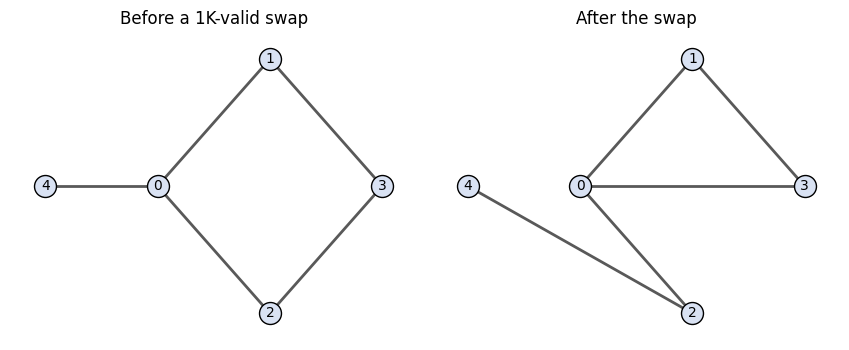

Degree sequence before: {0: 3, 1: 2, 2: 2, 4: 1, 3: 2}
Degree sequence after : {0: 3, 1: 2, 2: 2, 4: 1, 3: 2}
Δ2 before: {('edge', 1, 3): 1, ('edge', 2, 2): 2, ('edge', 2, 3): 2}
Δ2 after : {('edge', 1, 2): 1, ('edge', 2, 2): 1, ('edge', 2, 3): 3}


In [102]:
G_dk_swap = nx.Graph()
G_dk_swap.add_edges_from([(0, 1), (0, 2), (0, 4), (1, 3), (2, 3)])

deg_before_dk = dict(G_dk_swap.degree())
d1_before_dk = dk_distribution_1(G_dk_swap, deg_before_dk)
d2_before_dk = dk_distribution_2(G_dk_swap, deg_before_dk)

G_dk_swap_after = G_dk_swap.copy()
G_dk_swap_after.remove_edge(0, 4)
G_dk_swap_after.remove_edge(2, 3)
G_dk_swap_after.add_edge(0, 3)
G_dk_swap_after.add_edge(2, 4)

deg_after_dk = dict(G_dk_swap_after.degree())
d1_after_dk = dk_distribution_1(G_dk_swap_after, deg_after_dk)
d2_after_dk = dk_distribution_2(G_dk_swap_after, deg_after_dk)

fig, axes = plt.subplots(1, 2, figsize=(8.6, 3.6), dpi=100)
pos_dk_swap = {0: (-1.0, 0.0), 1: (0.0, 1.0), 2: (0.0, -1.0), 3: (1.0, 0.0), 4: (-2.0, 0.0)}

draw_graph(G_dk_swap, ax=axes[0], title="Before a 1K-valid swap", pos=pos_dk_swap)
draw_graph(G_dk_swap_after, ax=axes[1], title="After the swap", pos=pos_dk_swap)
plt.tight_layout()
plt.show()

print("Degree sequence before:", deg_before_dk)
print("Degree sequence after :", deg_after_dk)
print("Δ2 before:", dict(sorted(d2_before_dk.items())))
print("Δ2 after :", dict(sorted(d2_after_dk.items())))

assert deg_before_dk == deg_after_dk
assert d1_before_dk == d1_after_dk
assert d2_before_dk != d2_after_dk

In [103]:
deg_ws_dk = dict(G_ws.degree())
d1_ws = dk_distribution_1(G_ws, deg_ws_dk)
d2_ws = dk_distribution_2(G_ws, deg_ws_dk)

d1_ws_rand = dk_distribution_1(G_ws_rand, deg_ws_dk)
d2_ws_rand = dk_distribution_2(G_ws_rand, deg_ws_dk)

comparison_dk = pd.DataFrame(
    [
        {
            "comparison": "degree sequence / 1K",
            "preserved?": d1_ws == d1_ws_rand,
        },
        {
            "comparison": "joint degree counts / 2K",
            "preserved?": d2_ws == d2_ws_rand,
        },
        {
            "comparison": "triangle count",
            "preserved?": triangle_count_nx(G_ws) == triangle_count_nx(G_ws_rand),
        },
    ]
)
display(comparison_dk)

diff_d2 = Counter()
for key in set(d2_ws) | set(d2_ws_rand):
    diff = d2_ws_rand.get(key, 0) - d2_ws.get(key, 0)
    if diff != 0:
        diff_d2[key] = diff

if diff_d2:
    df_diff_d2 = pd.DataFrame(
        [{"degree_pair": key[1:], "delta_randomized_minus_original": delta} for key, delta in diff_d2.items()]
    ).sort_values("delta_randomized_minus_original", key=lambda s: np.abs(s), ascending=False).reset_index(drop=True)
else:
    df_diff_d2 = pd.DataFrame(columns=["degree_pair", "delta_randomized_minus_original"])

display(df_diff_d2.head(10))


,comparison,preserved?
0,degree sequence / 1K,True
1,joint degree counts / 2K,True
2,triangle count,False


,degree_pair,delta_randomized_minus_original


### A tiny 2K-preserving sampler

Computing $\Delta_2$ is only half the story. A 2K null model also needs moves that keep those joint degree counts fixed while still changing the graph.

A very small way to do that is to swap two edges only when the multiset of endpoint degree pairs is unchanged after the swap. That is the whole 2K instinct in one sentence.


,sample,accepted swaps,Δ1 preserved?,Δ2 preserved?,triangle count
0,original graph,0,True,True,2
1,1K swap chain,6,True,False,2
2,2K-preserving chain,6,True,True,0


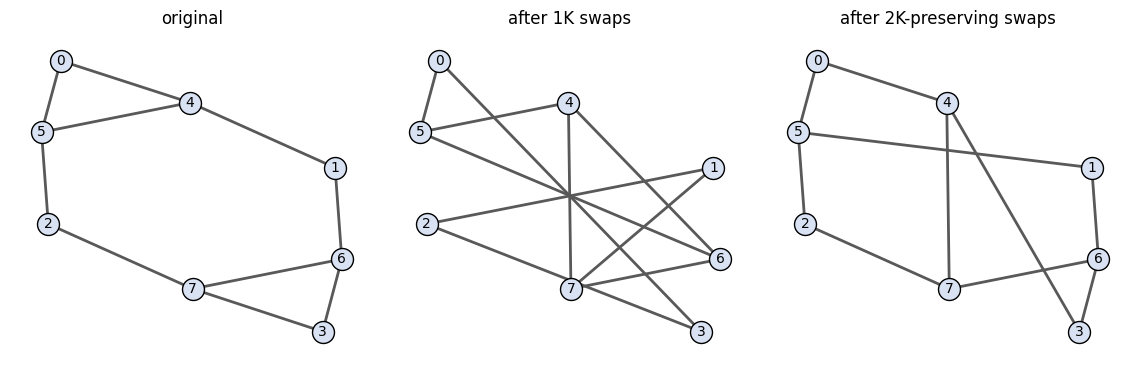

In [104]:
def one_k_swap_with_count(G, nswap=1, max_tries=10000, rng_local=None):
    """Small wrapper around the 1K swap logic that also reports accepted swaps."""
    if rng_local is None:
        rng_local = random.Random(SEED)

    H = G.copy()
    edges = [(min(u, v), max(u, v)) for u, v in H.edges()]
    swaps = 0
    tries = 0

    while swaps < nswap and tries < max_tries and len(edges) >= 2:
        tries += 1
        i1, i2 = rng_local.sample(range(len(edges)), 2)
        a, b = edges[i1]
        c, d = edges[i2]

        if len({a, b, c, d}) < 4:
            continue

        if rng_local.random() < 0.5:
            x, y = a, d
            u, v = c, b
        else:
            x, y = a, c
            u, v = d, b

        if x == y or u == v:
            continue

        x, y = (min(x, y), max(x, y))
        u, v = (min(u, v), max(u, v))

        if H.has_edge(x, y) or H.has_edge(u, v):
            continue

        H.remove_edge(a, b)
        H.remove_edge(c, d)
        H.add_edge(x, y)
        H.add_edge(u, v)

        edges[i1] = (x, y)
        edges[i2] = (u, v)
        swaps += 1

    return H, swaps


def two_k_swap_simple(G, nswap=1, max_tries=10000, rng_local=None):
    """Degree-pair-preserving edge swaps for a small teaching demo of 2K sampling."""
    if rng_local is None:
        rng_local = random.Random(SEED)

    H = G.copy()
    edges = list(H.edges())
    tries = 0
    swaps = 0

    while swaps < nswap and tries < max_tries and len(edges) >= 2:
        tries += 1
        e1_idx, e2_idx = rng_local.sample(range(len(edges)), 2)
        (a, b) = edges[e1_idx]
        (c, d) = edges[e2_idx]

        if len({a, b, c, d}) < 4:
            continue

        deg = dict(H.degree())
        old_pairs = sorted(
            [
                tuple(sorted((deg[a], deg[b]))),
                tuple(sorted((deg[c], deg[d]))),
            ]
        )

        candidates = [((a, d), (c, b)), ((a, c), (d, b))]
        rng_local.shuffle(candidates)

        moved = False
        for (u1, v1), (u2, v2) in candidates:
            if u1 == v1 or u2 == v2:
                continue
            if H.has_edge(u1, v1) or H.has_edge(u2, v2):
                continue

            new_pairs = sorted(
                [
                    tuple(sorted((deg[u1], deg[v1]))),
                    tuple(sorted((deg[u2], deg[v2]))),
                ]
            )
            if new_pairs != old_pairs:
                continue

            H.remove_edge(a, b)
            H.remove_edge(c, d)
            H.add_edge(u1, v1)
            H.add_edge(u2, v2)
            edges = list(H.edges())
            swaps += 1
            moved = True
            break

        if not moved:
            continue

    return H, swaps


G_2k_demo = nx.Graph()
G_2k_demo.add_edges_from(
    [
        (0, 4), (0, 5),
        (1, 4), (1, 6),
        (2, 5), (2, 7),
        (3, 6), (3, 7),
        (4, 5), (6, 7),
    ]
)

G_1k_sample, accepted_1k = one_k_swap_with_count(
    G_2k_demo,
    nswap=6,
    max_tries=5000,
    rng_local=random.Random(SEED),
)
G_2k_sample, accepted_2k = two_k_swap_simple(
    G_2k_demo,
    nswap=6,
    max_tries=5000,
    rng_local=random.Random(SEED),
)

d1_demo = dk_distribution_1(G_2k_demo)
d2_demo = dk_distribution_2(G_2k_demo)

comparison_sampling = pd.DataFrame(
    [
        {
            "sample": "original graph",
            "accepted swaps": 0,
            "Δ1 preserved?": True,
            "Δ2 preserved?": True,
            "triangle count": triangle_count_nx(G_2k_demo),
        },
        {
            "sample": "1K swap chain",
            "accepted swaps": accepted_1k,
            "Δ1 preserved?": d1_demo == dk_distribution_1(G_1k_sample),
            "Δ2 preserved?": d2_demo == dk_distribution_2(G_1k_sample),
            "triangle count": triangle_count_nx(G_1k_sample),
        },
        {
            "sample": "2K-preserving chain",
            "accepted swaps": accepted_2k,
            "Δ1 preserved?": d1_demo == dk_distribution_1(G_2k_sample),
            "Δ2 preserved?": d2_demo == dk_distribution_2(G_2k_sample),
            "triangle count": triangle_count_nx(G_2k_sample),
        },
    ]
)
display(comparison_sampling)

pos_2k_demo = nx.spring_layout(G_2k_demo, seed=SEED)
fig, axes = plt.subplots(1, 3, figsize=(11.5, 3.8), dpi=100)
draw_graph(G_2k_demo, ax=axes[0], title="original", pos=pos_2k_demo)
draw_graph(G_1k_sample, ax=axes[1], title="after 1K swaps", pos=pos_2k_demo)
draw_graph(G_2k_sample, ax=axes[2], title="after 2K-preserving swaps", pos=pos_2k_demo)
plt.tight_layout()
plt.show()


The useful part is not the specific graph. It is the preservation logic.

The 1K sampler keeps node degrees fixed and is still free to change degree-degree mixing. The 2K sampler keeps the joint degree counts fixed as well, but it can still change triangles and larger graphlets. That is exactly why different $dK$ levels lead to different null-model answers.


This is the practical reading of the hierarchy.

A 1K null asks whether your statistic is unusual after matching node-level opportunity. A 2K null asks whether it is still unusual after matching **who tends to connect to whom by degree**. A 3K null goes one step further and freezes degree-labeled wedges and triangles themselves. At that point, 3-node motif discovery is no longer the thing being tested; it has become part of the baseline.

That is why stronger nulls are not “better” in the abstract. They are better only when they match the scientific question you are actually asking.


In [105]:
dk_levels = pd.DataFrame(
    [
        {
            "level": "0K",
            "what is fixed": "edge density or average degree",
            "what a null can still change": "degree heterogeneity, clustering, local motifs",
            "good for testing": "whether any local structure exceeds what density alone creates",
        },
        {
            "level": "1K",
            "what is fixed": "full degree sequence",
            "what a null can still change": "degree correlations, triangles, 4-node motifs",
            "good for testing": "whether a pattern exceeds what node-level degree opportunity creates",
        },
        {
            "level": "2K",
            "what is fixed": "joint degree information across edges",
            "what a null can still change": "triangles and higher graphlets beyond edge-level mixing",
            "good for testing": "whether a pattern exceeds what degree mixing already explains",
        },
        {
            "level": "3K",
            "what is fixed": "degree-labeled wedges and triangles",
            "what a null can still change": "many 4-node and larger motifs",
            "good for testing": "4-node structure after matching 3-node degree-labeled closure",
        },
        {
            "level": "4K",
            "what is fixed": "degree-labeled connected 4-node motifs",
            "what a null can still change": "larger-scale structure",
            "good for testing": "structure beyond connected 4-node graphlets",
        },
    ]
)
display(dk_levels)


,level,what is fixed,what a null can still change,good for testing
0,0K,edge density or average degree,"degree heterogeneity, clustering, local motifs",whether any local structure exceeds what densi...
1,1K,full degree sequence,"degree correlations, triangles, 4-node motifs",whether a pattern exceeds what node-level degr...
2,2K,joint degree information across edges,triangles and higher graphlets beyond edge-lev...,whether a pattern exceeds what degree mixing a...
3,3K,degree-labeled wedges and triangles,many 4-node and larger motifs,4-node structure after matching 3-node degree-...
4,4K,degree-labeled connected 4-node motifs,larger-scale structure,structure beyond connected 4-node graphlets


The most important conceptual takeaway is simple.

A motif can stop being "surprising" when you move from a 1K null to a 3K null because the stronger null already preserves the lower-order local structure that generated it.

So a good motif statement is not just "this graph has many triangles." It is something more precise, such as:

> this graph has more triangles than expected after matching the degree sequence.

The sharper the null, the sharper the interpretation.


# Appendix C: Directed signed networks and status theory

Balance theory is naturally phrased for undirected signed graphs. But many empirical signed datasets are directed: one user rates another, one actor endorses another, one node activates or suppresses another.

In that setting, **status theory** becomes a useful alternative perspective.

The core idea is that direction and sign together may encode a latent ranking. A positive edge $i \to j$ suggests that $j$ is above $i$ in that ranking; a negative edge $i \to j$ suggests the opposite. One convenient way to test that intuition is to reverse each negative edge and then treat every transformed edge as positive.

If the transformed digraph is close to acyclic, that is evidence for an ordering-like explanation rather than a factional one.

In other words, the signed-direction pair on an edge is interpreted before any community structure is imposed. That is why status theory is often a better first model for explicit evaluation data than an undirected balance reduction would be.


In [106]:
def draw_signed_digraph(G, ax=None, title=None, pos=None):
    """Draw a directed signed graph with colored arrows."""
    if ax is None:
        fig, ax = plt.subplots(figsize=(4, 4), dpi=100)

    if pos is None:
        pos = nx.spring_layout(G, seed=SEED)

    show_labels = G.number_of_nodes() <= 14
    font_size = 10 if G.number_of_nodes() <= 10 else 8

    pos_edges = [(u, v) for u, v, d in G.edges(data=True) if d.get(SIGN, +1) > 0]
    neg_edges = [(u, v) for u, v, d in G.edges(data=True) if d.get(SIGN, +1) < 0]

    nx.draw_networkx_nodes(
        G,
        pos,
        ax=ax,
        node_size=700,
        node_color=NODE_FILL_COLOR,
        edgecolors="black",
    )
    if show_labels:
        nx.draw_networkx_labels(G, pos, ax=ax, font_size=font_size)

    if pos_edges:
        nx.draw_networkx_edges(
            G,
            pos,
            ax=ax,
            edgelist=pos_edges,
            width=2,
            edge_color=POS_EDGE_COLOR,
            arrows=True,
            arrowstyle="-|>",
            arrowsize=15,
            connectionstyle="arc3,rad=0.06",
        )
    if neg_edges:
        nx.draw_networkx_edges(
            G,
            pos,
            ax=ax,
            edgelist=neg_edges,
            width=2,
            edge_color=NEG_EDGE_COLOR,
            style="dashed",
            arrows=True,
            arrowstyle="-|>",
            arrowsize=15,
            connectionstyle="arc3,rad=0.06",
        )

    ax.set_axis_off()
    if title is not None:
        ax.set_title(title)


In [107]:
DG_status_toy = nx.DiGraph()
DG_status_toy.add_nodes_from(["a", "b", "c", "d"])

DG_status_toy.add_edge("a", "b", **{SIGN: +1})
DG_status_toy.add_edge("b", "c", **{SIGN: +1})
DG_status_toy.add_edge("a", "c", **{SIGN: -1})
DG_status_toy.add_edge("d", "b", **{SIGN: -1})
DG_status_toy.add_edge("d", "c", **{SIGN: +1})

In [108]:
def status_transform(DG):
    """Reverse negative edges and keep positive edges as they are."""
    H = nx.DiGraph()
    H.add_nodes_from(DG.nodes())
    for u, v, d in DG.edges(data=True):
        if d.get(SIGN, +1) > 0:
            H.add_edge(u, v)
        else:
            H.add_edge(v, u)
    return H


def ordering_from_scores(scores):
    """Return nodes sorted from low score to high score."""
    return sorted(scores, key=lambda u: scores[u])


def edge_forward_fraction(DG, order):
    """Return the fraction of edges that point forward in a proposed ordering."""
    pos = {u: i for i, u in enumerate(order)}
    m = DG.number_of_edges()
    if m == 0:
        return np.nan

    forward = 0
    for u, v in DG.edges():
        if pos[u] < pos[v]:
            forward += 1
    return forward / m


def status_consistency_score_deg(DG_signed):
    """A simple status score using a transformed-degree ordering."""
    H = status_transform(DG_signed)
    scores = {u: H.out_degree(u) - H.in_degree(u) for u in H.nodes()}
    order = ordering_from_scores(scores)
    return edge_forward_fraction(H, order), scores, order


def status_consistency_score_pagerank(DG_signed):
    """A second status score based on PageRank ordering after the status transform."""
    H = status_transform(DG_signed)
    pr = nx.pagerank(H, alpha=0.85)
    order = ordering_from_scores(pr)
    return edge_forward_fraction(H, order), pr, order

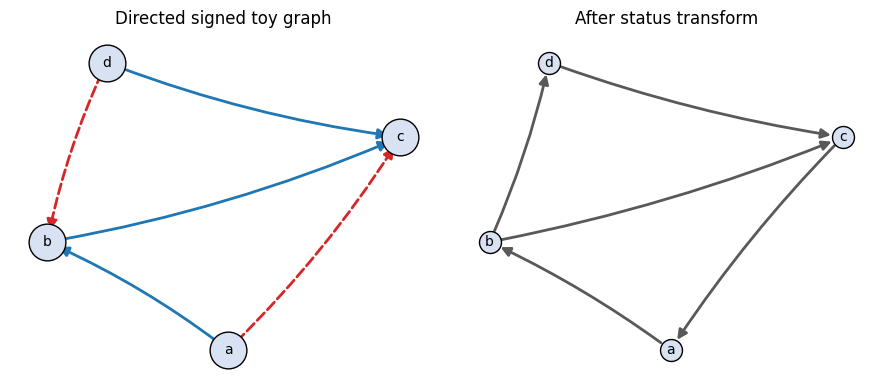

Transformed-degree status score : 0.4
Ordering (low to high status)   : ['c', 'a', 'd', 'b']
Transformed scores              : {'a': 0, 'b': 1, 'c': -1, 'd': 0}

PageRank-based status score     : 0.4
PageRank ordering              : ['d', 'b', 'a', 'c']
PageRank on transformed graph  : {'a': 0.281, 'b': 0.277, 'c': 0.287, 'd': 0.155}


In [109]:
DG_transformed = status_transform(DG_status_toy)
status_score_deg, scores_deg, order_deg = status_consistency_score_deg(DG_status_toy)
status_score_pr, pr_scores, order_pr = status_consistency_score_pagerank(DG_status_toy)

fig, axes = plt.subplots(1, 2, figsize=(9, 4), dpi=100)
pos_dg = nx.spring_layout(DG_status_toy, seed=SEED)
draw_signed_digraph(DG_status_toy, ax=axes[0], title="Directed signed toy graph", pos=pos_dg)
draw_digraph(DG_transformed, ax=axes[1], title="After status transform", pos=pos_dg)
plt.tight_layout()
plt.show()

print("Transformed-degree status score :", round(status_score_deg, 3))
print("Ordering (low to high status)   :", order_deg)
print("Transformed scores              :", scores_deg)
print()
print("PageRank-based status score     :", round(status_score_pr, 3))
print("PageRank ordering              :", order_pr)
print("PageRank on transformed graph  :", {k: round(v, 3) for k, v in pr_scores.items()})

The balance and status viewpoints are not competitors so much as different hypotheses about what organized the data.

- **Balance** asks whether signs are consistent with factional splitting.
- **Status** asks whether signs and directions are consistent with an ordering.

This difference shows up already at the triad level. A directed signed triad can look awkward from the viewpoint of undirected balance and still be perfectly coherent from the viewpoint of status once negative edges are reversed.

That is why directed signed data should not be reduced too quickly to an undirected balance problem. Sometimes two camps are the right mental model. Sometimes a ranking is the right mental model. Good signed-network work checks which story the data supports more strongly.


# Appendix D: Sign prediction from local and global signed structure

A natural inference problem on signed networks is **sign prediction**.

Given an observed edge $(i,j)$, can we predict whether it is positive or negative from the surrounding signed structure?

The local version uses triads. For an undirected signed graph, count common neighbors of four kinds:

- $c_{++}$: both incident signs are positive,
- $c_{+-}$: positive then negative,
- $c_{-+}$: negative then positive,
- $c_{--}$: both incident signs are negative.

Balance theory suggests that $c_{++}$ and $c_{--}$ often support a positive edge, while $c_{+-}$ and $c_{-+}$ often support a negative edge.

But local structure is not the whole story. If the graph has a strong factional backbone, the endpoints of an edge also inherit information from where they sit in that larger picture. So we will add one small global feature too: the product of the two endpoints' coordinates in the smallest-eigenvector direction of the signed Laplacian, computed after removing the target edge.

There is one implementation detail that matters a lot: when we predict the sign of an edge $(i,j)$, we should build features from the graph **with that edge removed**. Otherwise the target sign leaks directly into endpoint degrees and spectral summaries, and the exercise becomes artificially easy.


In [110]:
def edge_sign(G, u, v):
    """Return the sign on an existing edge."""
    return int(G[u][v].get(SIGN, +1))


def triad_features_for_edge(G, u, v):
    """Return signed-triad features for an undirected candidate edge absent from G."""
    if G.has_edge(u, v):
        raise ValueError("triad_features_for_edge expects the target edge to be absent.")

    common = set(G.neighbors(u)) & set(G.neighbors(v))
    c_pp = c_pn = c_np = c_nn = 0

    for w in common:
        su = edge_sign(G, u, w)
        sv = edge_sign(G, v, w)
        if su > 0 and sv > 0:
            c_pp += 1
        elif su > 0 and sv < 0:
            c_pn += 1
        elif su < 0 and sv > 0:
            c_np += 1
        else:
            c_nn += 1

    k_pos, k_neg, k_abs, k_net = signed_degrees(G)
    feats = [
        c_pp, c_pn, c_np, c_nn,
        k_pos[u], k_neg[u], k_net[u],
        k_pos[v], k_neg[v], k_net[v],
    ]
    return feats


def global_alignment_feature(H, u, v):
    """Global factional signal from the smallest signed-Laplacian eigenvector."""
    L, nodes = signed_laplacian_matrix(H)
    evals, evecs = np.linalg.eigh(L)
    v0 = evecs[:, 0]
    idx = {node: i for i, node in enumerate(nodes)}
    return float(v0[idx[u]] * v0[idx[v]])


def sign_prediction_dataset(G, edges, include_global=False):
    """Create a feature matrix and binary labels using leave-one-edge-out features."""
    X = []
    y = []
    for u, v in edges:
        H = G.copy()
        H.remove_edge(u, v)
        feats = triad_features_for_edge(H, u, v)
        if include_global:
            feats = feats + [global_alignment_feature(H, u, v)]
        X.append(feats)
        y.append(1 if edge_sign(G, u, v) > 0 else 0)
    return np.asarray(X, dtype=float), np.asarray(y, dtype=int)


def spectral_sign_scores(G, edges):
    """Return spectral alignment scores for a list of edges."""
    scores = []
    for u, v in edges:
        H = G.copy()
        H.remove_edge(u, v)
        scores.append(global_alignment_feature(H, u, v))
    return np.asarray(scores, dtype=float)


In [111]:
G_pred, labels_pred = make_signed_sbm(
    [24, 24],
    p_pos_in=0.24,
    p_neg_in=0.03,
    p_pos_out=0.03,
    p_neg_out=0.22,
    seed=SEED + 1,
)

edges_pred = list(G_pred.edges())
rng.shuffle(edges_pred)
split = int(0.8 * len(edges_pred))
train_edges = edges_pred[:split]
test_edges = edges_pred[split:]

X_train_local, y_train = sign_prediction_dataset(G_pred, train_edges, include_global=False)
X_test_local, y_test = sign_prediction_dataset(G_pred, test_edges, include_global=False)

X_train_hybrid, _ = sign_prediction_dataset(G_pred, train_edges, include_global=True)
X_test_hybrid, _ = sign_prediction_dataset(G_pred, test_edges, include_global=True)

clf_local = LogisticRegression(max_iter=2000)
clf_local.fit(X_train_local, y_train)
prob_local = clf_local.predict_proba(X_test_local)[:, 1]
pred_local = (prob_local >= 0.5).astype(int)

clf_hybrid = LogisticRegression(max_iter=2000)
clf_hybrid.fit(X_train_hybrid, y_train)
prob_hybrid = clf_hybrid.predict_proba(X_test_hybrid)[:, 1]
pred_hybrid = (prob_hybrid >= 0.5).astype(int)

score_global = spectral_sign_scores(G_pred, test_edges)
pred_global = (score_global >= 0.0).astype(int)

comparison_pred = pd.DataFrame(
    [
        {
            "model": "local triad + degree features",
            "test AUC": roc_auc_score(y_test, prob_local),
            "test accuracy": accuracy_score(y_test, pred_local),
        },
        {
            "model": "global spectral heuristic only",
            "test AUC": roc_auc_score(y_test, score_global),
            "test accuracy": accuracy_score(y_test, pred_global),
        },
        {
            "model": "local features + global spectral feature",
            "test AUC": roc_auc_score(y_test, prob_hybrid),
            "test accuracy": accuracy_score(y_test, pred_hybrid),
        },
    ]
).round(3)
display(comparison_pred)

coef_df = pd.DataFrame(
    {
        "feature": [
            "c_pp", "c_pn", "c_np", "c_nn",
            "u_k_pos", "u_k_neg", "u_k_net",
            "v_k_pos", "v_k_neg", "v_k_net",
            "spectral_alignment",
        ],
        "coefficient": clf_hybrid.coef_[0],
    }
).sort_values("coefficient", ascending=False)
display(coef_df)


,model,test AUC,test accuracy
0,local triad + degree features,0.727,0.655
1,global spectral heuristic only,0.790,0.776
2,local features + global spectral feature,0.730,0.655


,feature,coefficient
0,c_pp,0.836172
3,c_nn,0.780357
10,spectral_alignment,0.559194
8,v_k_neg,0.075214
6,u_k_net,-0.052660
7,v_k_pos,-0.073693
5,u_k_neg,-0.107021
9,v_k_net,-0.148907
4,u_k_pos,-0.159681
2,c_np,-0.390246


Local triad counts already do real work. Cool.

The extra spectral feature is global: it asks whether the two endpoints sit on the same side of the graph's best two-faction direction after the target edge is removed. When the network really does have a factional backbone, that extra signal often helps most on low-embeddedness edges, where pure triad counts do not have much to look at.

That is the useful mental split:

- local methods read short signed motifs,
- global methods read the larger factional geometry of the graph.

Good sign-prediction pipelines usually mix both.


# Appendix E: A simple signed clustering coefficient

The modern signed-network literature treats **signed clustering** as part of the basic-metrics toolkit, but there is no single universal definition. Different applications emphasize different ingredients: some care about weights, some about direction, some about correlation structure, and some about balance.

For this notebook, a clean teaching version is to measure how wedges around node $i$ close **in sign**:

$$
C_i^{\pm}
=
\frac{1}{\binom{k_i}{2}}
\sum_{j<\ell \in N(i)}
s_{ij}\,s_{i\ell}\,\tilde s_{j\ell}.
$$

Here

- $k_i$ is the degree of node $i$,
- $N(i)$ is the neighbor set of $i$,
- $s_{uv} \in \{-1,+1\}$ is the sign of edge $(u,v)$ when that edge exists,
- $\tilde s_{j\ell}=0$ if $(j,\ell)$ is absent, and otherwise $\tilde s_{j\ell}=s_{j\ell}$.

This puts the score in $[-1,1]$.

- A **balanced closed triangle** contributes $+1$.
- An **unbalanced closed triangle** contributes $-1$.
- An **open wedge** contributes $0$.

So $C_i^{\pm}$ answers a precise local question: when a wedge centered at node $i$ tries to close, does it usually close in a balanced or unbalanced way?

This is not the only signed clustering coefficient in the literature, but it matches the motif-and-balance logic developed in the main lecture and is easy to compute by hand.

For correlation-derived signed networks, Costantini and Perugini (2014) develop related signed clustering ideas in a weighted setting. The point here is not to reproduce their full framework, but to keep a simple local measure that matches the motif-and-balance logic of the main lecture.


Before computing the full table, it helps to work through one node by hand.

Take node $4$ in the toy signed graph. Its neighbors are $\{2,3,5\}$, so there are $\binom{3}{2}=3$ possible wedges centered at node $4$.

- The pair $(2,3)$ closes a triangle, and its sign product is $s_{42}s_{43}s_{23}=(+1)(+1)(-1)=-1$.
- The pairs $(2,5)$ and $(3,5)$ do not close, so they each contribute $0$.

So the local signed clustering score at node $4$ is $(-1 + 0 + 0)/3 = -1/3$. The next cell prints the contribution table explicitly so we can check the sign in code rather than by memory.


In [112]:
node_check = 4
neighbor_pairs = []
for j, k in combinations(sorted(G_signed_toy.neighbors(node_check)), 2):
    if G_signed_toy.has_edge(j, k):
        tri_sign = (
            G_signed_toy[node_check][j][SIGN]
            * G_signed_toy[node_check][k][SIGN]
            * G_signed_toy[j][k][SIGN]
        )
    else:
        tri_sign = 0
    neighbor_pairs.append(
        {
            "center node": node_check,
            "neighbor pair": (j, k),
            "closed?": G_signed_toy.has_edge(j, k),
            "contribution": tri_sign,
        }
    )

df_node4_closure = pd.DataFrame(neighbor_pairs)
display(df_node4_closure)


,center node,neighbor pair,closed?,contribution
0,4,"(2, 3)",True,-1
1,4,"(2, 5)",False,0
2,4,"(3, 5)",False,0


,degree,unsigned_clustering,balanced_closed,unbalanced_closed,signed_clustering
node,,,,,
0,2,1.000000,1,0,1.000000
1,2,1.000000,1,0,1.000000
2,4,0.333333,1,1,0.000000
3,2,1.000000,0,1,-1.000000
4,3,0.333333,0,1,-0.333333
5,1,NaN,0,0,NaN


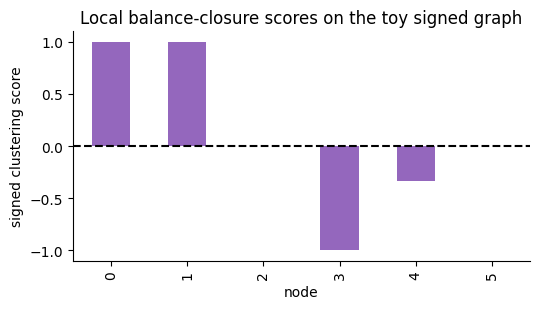

In [113]:
def signed_clustering_balance_score(G):
    """Return a teaching-oriented local signed clustering score.

    For each node i, every neighbor pair contributes:
    +1 for a balanced closed triangle,
    -1 for an unbalanced closed triangle,
     0 for an open wedge.

    The score is normalized by the number of possible wedges around i.
    """
    rows = []

    for i in G.nodes():
        nbrs = list(G.neighbors(i))
        ki = len(nbrs)
        denom = math.comb(ki, 2) if ki >= 2 else 0

        signed_sum = 0
        balanced_closed = 0
        unbalanced_closed = 0

        for j, k in combinations(nbrs, 2):
            if G.has_edge(j, k):
                tri_sign = G[i][j][SIGN] * G[i][k][SIGN] * G[j][k][SIGN]
                signed_sum += tri_sign
                if tri_sign > 0:
                    balanced_closed += 1
                else:
                    unbalanced_closed += 1

        rows.append(
            {
                "node": i,
                "degree": ki,
                "unsigned_clustering": nx.clustering(G, i) if ki >= 2 else np.nan,
                "balanced_closed": balanced_closed,
                "unbalanced_closed": unbalanced_closed,
                "signed_clustering": signed_sum / denom if denom else np.nan,
            }
        )

    return pd.DataFrame(rows).set_index("node")


df_signed_cluster = signed_clustering_balance_score(G_signed_toy)
display(df_signed_cluster)

assert np.isclose(df_signed_cluster.loc[0, "signed_clustering"], 1.0)
assert np.isclose(df_signed_cluster.loc[2, "signed_clustering"], 0.0)
assert np.isclose(df_signed_cluster.loc[4, "signed_clustering"], -1 / 3)

fig, ax = plt.subplots(figsize=(5.5, 3.2), dpi=100)
df_signed_cluster["signed_clustering"].plot(kind="bar", ax=ax, color="tab:purple")
ax.axhline(0, color=REFERENCE_LINE_COLOR, linestyle="--", linewidth=1.5)
ax.set_xlabel("node")
ax.set_ylabel("signed clustering score")
ax.set_title("Local balance-closure scores on the toy signed graph")
plt.tight_layout()
plt.show()

A useful contrast is between nodes 0, 2, and 4.

- Node 0 sits in one balanced triangle and nothing else, so its score is $1$.
- Node 2 participates in one balanced triangle and one unbalanced triangle, with several open wedges, so the positive and negative contributions cancel.
- Node 4 participates in one unbalanced triangle and two open wedges, so its score is negative.

That makes this coefficient a nice bridge between **triangle counting** and **local balance**: it is a clustering coefficient that remembers the sign pattern of the closure.


# Appendix F: Signed data, inference, and application domains

One of the most important lessons from modern signed-network work is that the sign itself is part of the model, not just a decoration on top of an ordinary graph.

Sometimes the sign is **explicit**: a trust or distrust vote, a positive or negative endorsement, an activating or inhibiting regulation. In other cases the sign is **inferred** from behavior, text, correlations, or bipartite projections. In those settings the sign-construction rule is already a methodological choice, so it should be discussed with the same care as the downstream analysis.

A useful habit is to ask three questions before running any signed-network method:

1. What does a positive edge mean in this domain?
2. What does a negative edge mean in this domain?
3. Was the sign observed directly, or inferred by preprocessing?


In [114]:
signed_domain_df = pd.DataFrame(
    [
        {
            "domain": "online trust and reputation",
            "nodes": "users or accounts",
            "positive tie": "trust / endorsement",
            "negative tie": "distrust / warning",
            "main caution": "direction often matters",
        },
        {
            "domain": "polarized online interaction",
            "nodes": "users, pages, or elites",
            "positive tie": "support / agreement",
            "negative tie": "attack / antagonism",
            "main caution": "signs may depend on text-labeling choices",
        },
        {
            "domain": "gene regulation",
            "nodes": "genes or regulators",
            "positive tie": "activation",
            "negative tie": "inhibition",
            "main caution": "direction is essential",
        },
        {
            "domain": "ecology",
            "nodes": "species",
            "positive tie": "mutualistic or facilitative effect",
            "negative tie": "competition / predation effect",
            "main caution": "sign can depend on scale and context",
        },
        {
            "domain": "functional or anatomical neuroscience",
            "nodes": "brain regions",
            "positive tie": "positive association / excitatory tendency",
            "negative tie": "negative association / inhibitory tendency",
            "main caution": "correlation signs are not automatically antagonism",
        },
    ]
)
display(signed_domain_df)

,domain,nodes,positive tie,negative tie,main caution
0,online trust and reputation,users or accounts,trust / endorsement,distrust / warning,direction often matters
1,polarized online interaction,"users, pages, or elites",support / agreement,attack / antagonism,signs may depend on text-labeling choices
2,gene regulation,genes or regulators,activation,inhibition,direction is essential
3,ecology,species,mutualistic or facilitative effect,competition / predation effect,sign can depend on scale and context
4,functional or anatomical neuroscience,brain regions,positive association / excitatory tendency,negative association / inhibitory tendency,correlation signs are not automatically antago...


A few methodological cautions are worth stating plainly.

- A signed edge is **not** the same thing as a missing positive edge.
- A signed graph is **not** automatically just a weighted graph with some negative numbers; many unsigned weighted methods fail when negative edges appear.
- Correlation matrices can be turned into signed graphs, but the semantic meaning of the negative edge must be defended rather than assumed.
- When signs are inferred, that inference step is part of the analysis, not a neutral preprocessing step.

Those cautions are one reason the application literature looks so diverse: the same mathematics appears across sociology, ecology, connectomics, and machine learning, but the sign semantics differ from case to case.

The application-side references at the end of the notebook give concrete examples from ecology, neuroscience, online polarization, and trust or distrust data.


# Appendix G: Software and a reading guide

If you want to move beyond a single notebook, it helps to separate **what you want to learn next** from **what you want to run next**.

Taken together, the main chapter and the appendices touch several major strands from the motif and signed-network literatures: motif counting, graphlet roles, null models, balance, frustration, signed Laplacians, multi-way signed clustering, directed status, sign prediction, and data-construction issues.

### Software and codebases

A few tools are worth knowing about.

**Motif and graphlet tools**

- `networkx.algorithms.triads.triadic_census`: a convenient teaching-scale tool for exact directed triad counts.
- `FANMOD`: a classic motif-detection package built around efficient sampling and enumeration ideas.
- `ORCA`: a fast graphlet-orbit counter for node- and edge-orbit statistics on sparse graphs.

**Signed-network tools**

- `alan-turing-institute/SigNet`: signed clustering methods, including spectral variants and generalized-eigenproblem methods such as SPONGE. The repository is archived, but it remains a readable reference implementation.
- `saref/frustration-index-UBQP`: exact frustration-index code for small to medium graphs.
- `benedekrozemberczki/SGCN`: a PyTorch implementation of Signed Graph Convolutional Networks.

### Datasets and practical benchmarks

Classic signed benchmark datasets include Epinions trust/distrust, Slashdot Zoo, Wikipedia voting or adminship data, and Bitcoin-Alpha / Bitcoin-OTC trust networks. SNAP remains a standard place to look for metadata and download pointers for several of these social signed datasets.

### What to read next, depending on your goal

- If you want the canonical motif papers, start with Milo et al. (2002), Shen-Orr et al. (2002), and Mangan and Alon (2003).
- If you want graphlets, orbit logic, and efficient counting, go next to Pržulj (2007), Milenković and Pržulj (2008), Hočevar and Demšar (2014), and Wernicke and Rasche (2006).
- If you want null-model discipline and the $dK$ viewpoint, return to Mahadevan et al. (2006), Newman (2002), and Orsini et al. (2015).
- If you want signed foundations, read Heider (1946), Harary (1953), Cartwright and Harary (1956), Davis (1967), and Zaslavsky (1982).
- If you want signed balance, frustration, and spectral structure, go next to Leskovec et al. (2010), Kunegis et al. (2010), Facchetti et al. (2011), Altafini (2013), Aref and Wilson (2018, 2019), Kirkley et al. (2019), Hao and Kovács (2024), and Gallo et al. (2024).
- If you want multi-way signed clustering and modern learning methods, continue with Cucuringu et al. (2019), Bansal et al. (2004), Derr et al. (2018), and Tang et al. (2016).


## Exercises and project starters

The notebook already contains several "Your turn!" prompts. The items below are slightly larger extensions that make good homework or mini-project starts.

### A. Motifs

1. Pick one undirected graph from NetworkX's built-in examples and compare triangle significance under:
   - an Erdős-Rényi null matched on density,
   - a degree-preserving swap null.

2. Modify the directed feed-forward-loop example so that you plant several other triad types instead. Which triad-census categories respond most strongly?

3. Repeat the 4-node graphlet census on a graph with a very different topology, such as a grid, a tree, or a preferential-attachment graph. Which graphlets dominate, and why?

### B. Signed networks

1. Construct a signed graph that is weakly balanced but not strongly balanced. Explain the difference in words and check the relevant cycle patterns.

2. Compare triangle balance, walk-based balance, and frustration on a family of noisy two-faction graphs. When do the local and global summaries begin to separate?

3. Build a signed SBM with more than two groups. Which parts of the two-faction spectral story still help, and which parts begin to break?

4. Re-run the sign-prediction appendix on graphs with weaker planted faction structure. Does the global spectral feature still help, or does it start to mislead?

5. Change the coevolution model so that opinion flips are much cheaper than sign flips, and then reverse that choice. What kind of final states do you get?

### C. Connecting the halves

1. Choose one local motif from Part I and ask what changes when edges are signed. Does the unsigned count still say enough?

2. Design a null model for signed triads that preserves the unsigned topology but changes the sign arrangement. What scientific question does your null model answer?

3. Construct a graph where a motif looks overrepresented under a 1K null but not under a 2K or 3K-style null. What did the stronger baseline explain away?


## Final synthesis

Motifs and signed networks are both about learning to take **local structure** seriously.

In motif analysis, the key lesson is that a local pattern is not automatically a motif. It becomes a motif only after comparison to a baseline that preserves the right lower-order structure.

In signed-network analysis, the key lesson is that a triad is not just present or absent. The same three nodes can encode agreement, tension, coalition, hierarchy, antagonism, or faction structure depending on the signs, directions, and surrounding graph.

The deeper bridge between the two halves is this:

- motifs teach us to look at **small recurring patterns**,
- signed networks teach us that those small patterns can carry **qualitative meaning**,
- dynamics remind us that those patterns can also be rewritten by the system itself.

So the habit to keep is not just "count small things." It is something sharper:

> identify the local pattern, decide what baseline makes sense, and then ask what the pattern means in this domain.

That habit travels well.


## References

This list is organized as a reading map, not just as a dump of citations. The annotations are short on purpose. They tell you why each item is worth your time.

### 1. Big-picture network references

- Newman, M. E. J. *Networks*. Oxford University Press, 2018. — Best all-around textbook reference for standard network language, null models, and matrix viewpoints.

- Chung, F. R. K. *Spectral Graph Theory*. American Mathematical Society, 1997. — The cleanest classic reference for Laplacians, spectra, and why eigenvectors reveal structure.

### 2. Motifs, graphlets, and counting

- Milo, R., Shen-Orr, S., Itzkovitz, S., Kashtan, N., Chklovskii, D., & Alon, U. *Network motifs: simple building blocks of complex networks.* **Science**, 298(5594), 824-827, 2002. DOI: 10.1126/science.298.5594.824 — The paper that made motifs a central network-science object.

- Shen-Orr, S. S., Milo, R., Mangan, S., & Alon, U. *Network motifs in the transcriptional regulation network of Escherichia coli.* **Nature Genetics**, 31(1), 64-68, 2002. DOI: 10.1038/ng881 — The canonical early biological application.

- Mangan, S., & Alon, U. *Structure and function of the feed-forward loop network motif.* **Proceedings of the National Academy of Sciences**, 100(21), 11980-11985, 2003. DOI: 10.1073/pnas.2133841100 — Still the best first read on why one motif can matter mechanistically.

- Pržulj, N. *Biological network comparison using graphlet degree distribution.* **Bioinformatics**, 23(2), e177-e183, 2007. DOI: 10.1093/bioinformatics/btl301 — A foundational graphlet paper.

- Milenković, T., & Pržulj, N. *Uncovering biological network function via graphlet degree signatures.* **Cancer Informatics**, 6, 257-273, 2008. DOI: 10.4137/CIN.S680 — Good for orbit logic and node roles.

- Wernicke, S. *Efficient detection of network motifs.* **IEEE/ACM Transactions on Computational Biology and Bioinformatics**, 3(4), 347-359, 2006. DOI: 10.1109/TCBB.2006.51 — Classic scalable motif-enumeration paper.

- Wernicke, S., & Rasche, F. *FANMOD: a tool for fast network motif detection.* **Bioinformatics**, 22(9), 1152-1153, 2006. DOI: 10.1093/bioinformatics/btl038 — Handy if you want software, not just ideas.

- Hočevar, T., & Demšar, J. *A combinatorial approach to graphlet counting.* **Bioinformatics**, 30(4), 559-565, 2014. DOI: 10.1093/bioinformatics/btt717 — Useful modern graphlet-counting reference.

### 3. Null models, degree constraints, and the $dK$ hierarchy

- Newman, M. E. J. *Assortative mixing in networks.* **Physical Review Letters**, 89, 208701, 2002. DOI: 10.1103/PhysRevLett.89.208701 — A clean entry point for degree-degree mixing.

- Mahadevan, P., Krioukov, D., Fall, K., & Vahdat, A. *Systematic topology analysis and generation using degree correlations.* In **SIGCOMM '06**, 135-146, 2006. DOI: 10.1145/1159913.1159930 — One of the central references behind the $dK$ viewpoint.

- Orsini, C., Dankulov, M. M., Colomer-de-Simon, P., Jamakovic, A., Mahadevan, P., Vahdat, A., Bassler, K. E., Toroczkai, Z., Boguñá, M., Caldarelli, G., & Fortunato, S. *Quantifying randomness in real networks.* **Nature Communications**, 6, 8627, 2015. DOI: 10.1038/ncomms9627 — Strong on what different null models really preserve.

### 4. Signed-network foundations and balance theory

- Heider, F. *Attitudes and cognitive organization.* **The Journal of Psychology**, 21, 107-112, 1946. DOI: 10.1080/00223980.1946.9917275 — The cognitive starting point.

- Harary, F. *On the notion of balance of a signed graph.* **Michigan Mathematical Journal**, 2(2), 143-146, 1953. DOI: 10.1307/mmj/1028989917 — The graph-theoretic balance definition.

- Cartwright, D., & Harary, F. *Structural balance: a generalization of Heider's theory.* **Psychological Review**, 63(5), 277-293, 1956. DOI: 10.1037/h0046049 — The classic bridge from cognition to graph structure.

- Davis, J. A. *Clustering and structural balance in graphs.* **Human Relations**, 20(2), 181-187, 1967. DOI: 10.1177/001872676702000206 — Weak balance and multi-camp structure.

- Zaslavsky, T. *Signed graphs.* **Discrete Applied Mathematics**, 4(1), 47-74, 1982. DOI: 10.1016/0166-218X(82)90033-6 — Foundational mathematics of signed graphs.

### 5. Signed metrics, balance measures, and interpretation

- Leskovec, J., Huttenlocher, D., & Kleinberg, J. *Signed networks in social media.* In **CHI '10**, 1361-1370, 2010. DOI: 10.1145/1753326.1753532 — Famous empirical paper; balance versus status lives here.

- Kunegis, J., Schmidt, S., Lommatzsch, A., Lerner, J., De Luca, E. W., & Albayrak, S. *Spectral analysis of signed graphs for clustering, prediction and visualization.* In **SIAM International Conference on Data Mining**, 559-570, 2010. DOI: 10.1137/1.9781611972801.49 — Signed Laplacian, clustering, prediction, visualization.

- Kunegis, J. *Applications of Structural Balance in Signed Social Networks.* arXiv:1402.6865, 2014. — Very useful on signed resistance distance, clustering, and link prediction from a balance viewpoint.

- Facchetti, G., Iacono, G., & Altafini, C. *Computing global structural balance in large-scale signed social networks.* **Proceedings of the National Academy of Sciences**, 108(52), 20953-20958, 2011. DOI: 10.1073/pnas.1109521108 — The frustration-index paper most people cite first.

- Estrada, E., & Benzi, M. *Walk-based measure of balance in signed networks: detecting lack of balance in social networks.* **Physical Review E**, 90(4), 042802, 2014. DOI: 10.1103/PhysRevE.90.042802 — The standard walk-based balance reference.

- Costantini, G., & Perugini, M. *Generalization of clustering coefficients to signed correlation networks.* **PLOS ONE**, 9(2), e88669, 2014. DOI: 10.1371/journal.pone.0088669 — Good when you want signed clustering carefully defined.

- Aref, S., & Wilson, M. C. *Measuring partial balance in signed networks.* **Journal of Complex Networks**, 6(4), 566-595, 2018. DOI: 10.1093/comnet/cnx044 — Excellent comparison of balance measures.

- Aref, S., & Wilson, M. C. *Balance and frustration in signed networks.* **Journal of Complex Networks**, 7(2), 163-189, 2019. DOI: 10.1093/comnet/cny015 — Strong follow-up on frustration and partial balance.

- Kirkley, A., Cantwell, G. T., & Newman, M. E. J. *Balance in signed networks.* **Physical Review E**, 99, 012320, 2019. DOI: 10.1103/PhysRevE.99.012320 — Clean derivation of global balance from walks.

- Hao, B., & Kovács, I. A. *Proper network randomization is key to assessing social balance in signed networks.* **Science Advances**, 10, eadj0104, 2024. DOI: 10.1126/sciadv.adj0104 — A strong warning that null-model choice can flip the conclusion.

- Gallo, A., Garlaschelli, D., Lambiotte, R., Saracco, F., & Squartini, T. *Testing structural balance theories in heterogeneous signed networks.* **Communications Physics**, 7, 154, 2024. DOI: 10.1038/s42005-024-01640-7 — Modern maximum-entropy take on signed nulls.

- Talaga, S., Stella, M., Swanson, T. J., & Teixeira, A. S. *Polarization and multiscale structural balance in signed networks.* **Communications Physics**, 6, 349, 2023. DOI: 10.1038/s42005-023-01467-8 — Great if you want balance measured across scales rather than just at triangles.

### 6. Signed community detection, embeddings, and sign prediction

- Bansal, N., Blum, A., & Chawla, S. *Correlation Clustering.* **Machine Learning**, 56(1-3), 89-113, 2004. DOI: 10.1023/B:MACH.0000033116.57574.95 — The core disagreement-minimization objective behind correlation clustering.

- Cucuringu, M., Davies, P., Glielmo, A., & Tyagi, H. *SPONGE: a generalized eigenproblem for clustering signed networks.* In **Proceedings of the Twenty-Second International Conference on Artificial Intelligence and Statistics**, *Proceedings of Machine Learning Research*, 89, 1088-1098, 2019. — The reference behind the SPONGE-style embedding we sketched.

- Babul, S., & Lambiotte, R. *SHEEP, a Signed Hamiltonian Eigenvector Embedding for Proximity.* **Communications Physics**, 7, 8, 2024. DOI: 10.1038/s42005-023-01504-6 — Nice modern embedding paper with a strong physical interpretation.

- Derr, T., Ma, Y., & Tang, J. *Signed Graph Convolutional Network.* In **IEEE International Conference on Data Mining**, 929-934, 2018. DOI: 10.1109/ICDM.2018.00113 — One of the standard neural signed-graph papers.

- Zhang, Z., Zhao, P., Li, X., Liu, J., Zhang, X., Huang, J., & Zhu, X. *Signed Graph Representation Learning: A Survey.* arXiv:2402.15980, 2024. — Good modern survey if you want the embedding literature in one place.

- Leskovec, J., Huttenlocher, D., & Kleinberg, J. *Predicting positive and negative links in online social networks.* In **WWW '10**, 641-650, 2010. DOI: 10.1145/1772690.1772756 — The classic sign-prediction paper.

- Tang, J., Chang, Y., Aggarwal, C., & Liu, H. *A Survey of Signed Network Mining in Social Media.* **ACM Computing Surveys**, 49(3), Article 42, 2016. DOI: 10.1145/2956185 — Still a useful broad survey on signed tasks.

### 7. Dynamics on, of, and with signed networks

- Altafini, C. *Consensus problems on networks with antagonistic interactions.* **IEEE Transactions on Automatic Control**, 58(4), 935-946, 2013. DOI: 10.1109/TAC.2012.2224251 — The standard signed-consensus reference.

- Li, Y., Chen, W., Wang, Y., & Zhang, Z.-L. *Voter model on signed social networks.* **Internet Mathematics**, 11(2), 93-133, 2015. DOI: 10.1080/15427951.2013.862884 — Good discrete-time signed opinion model.

- Antal, T., Krapivsky, P. L., & Redner, S. *Dynamics of social balance on networks.* **Physical Review E**, 72, 036121, 2005. DOI: 10.1103/PhysRevE.72.036121 — The classic local-triad balance dynamics paper.

- Saeedian, M., Azimi-Tafreshi, N., Jafari, G. R., & Kertész, J. *Epidemic spreading on evolving signed networks.* **Physical Review E**, 95, 022314, 2017. DOI: 10.1103/PhysRevE.95.022314 — A nice example of coevolution between signs and node states.

### 8. Recent reviews, surveys, and empirical direction

- Díaz-Díaz, F., Candellone, E., González-Casado, M. A., Fraxanet, E., Vendeville, A., Ferri, I., & Teixeira, A. S. *Signed Networks: theory, methods, and applications.* arXiv:2511.17247, 2026. — The review this notebook leans on most heavily for the signed-network half.

- Candellone, E., Babul, S.-A., Togay, Ö., Bovet, A., & Garcia-Bernardo, J. *Negative ties highlight hidden extremes in social media polarization.* **Network Science**, 13, e10, 2025. — A good recent example of what negative ties reveal that unsigned analysis misses.

- Díaz-Díaz, F., & Estrada, E. *Signed graphs in data sciences via communicability geometry.* **Information Sciences**, 710, 122096, 2025. DOI: 10.1016/j.ins.2025.122096 — A useful modern paper on signed geometry, distances, and embedding-style viewpoints.
